# SPACEc: ML-enabled cell type annotation - SVM

After preprocessing the single-cell data, the next step is to assign cell types. SPACEc utilizes the linear SVM model to train and classify to annotate cell types if training data is available.

In [15]:
# import spacec first
import spacec as sp

#import standard packages
import os
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import numpy as np
import re
import anndata as ad
from anndata import AnnData 
from typing import Tuple

# silencing warnings
import warnings
warnings.filterwarnings('ignore')

sc.settings.set_figure_params(dpi=80, facecolor='white')

# Specify the path to the data
root_path = "/John/SPACEc/" # inset your own path
data_path = root_path + 'example_data/raw/' # where the data is stored

# where you want to store the output
output_dir = root_path + 'example_data/output/'
os.makedirs(output_dir, exist_ok=True)

# Functions

In [2]:
def plot_ct_freq(adata: AnnData, ct_col: str, title: str, figsize: Tuple[int, int] = (7,5)):
    df = adata.obs[ct_col].value_counts(normalize= True).reset_index()
    plt.figure(figsize= figsize) 
    plt.bar(x= df[ct_col], height= df["proportion"])
    plt.title(title)
    plt.show()
    

## Train cell type classifiers

Training a classifier based on manual annotation of the leiden clustering

Notes:

Using PCA representation didn't improve classification performance. 

Doing thymocyte vs. rest for an intitial classification didn't have as good of an f1-socre for thymocyte.

In [3]:
train_ad = sc.read("/John/human_mxif/data/P49_2M_v1_annot_2026-01-29.h5ad")

Preparing training data!
Unique labels: ['B_cell' 'DC' 'EC' 'Mac' 'TEC' 'Thymocyte']
Training now!
Evaluating now!


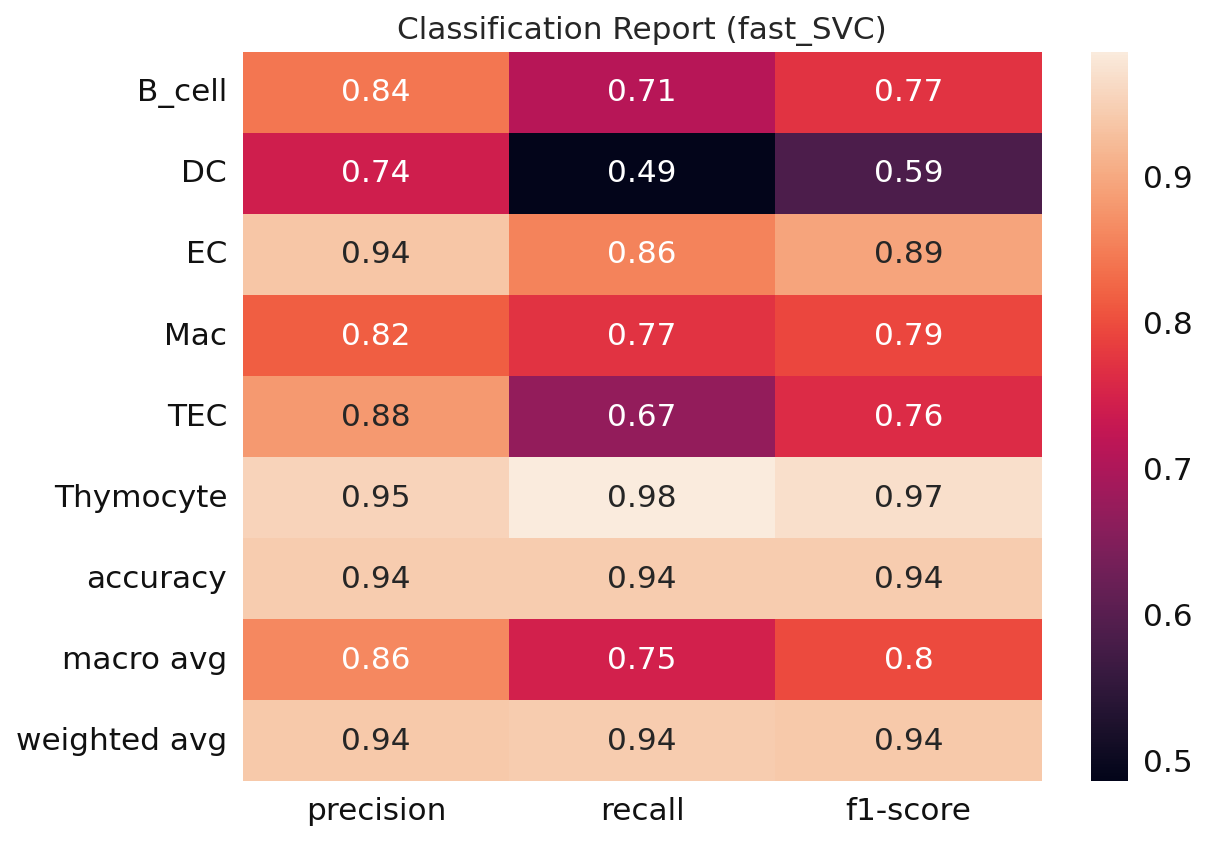

In [4]:
# Broad cell type classifier
ct_svc = sp.tl.ml_train(
    adata_train=train_ad,
    mode= "fast_SVC",
    label='v1_ct',
    nan_policy_y='omit')

Preparing training data!
Unique labels: ['CD4SP' 'CD8SP' 'DN' 'DP_P' 'DP_Q' 'Treg']
Training now!
Evaluating now!


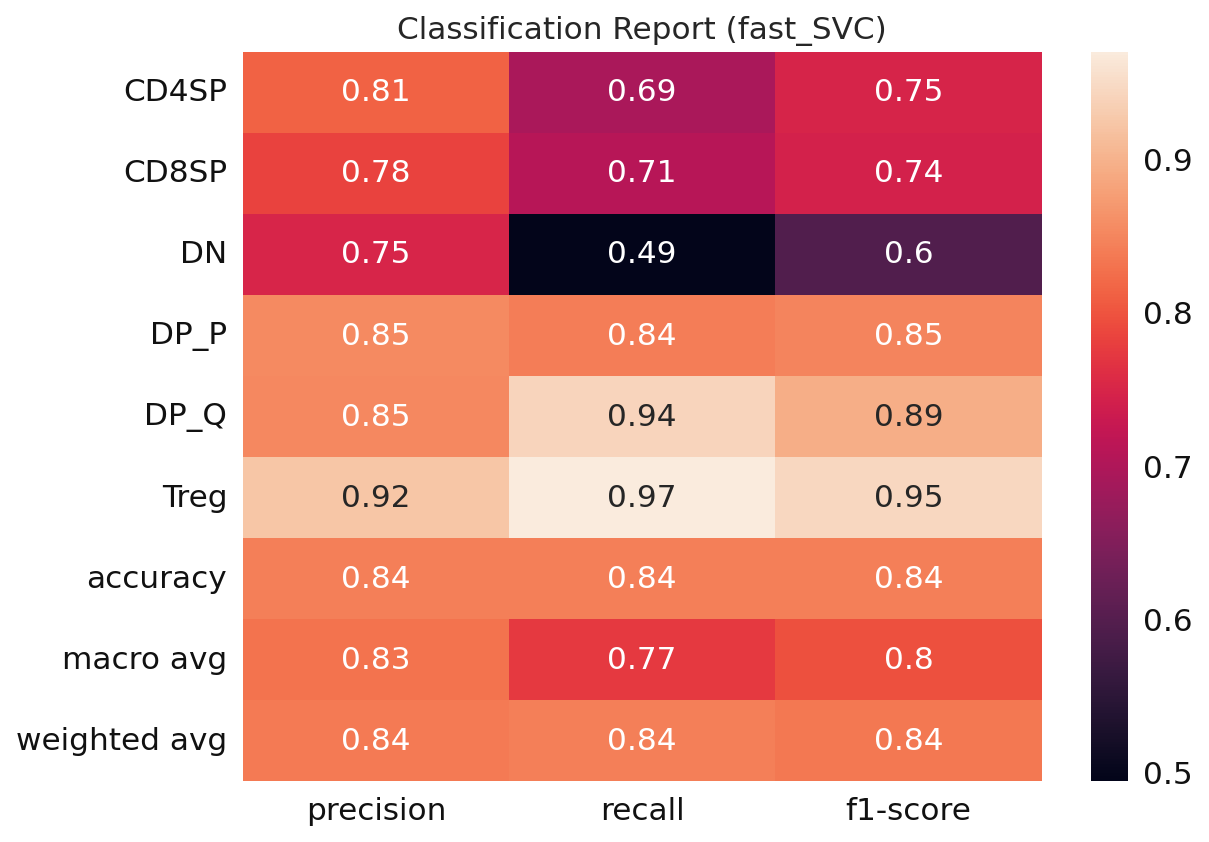

In [5]:
# Thymocyte subset classifier
# thym_markers = ["CD3e", "CD4", "CD8", "Ki67", "FOXP3"]
    # All markers performs much better especially for SPs.
train_thym_ad = train_ad[train_ad.obs["v1_ct"] == "Thymocyte", :].copy()
train_thym_ad.obs["v1_narrow"] = train_thym_ad.obs["v1_narrow"].str.replace(r"DN_(P|Q)", "DN", regex= True)

thym_ct_svc_all_markers = sp.tl.ml_train(
    adata_train= train_thym_ad,
    mode= "fast_SVC",
    label='v1_narrow',
    nan_policy_y='omit')

Preparing training data!
Unique labels: ['CD4SP' 'CD8SP' 'DN' 'DP_P' 'DP_Q' 'Treg']
Training now!
Evaluating now!


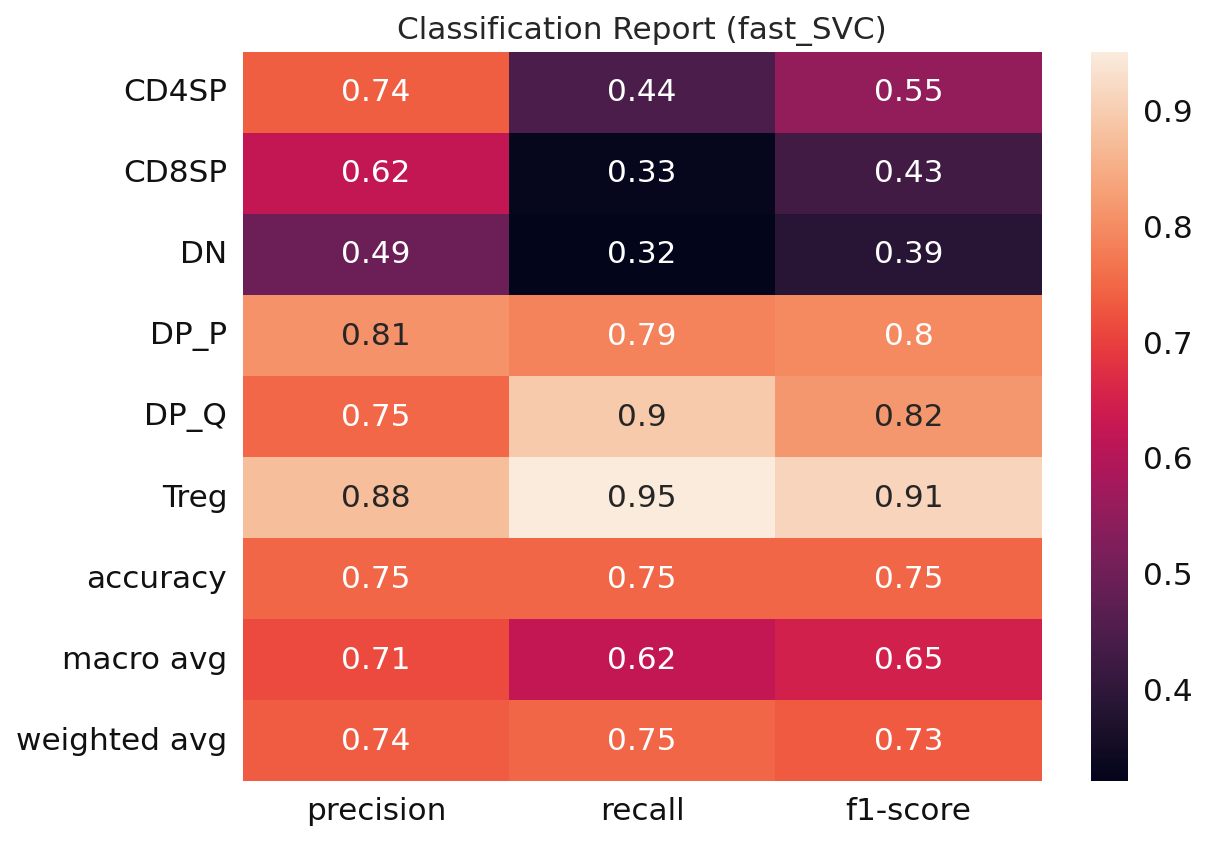

In [6]:
# Thymocyte subset classifier
    # This doesn't perform as well, but generates cleaner groups based on markers
thym_markers = ["CD3e", "CD4", "CD8", "Ki67", "FOXP3"]
    # Using all markers outperformed using only the thymocyte markers 
train_thym_ad = train_ad[train_ad.obs["v1_ct"] == "Thymocyte", thym_markers].copy()
train_thym_ad.obs["v1_narrow"] = train_thym_ad.obs["v1_narrow"].str.replace(r"DN_(P|Q)", "DN", regex= True)

thym_ct_svc_thym_markers_no_split = sp.tl.ml_train(
    adata_train= train_thym_ad,
    mode= "fast_SVC",
    label='v1_narrow',
    nan_policy_y='omit')

## Separate thymocytes from rest

In [16]:
ad_dir = "/John/human_mxif/data/"
other_ads = [os.path.join(ad_dir, ad_file) for ad_file in os.listdir(ad_dir) if re.search("uto_thresh_binary_filt_masks_no_touch_nonfat_cell_mask.h5ad", ad_file)] 
for i in other_ads:
    print(re.sub("_thresh_full_auto_thresh_binary_filt_masks_no_touch_nonfat_cell_mask.h5ad", "", re.sub("/John/human_mxif/data/", "", i)))
print(len(other_ads))

A1_20wkM_block5
A3_18wkF_block6
P31_27F_block1
P32_46F_block1
P33_10M_block1
P34_29F_block2
P35_38F_block2
P36_67F_block2
P37_62F_block1
P41-E1_58F_block4
P42_54F_block6
P44_64F_block6
P49_2M_block6
P52_21M_block4
P57_17F_block6
T2008_7M_block1
T2018-3_0.3F_block4
T2019-2_0.013F_block3
T2033_9F_block1
T2036-3_7F_block4
T2037-3_1.583M_block5
T2040-2_8F_block3
T2044-2_1.166F_block3
T2047-1_0.333F_block5
T2049-1_0.013M_block4
T2052-1_0.021M_block5
T2056-2_0.008M_block2
T2066_8M_block1
T2077-1_0.013F_block4
T2083-1_0.917F_block4
T2087-2_0.003M_block3
T2092-4_0.833M_block2
T2095-2_22M_block2
T2101-1_1M_block2
T2110-1_0.025M_block6
35


Classifying!
Saving cell type labels to adata!


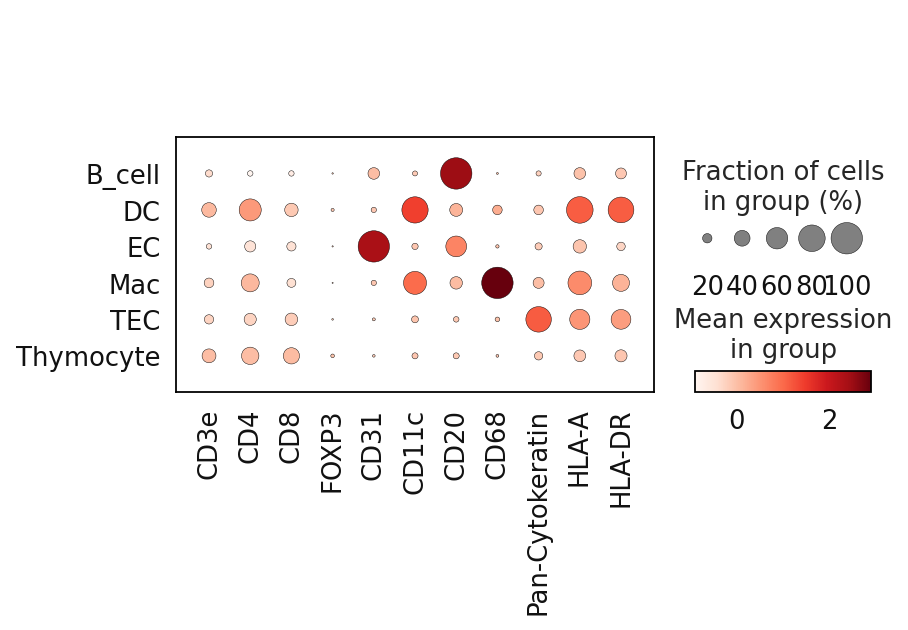

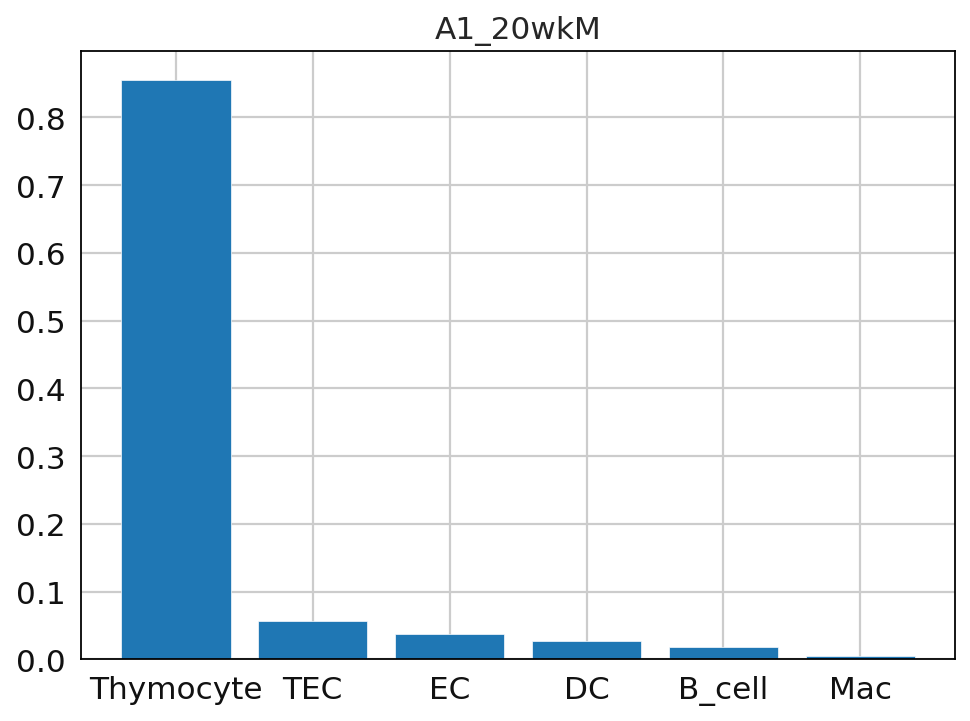

Classifying!
Saving cell type labels to adata!


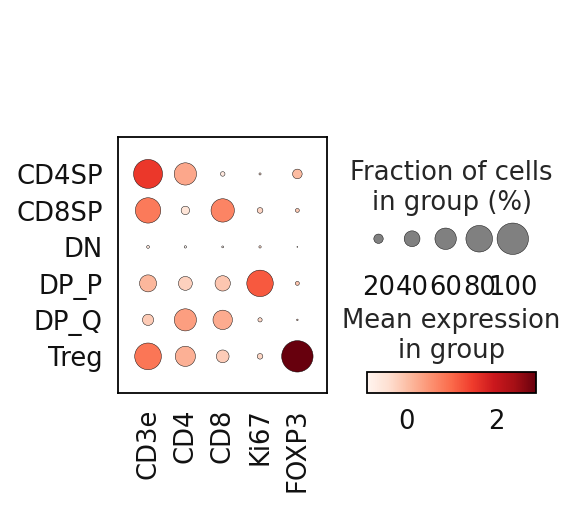

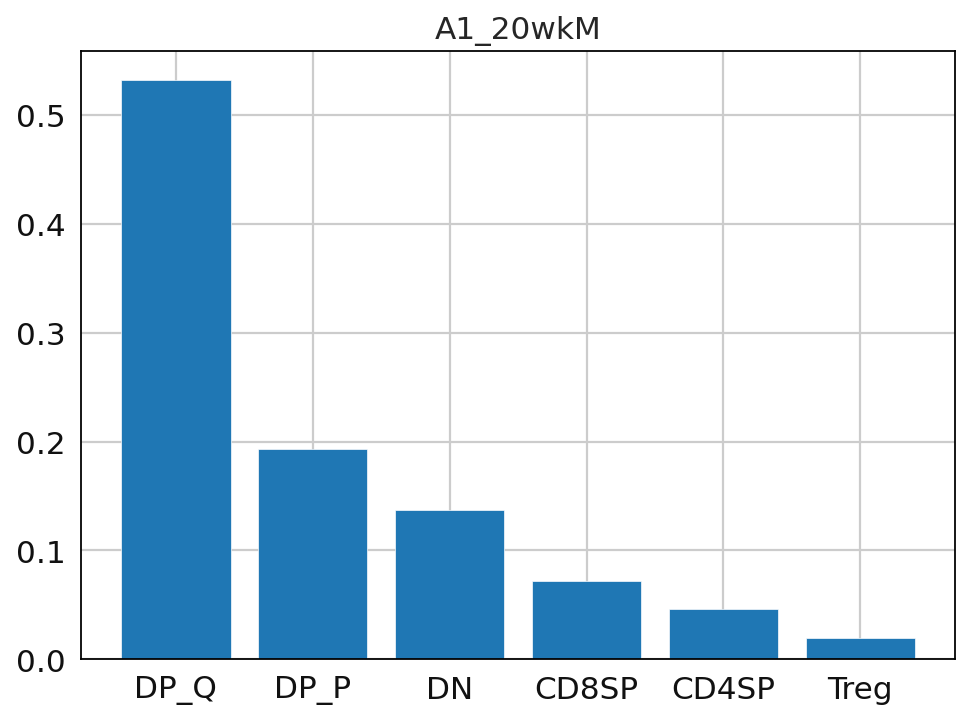

Classifying!
Saving cell type labels to adata!


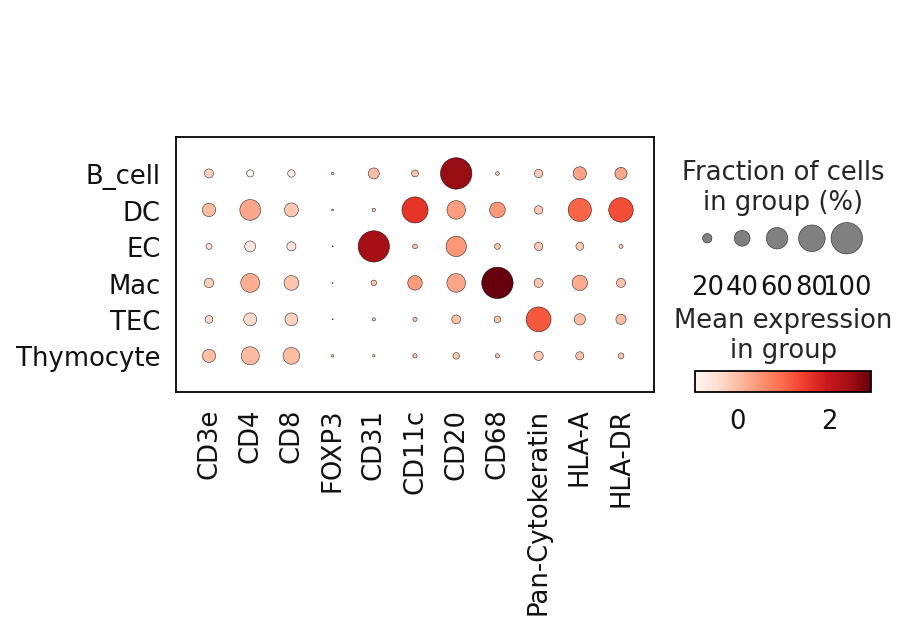

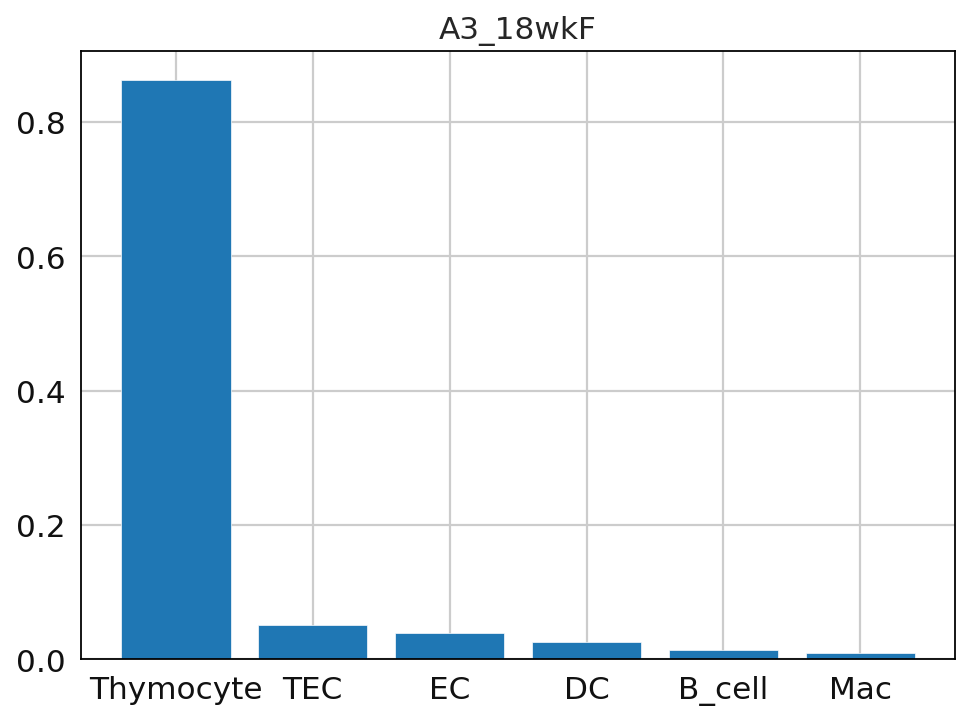

Classifying!
Saving cell type labels to adata!


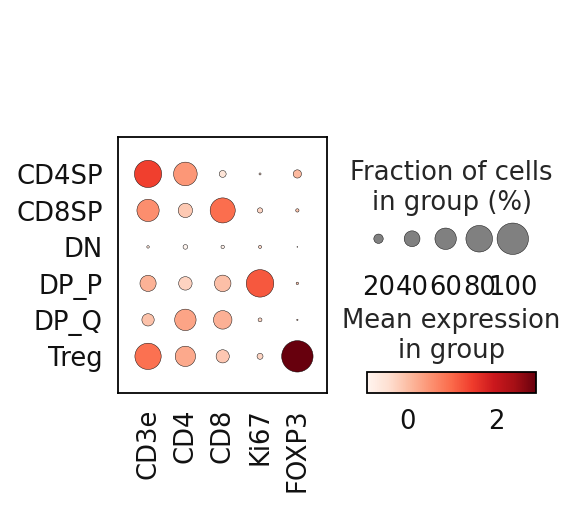

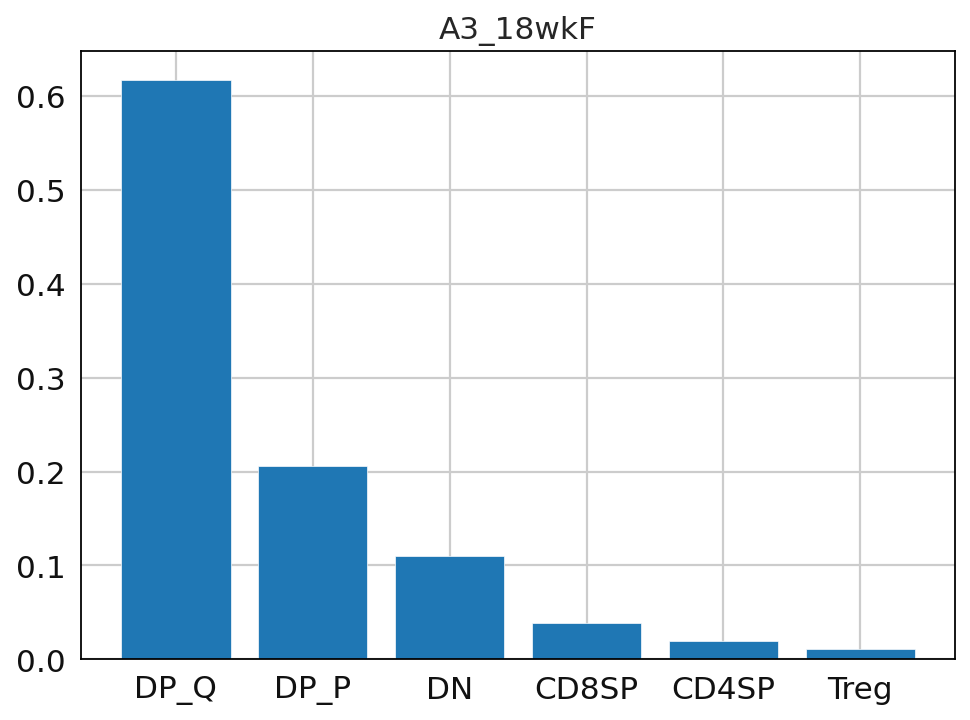

Classifying!
Saving cell type labels to adata!


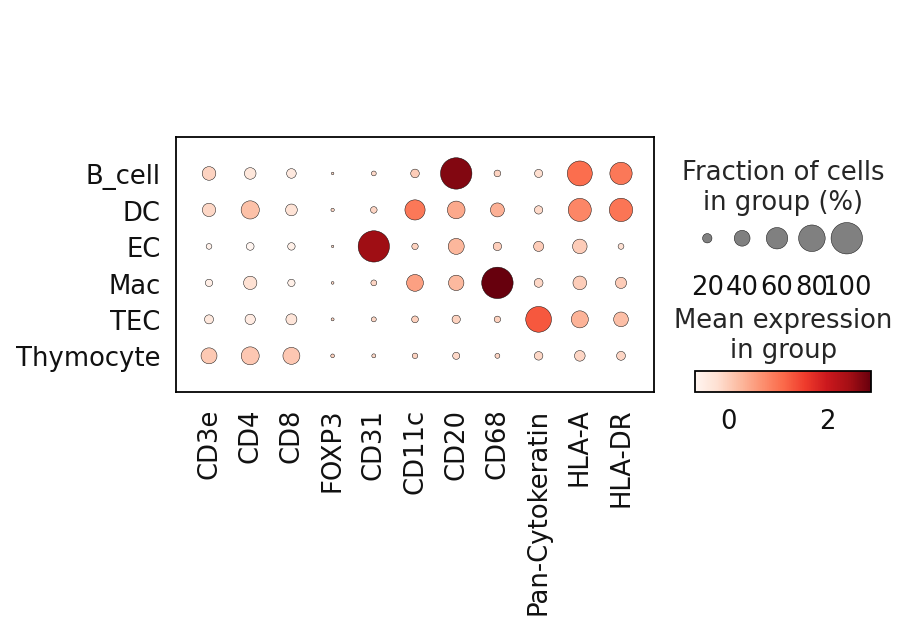

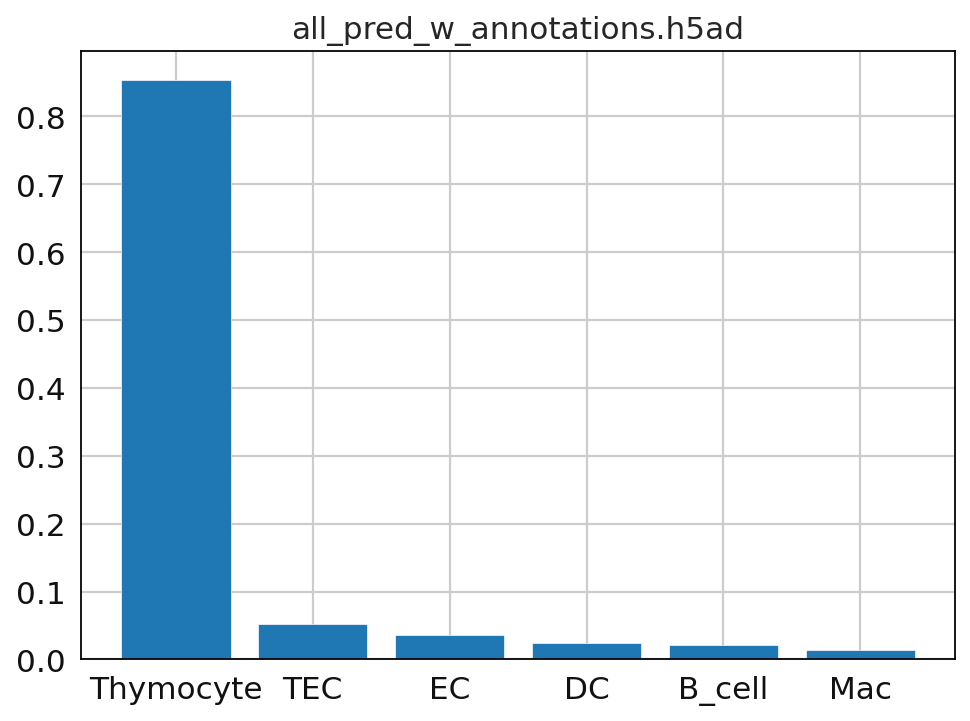

Classifying!
Saving cell type labels to adata!


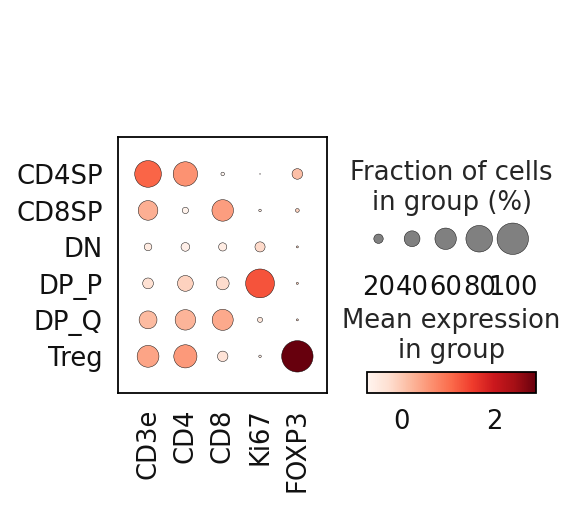

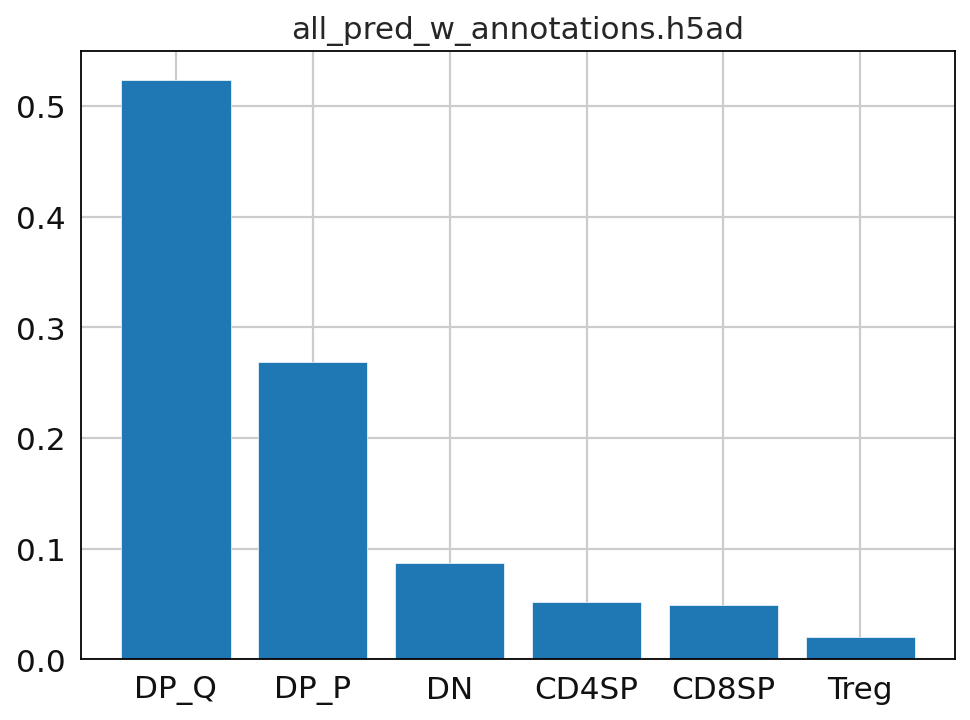

Classifying!
Saving cell type labels to adata!


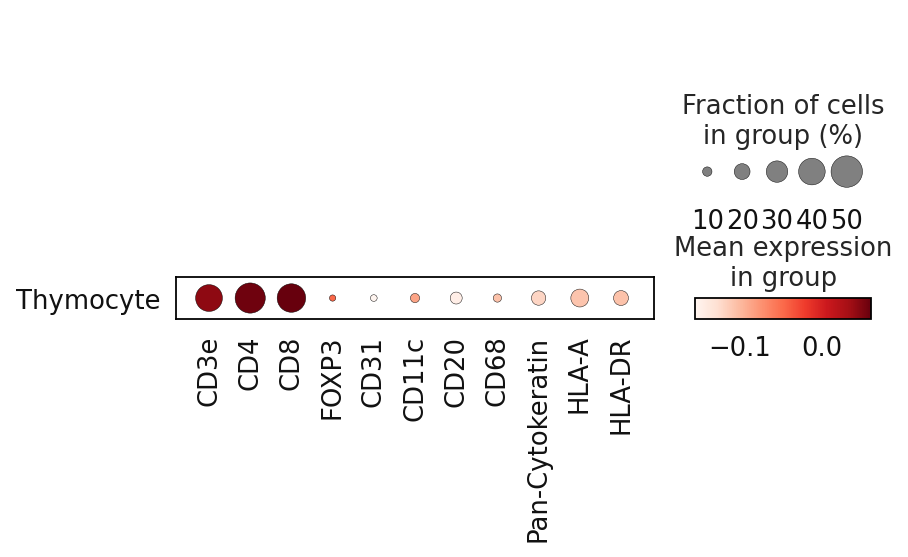

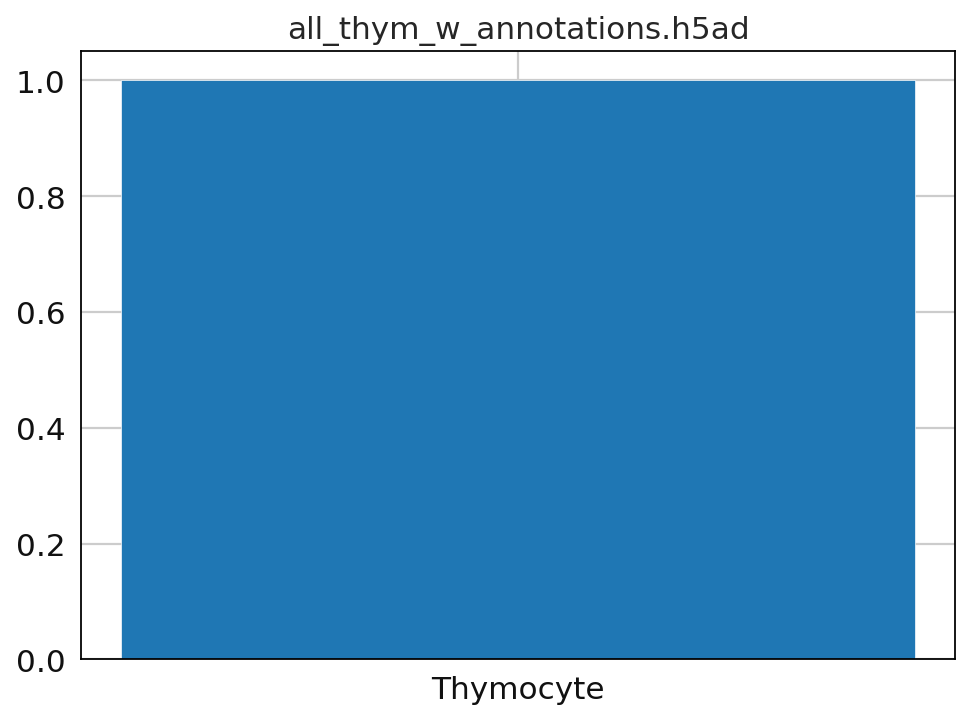

Classifying!
Saving cell type labels to adata!


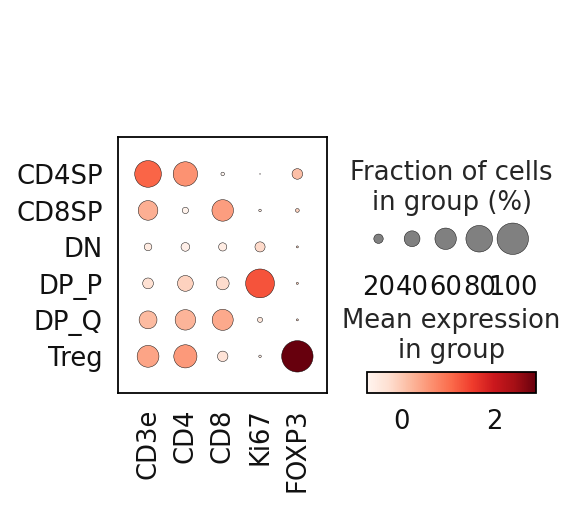

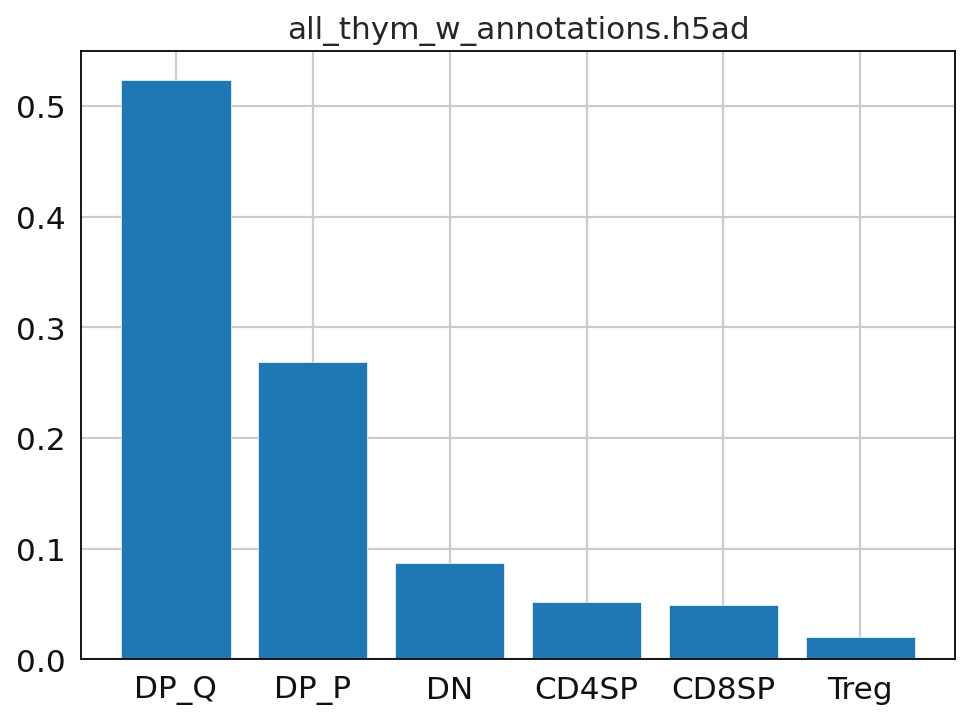

Classifying!
Saving cell type labels to adata!


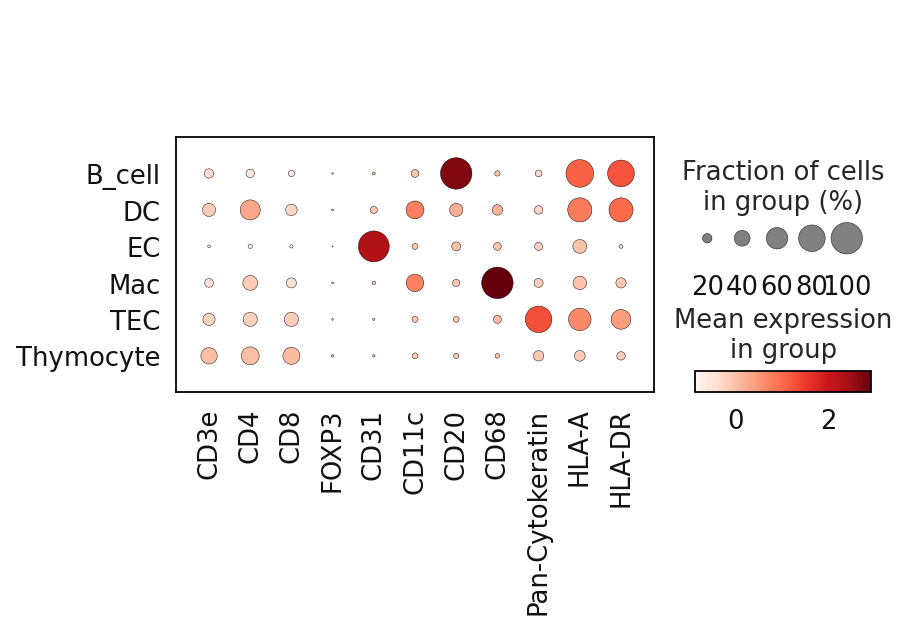

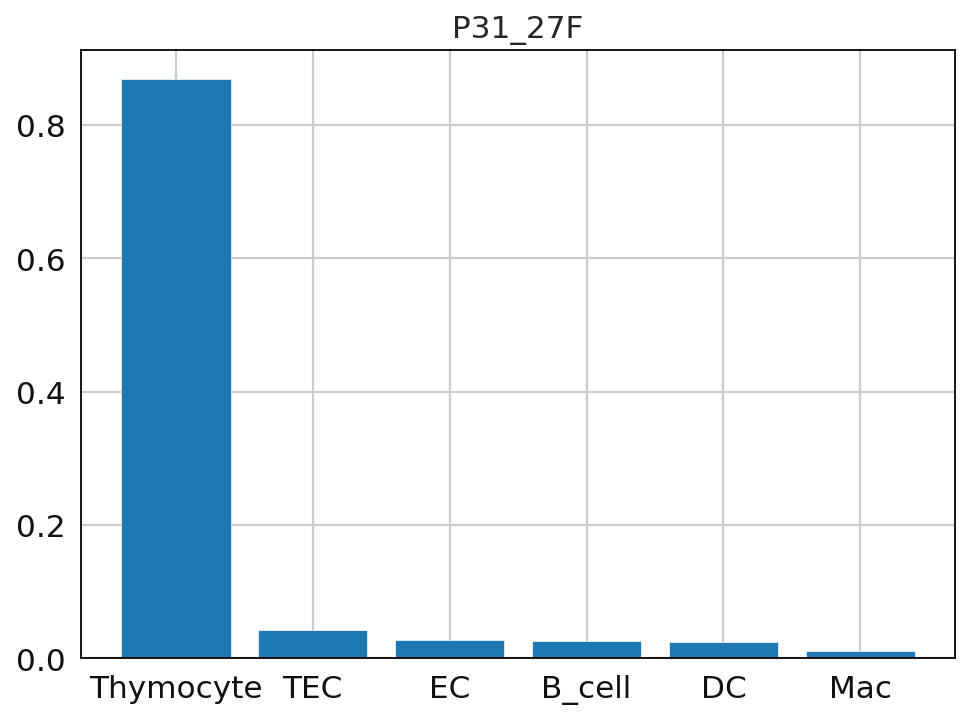

Classifying!
Saving cell type labels to adata!


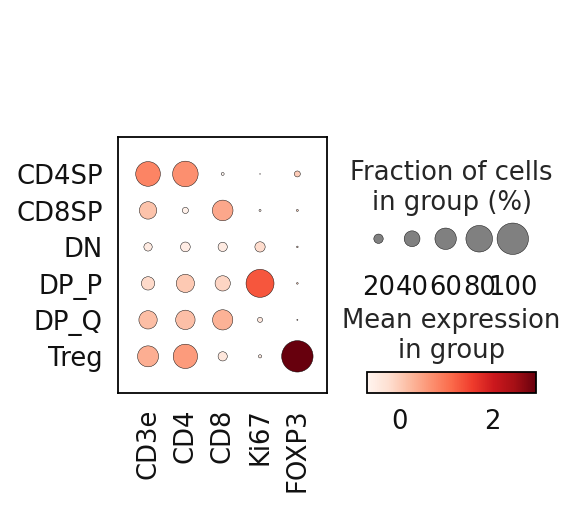

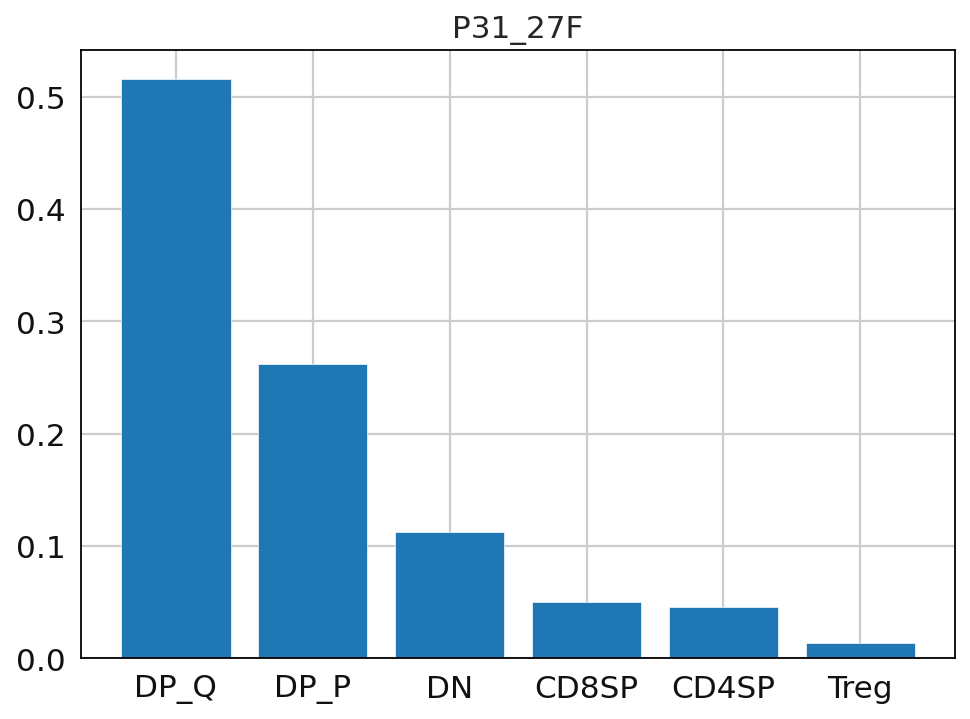

Classifying!
Saving cell type labels to adata!


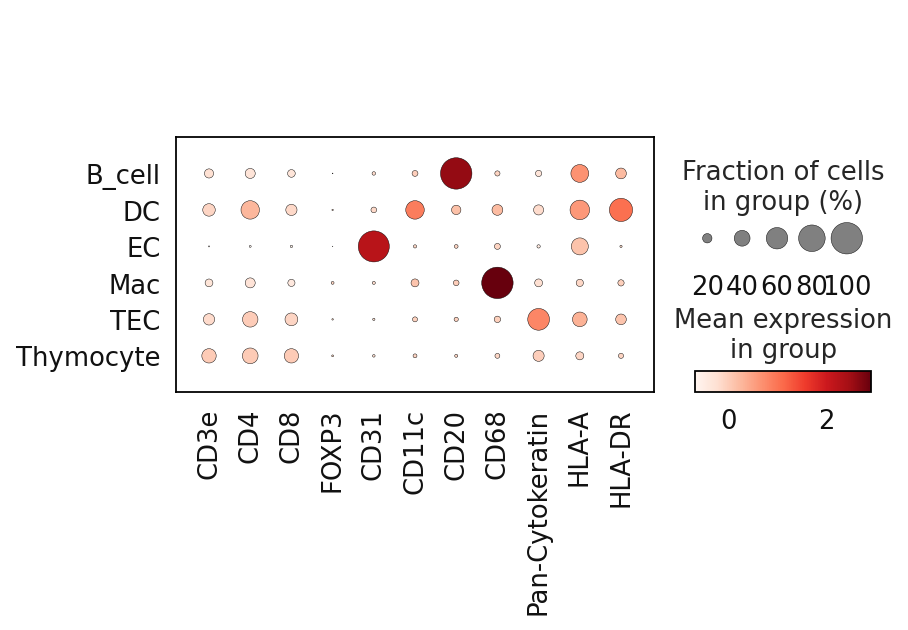

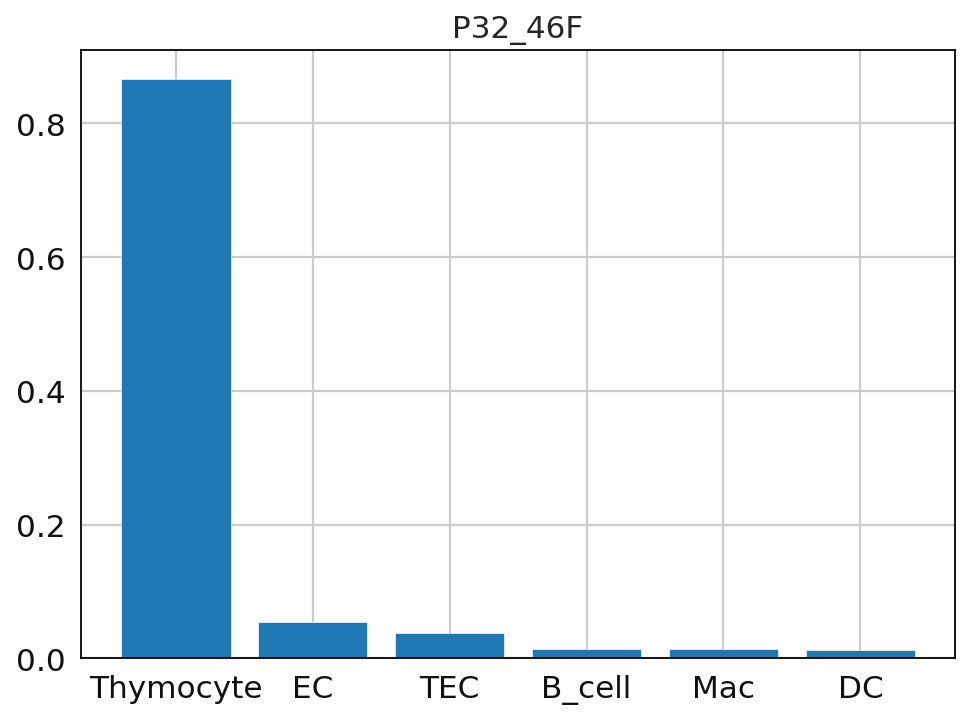

Classifying!
Saving cell type labels to adata!


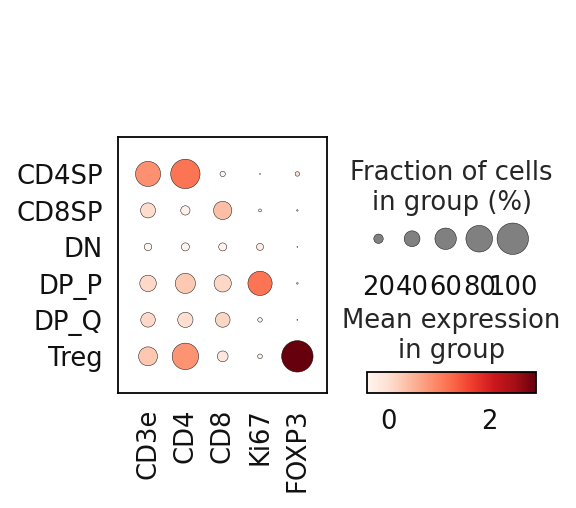

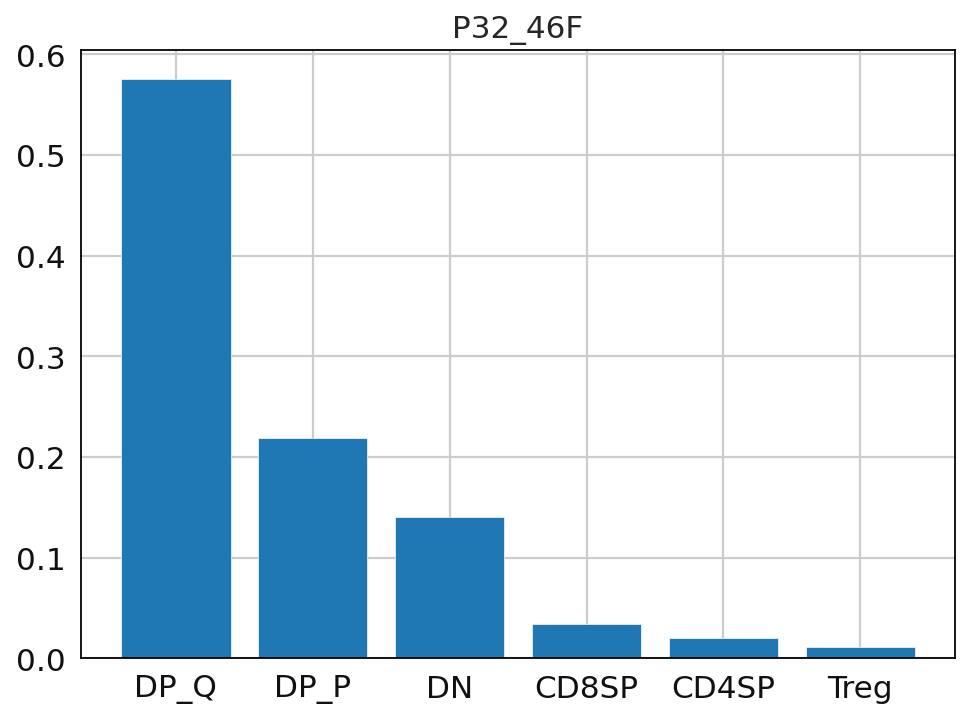

Classifying!
Saving cell type labels to adata!


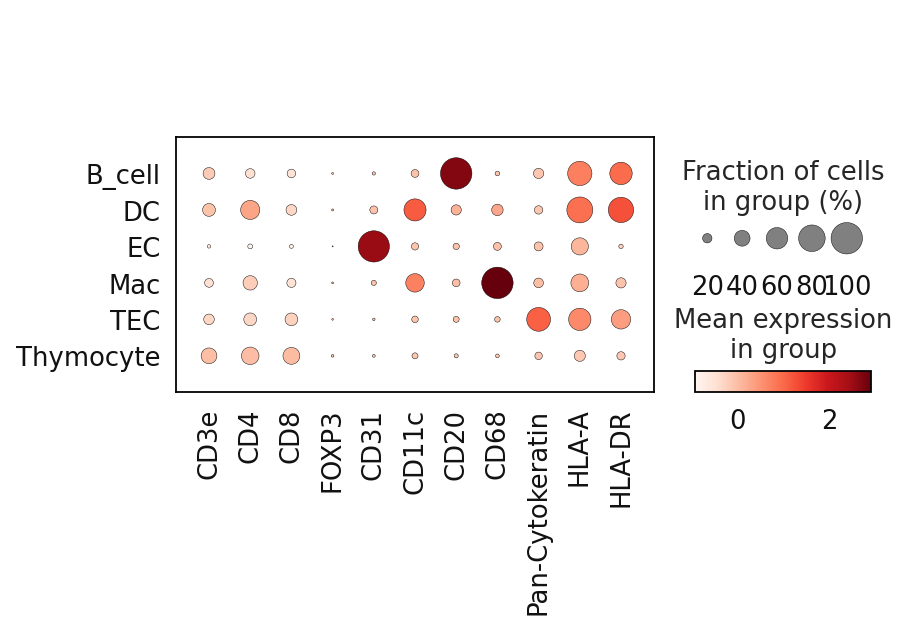

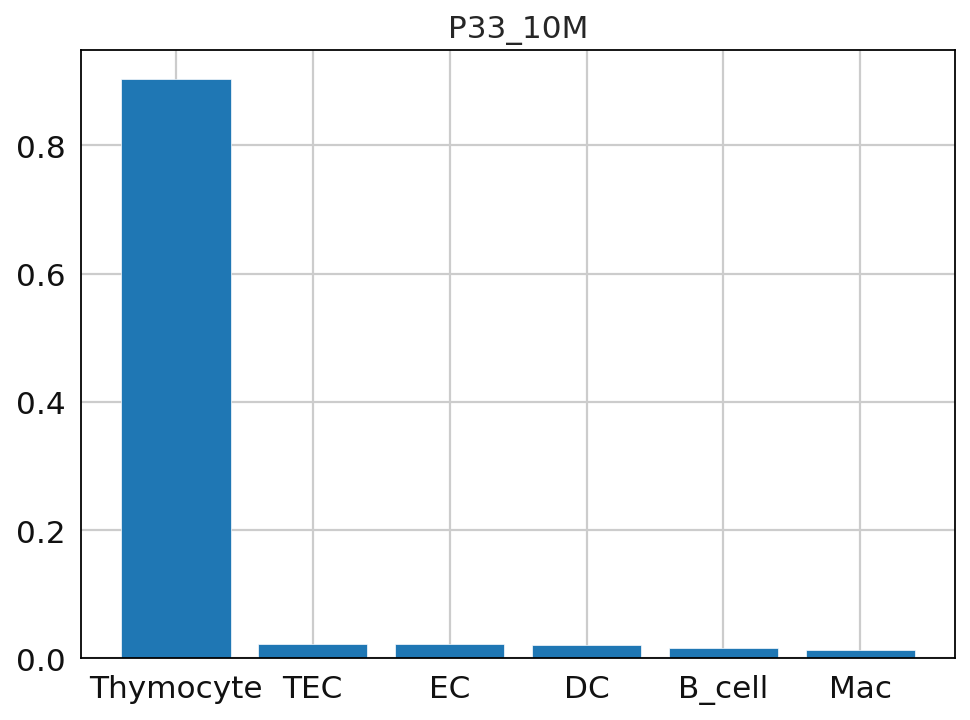

Classifying!
Saving cell type labels to adata!


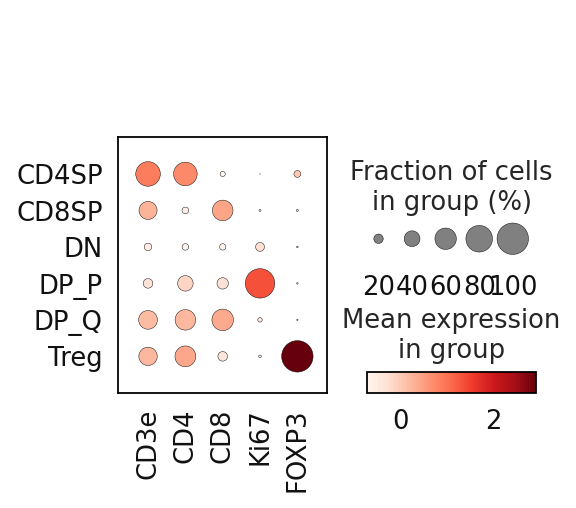

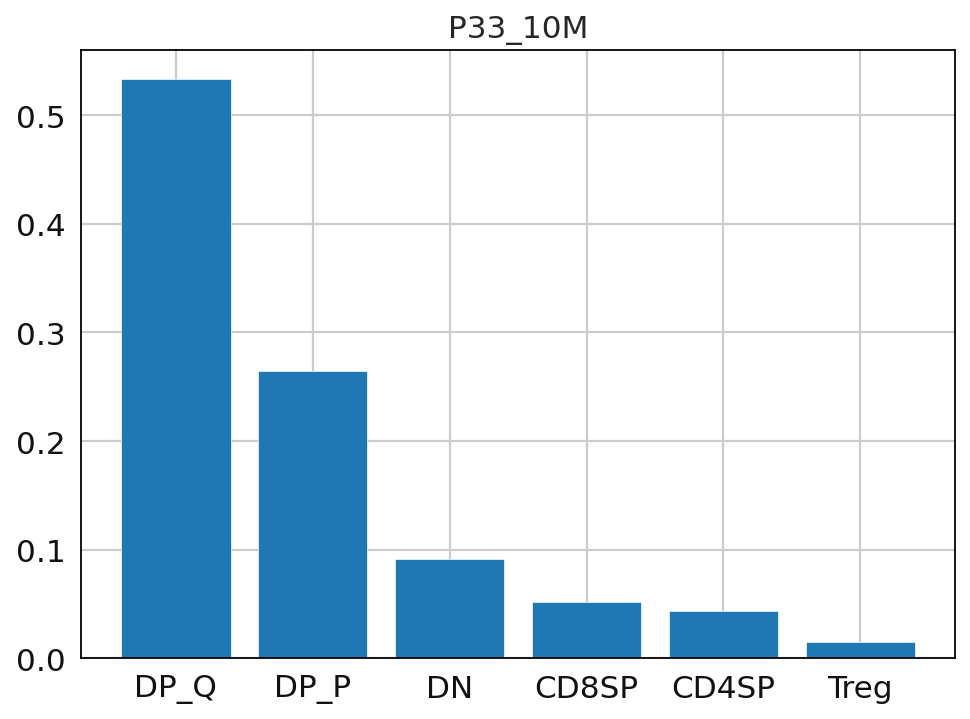

Classifying!
Saving cell type labels to adata!


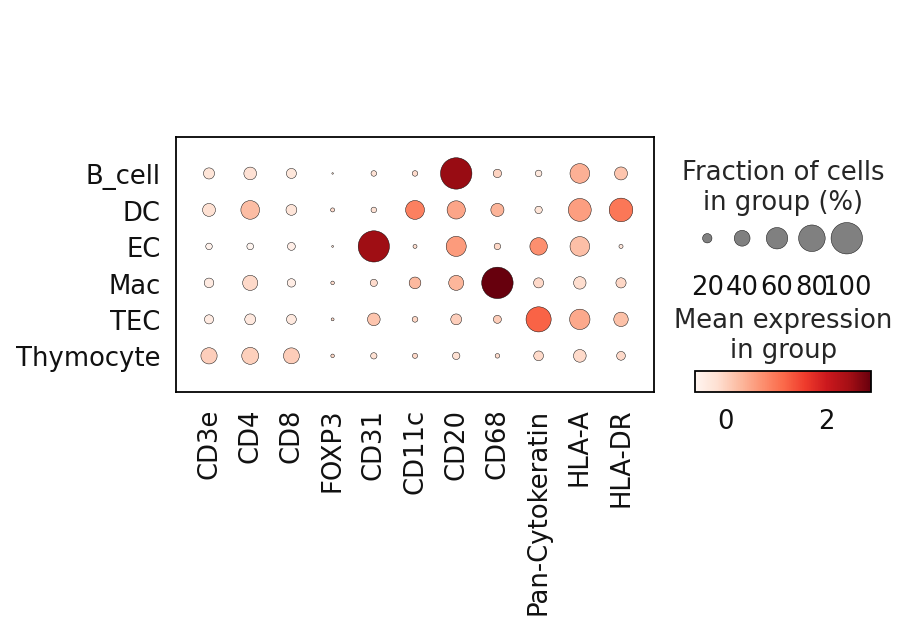

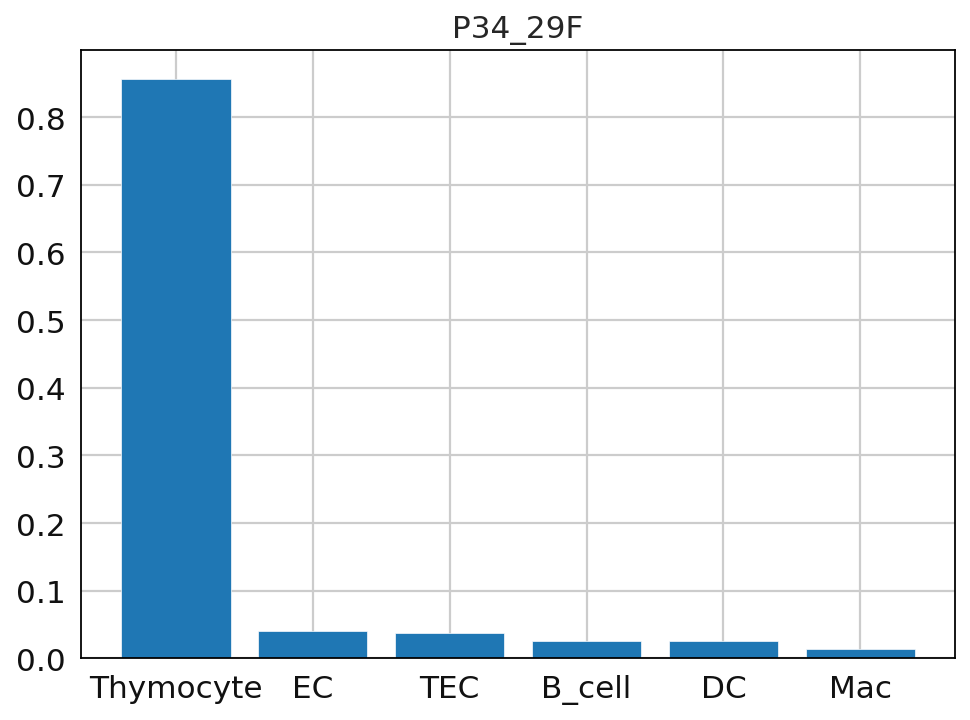

Classifying!
Saving cell type labels to adata!


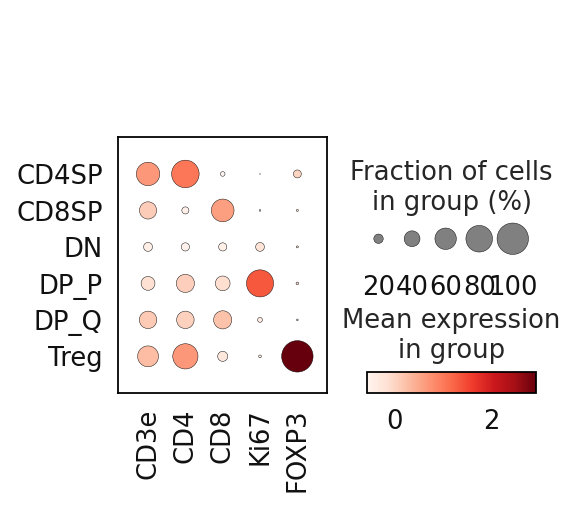

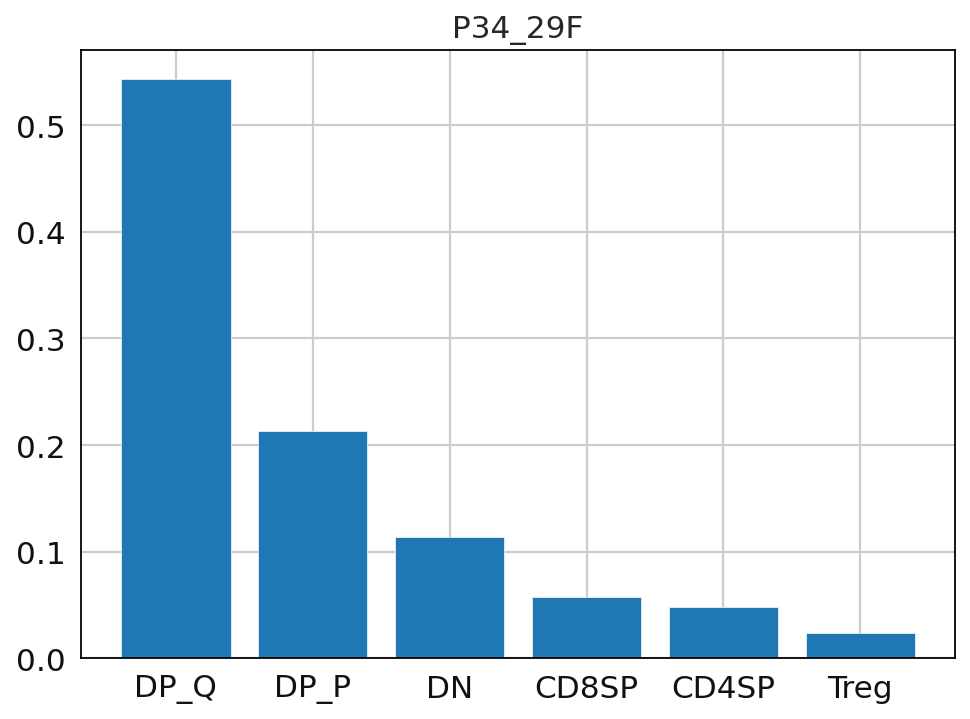

Classifying!
Saving cell type labels to adata!


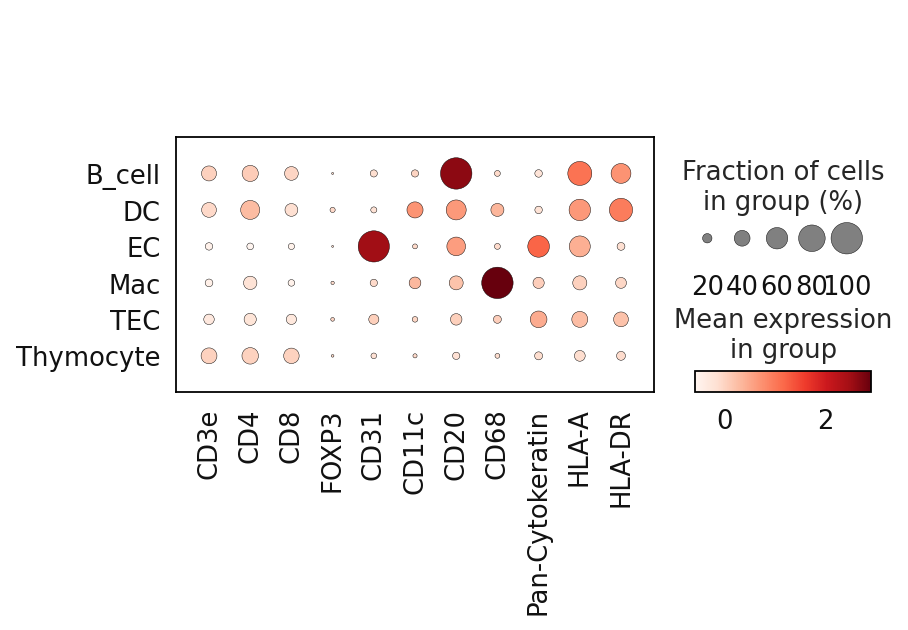

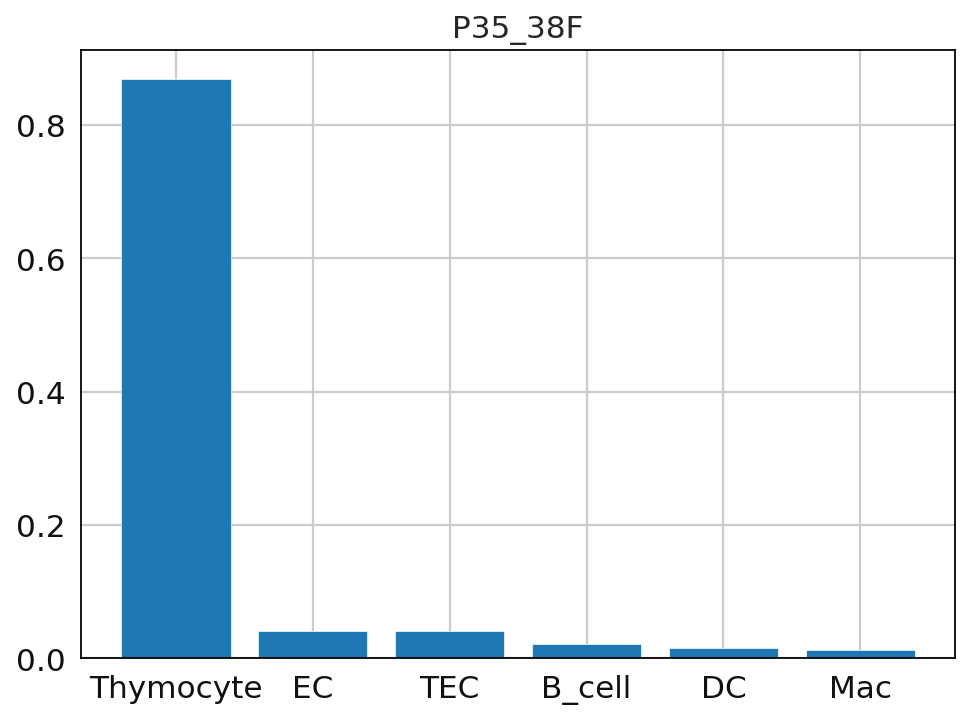

Classifying!
Saving cell type labels to adata!


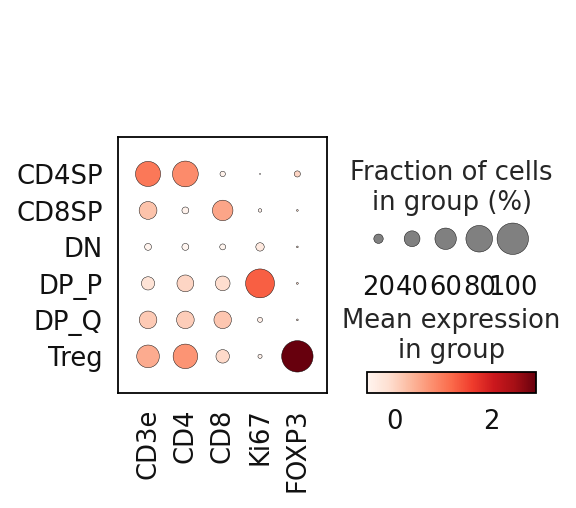

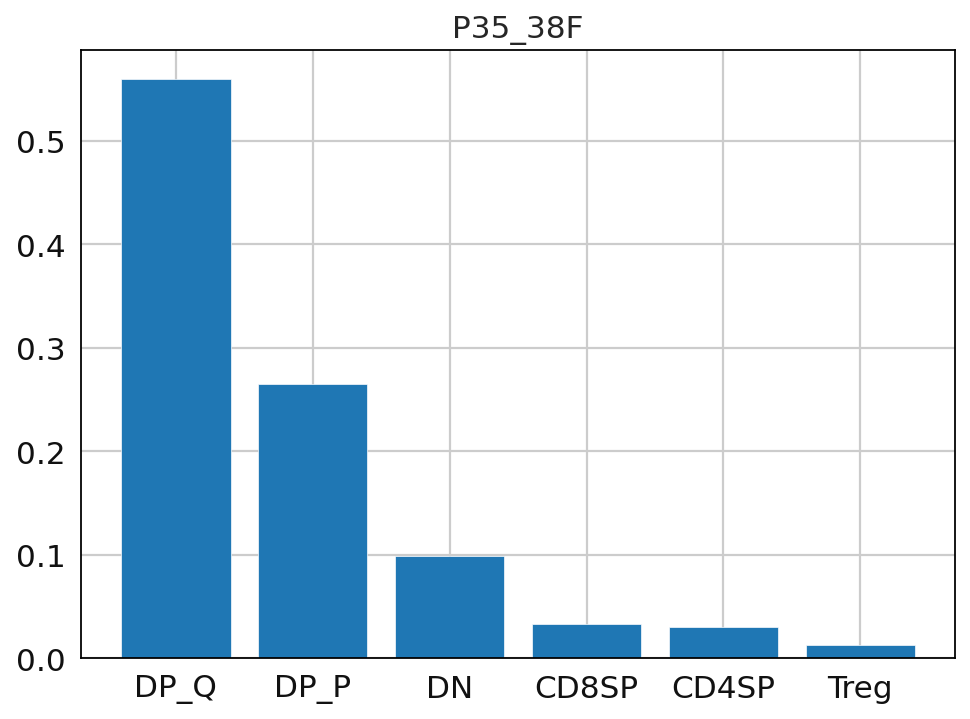

Classifying!
Saving cell type labels to adata!


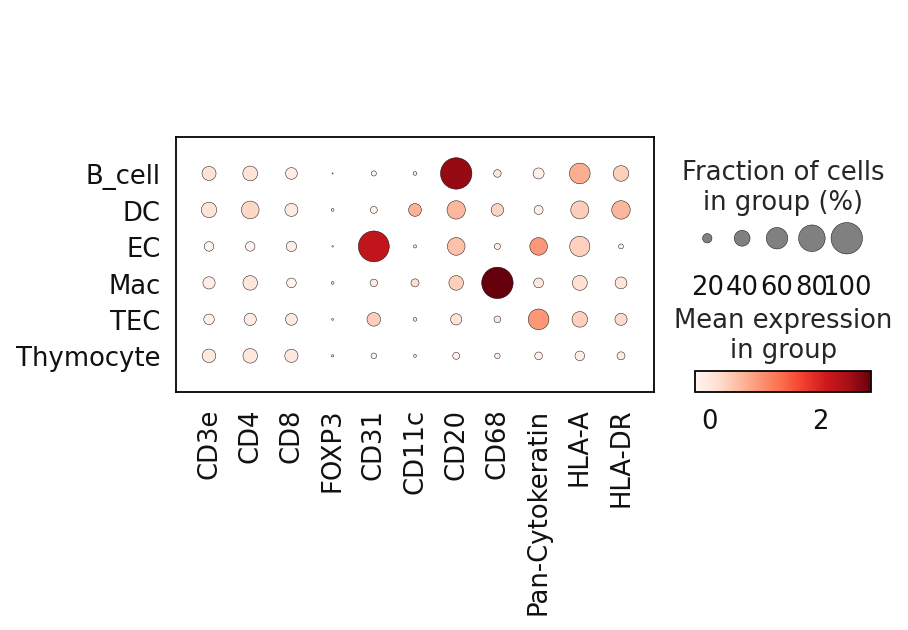

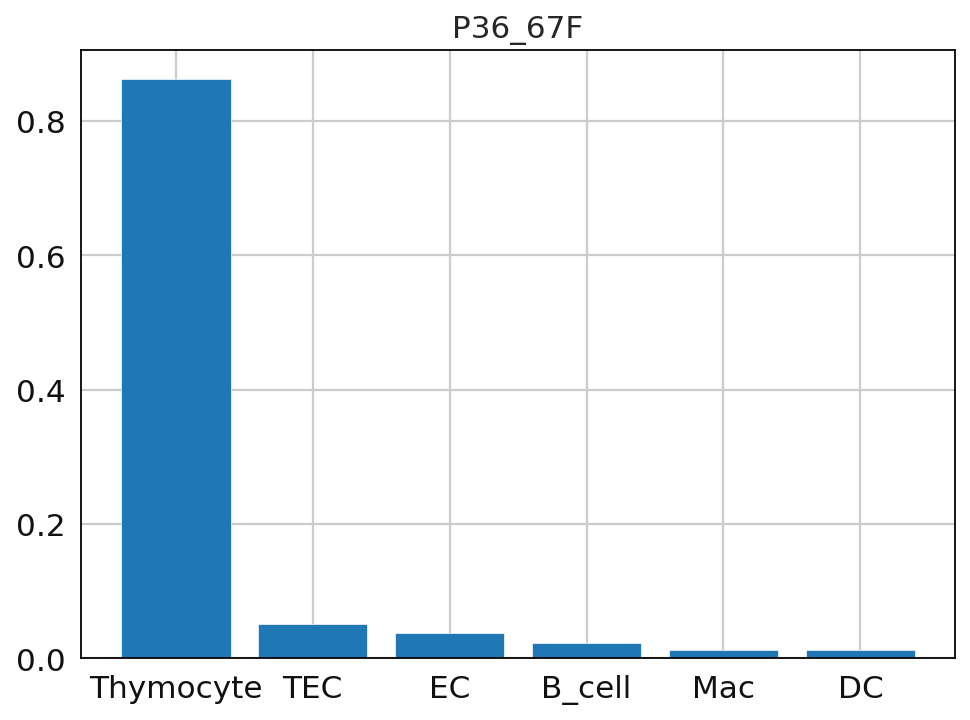

Classifying!
Saving cell type labels to adata!


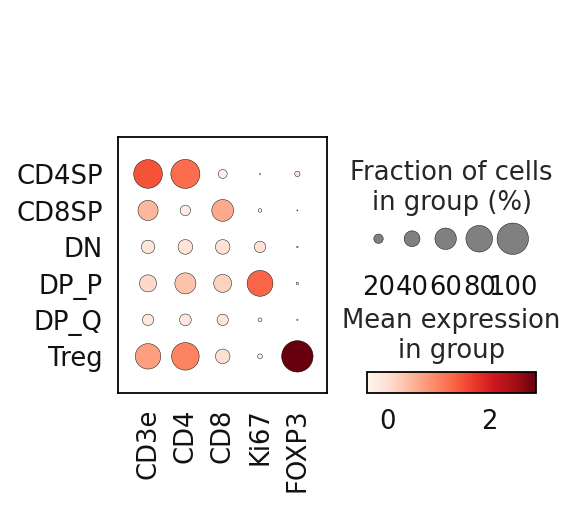

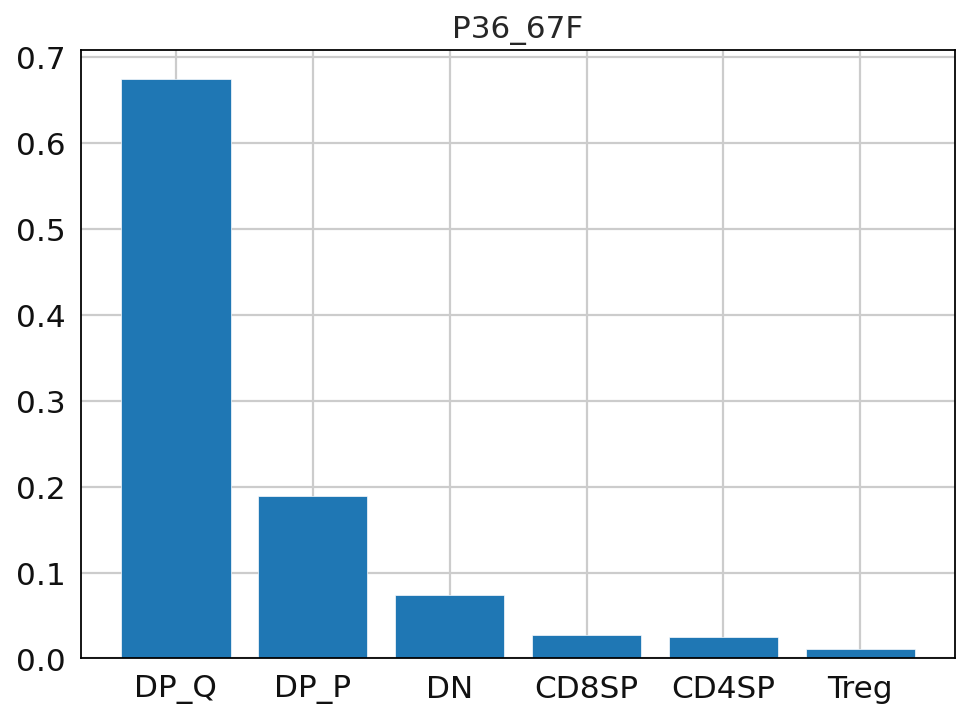

Classifying!
Saving cell type labels to adata!


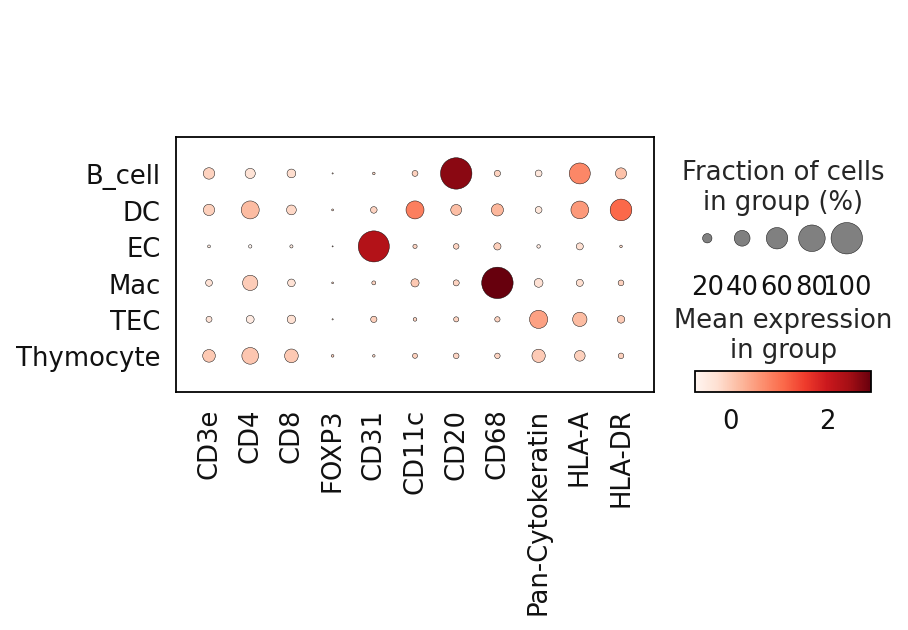

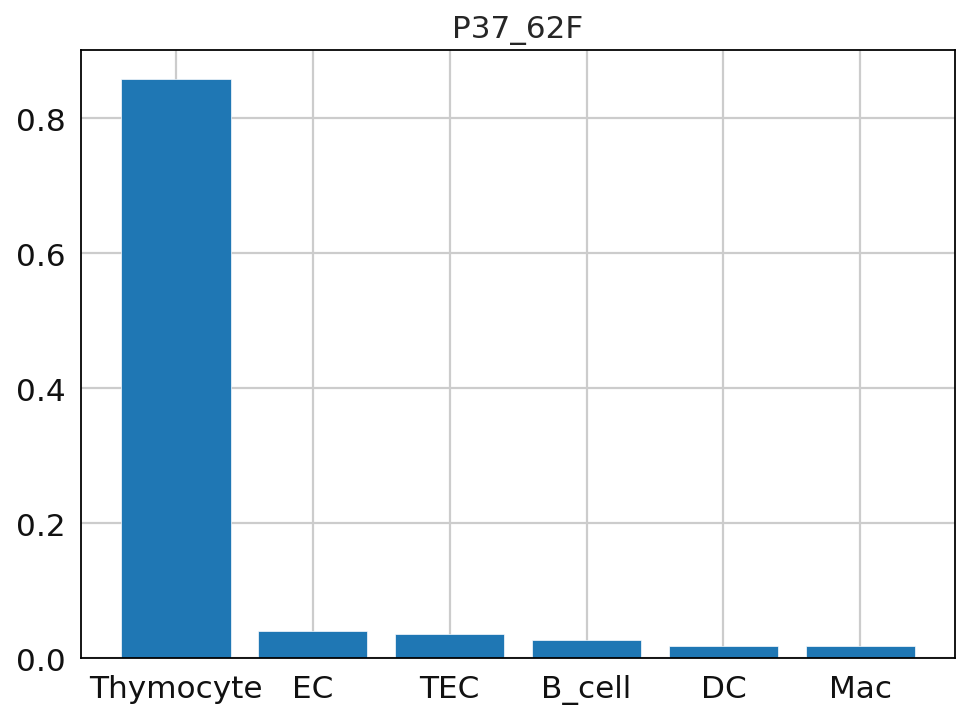

Classifying!
Saving cell type labels to adata!


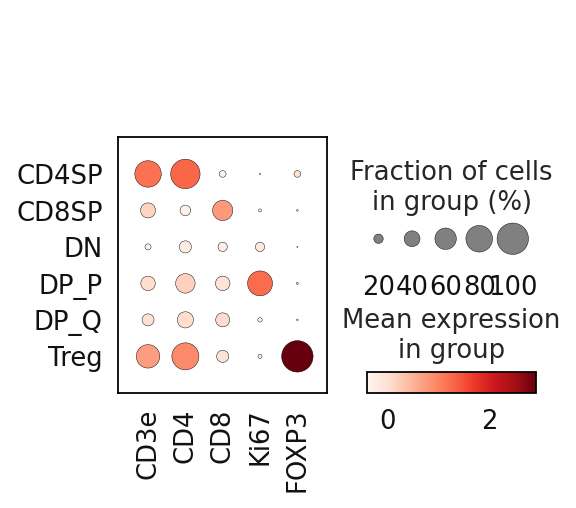

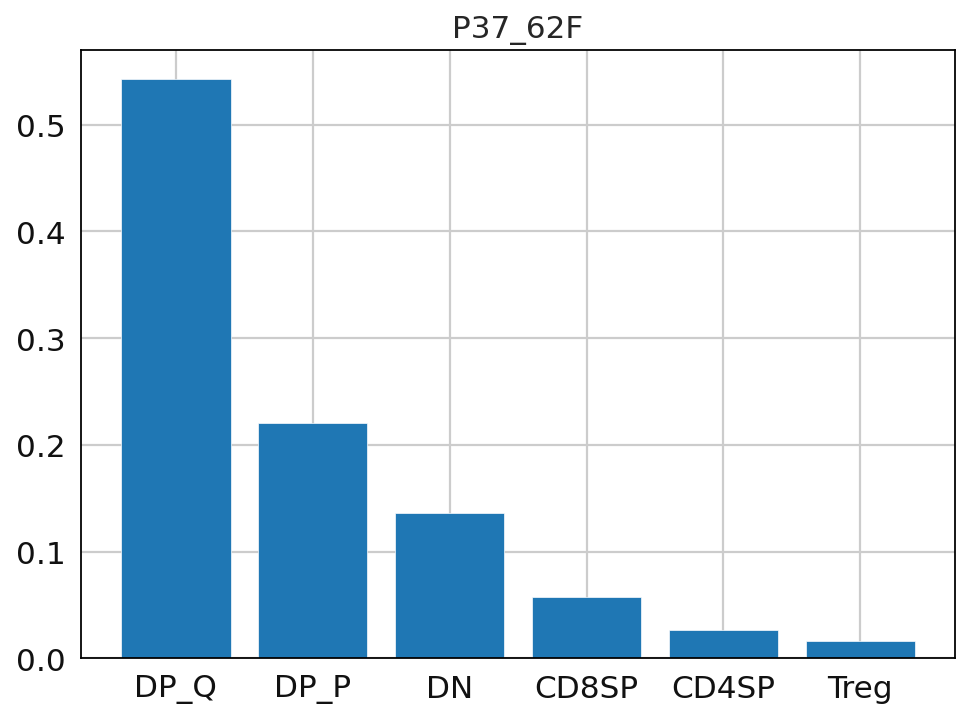

Classifying!
Saving cell type labels to adata!


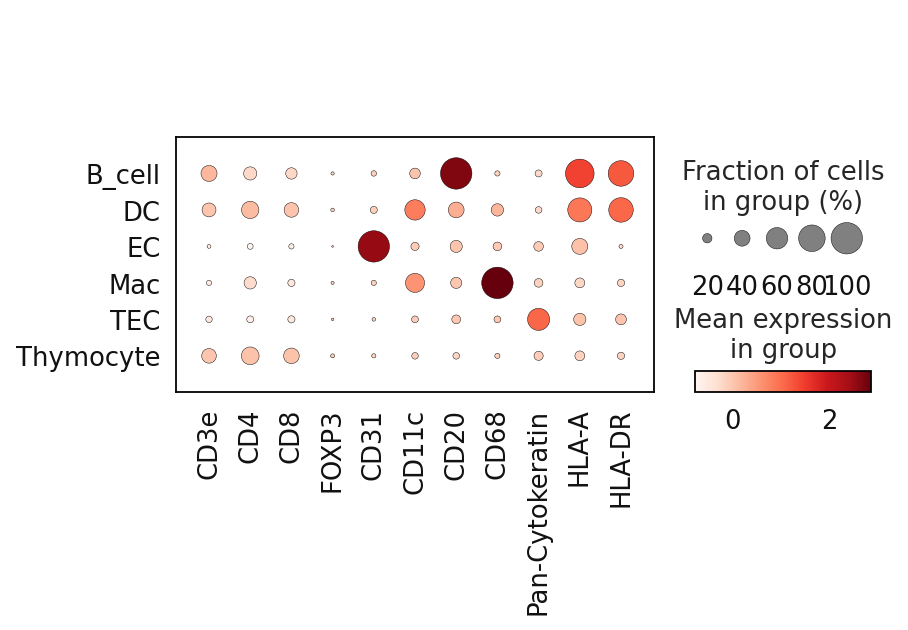

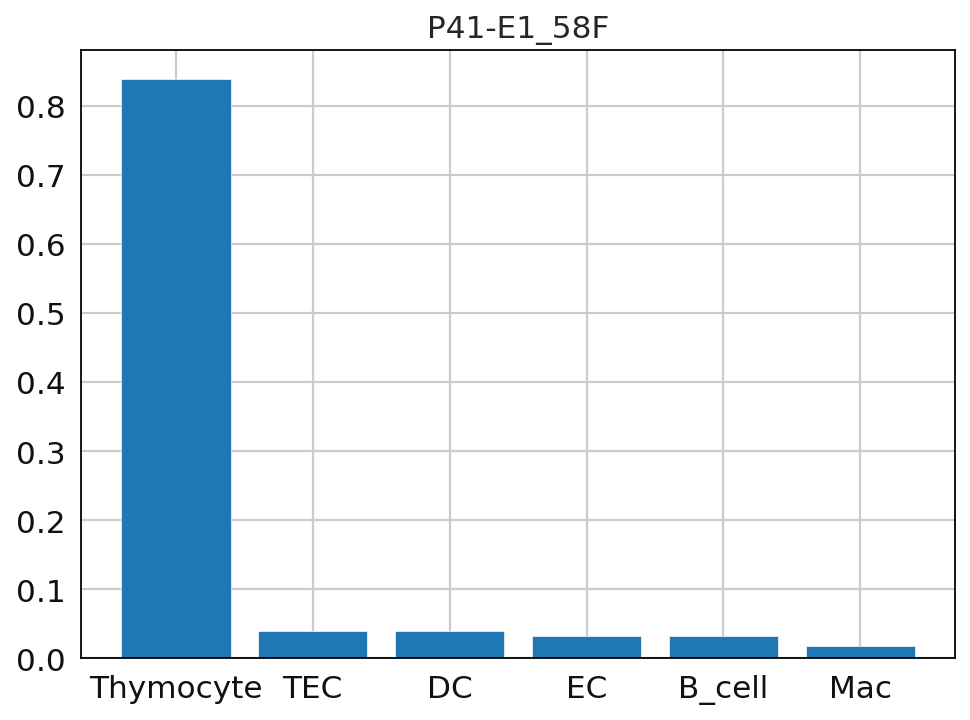

Classifying!
Saving cell type labels to adata!


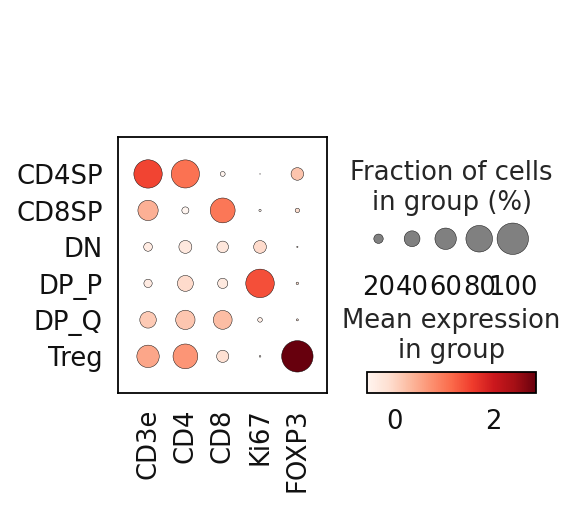

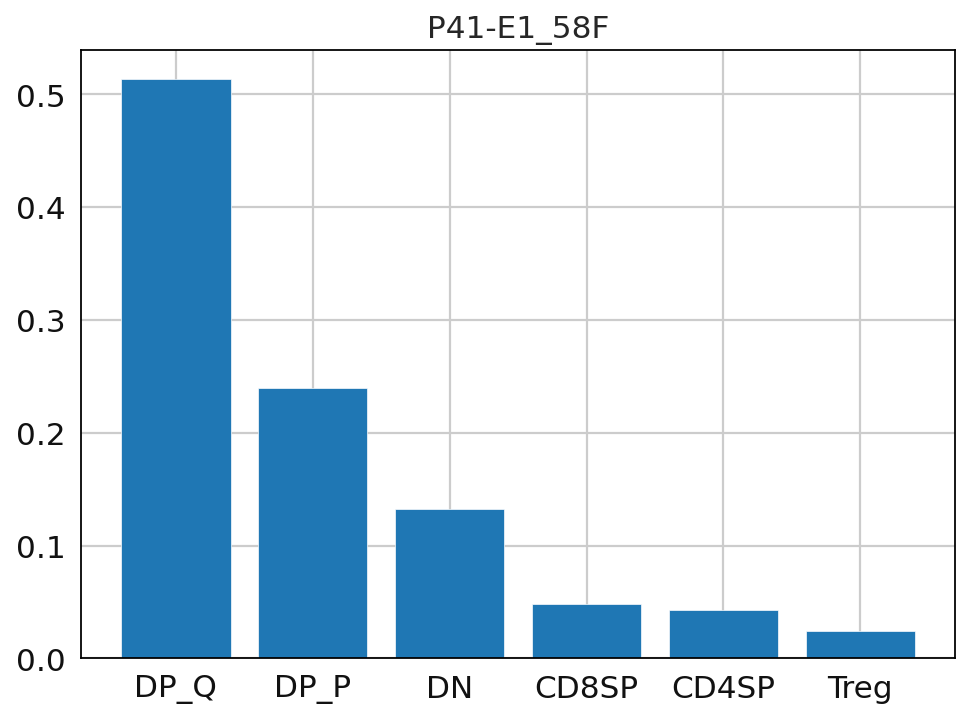

Classifying!
Saving cell type labels to adata!


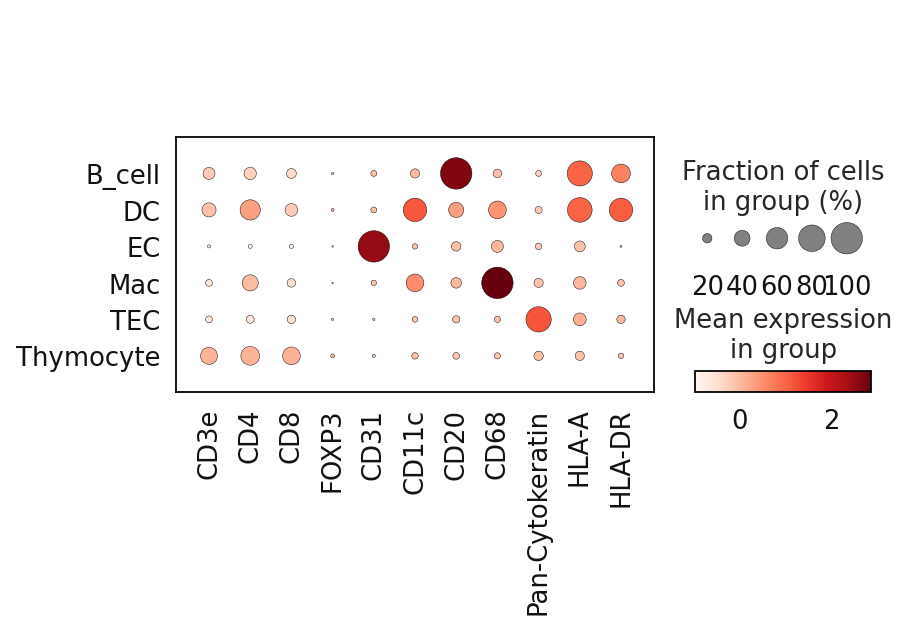

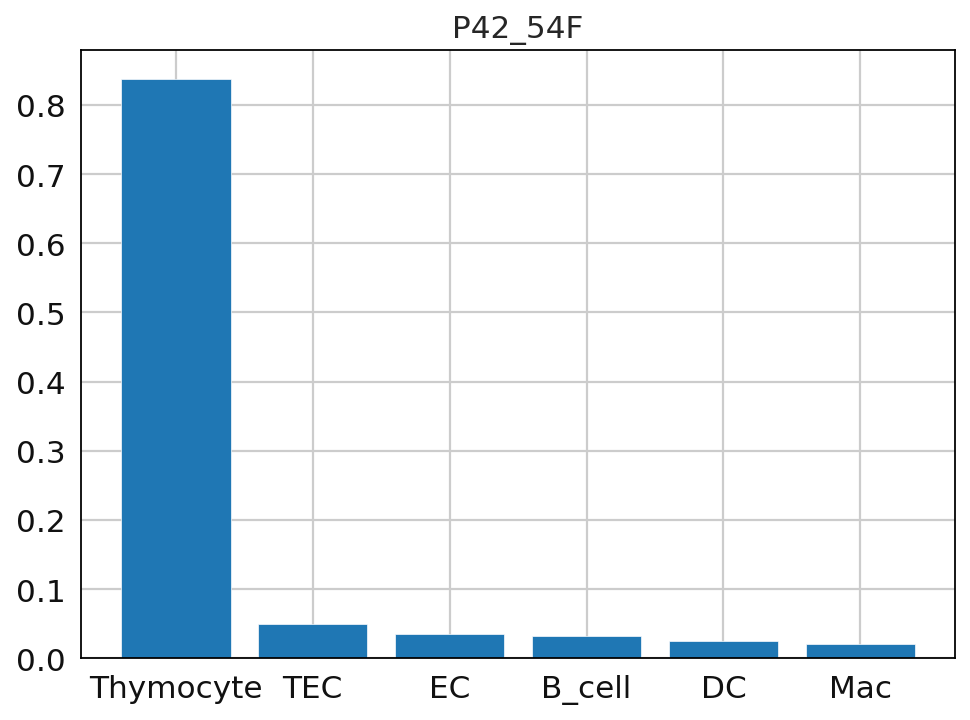

Classifying!
Saving cell type labels to adata!


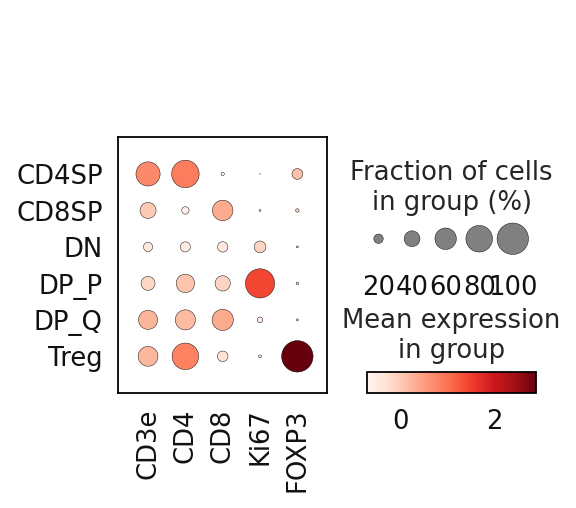

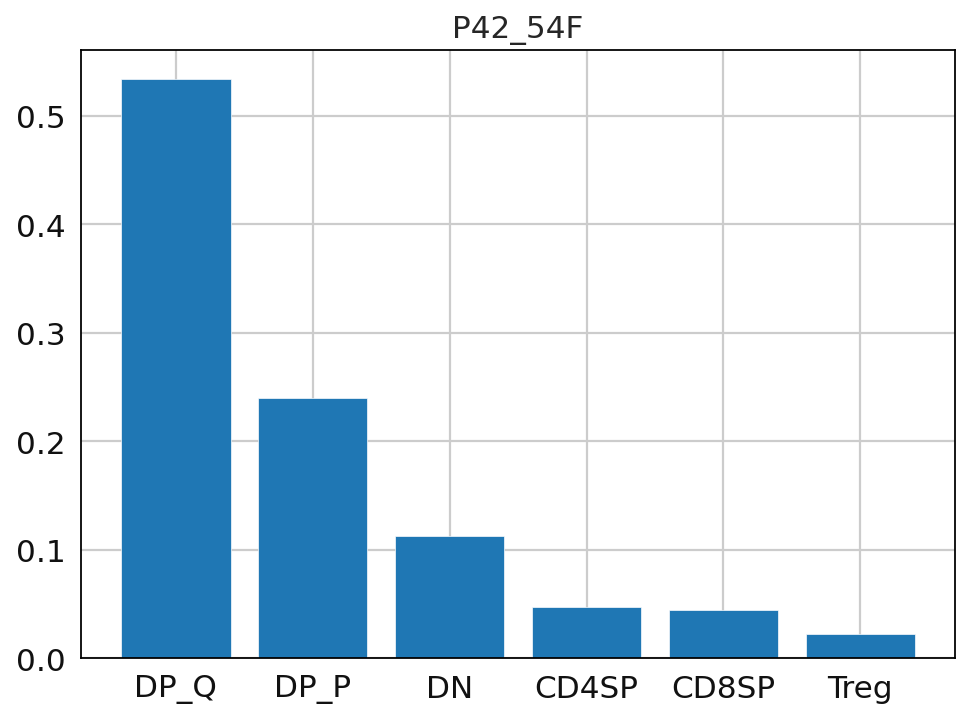

Classifying!
Saving cell type labels to adata!


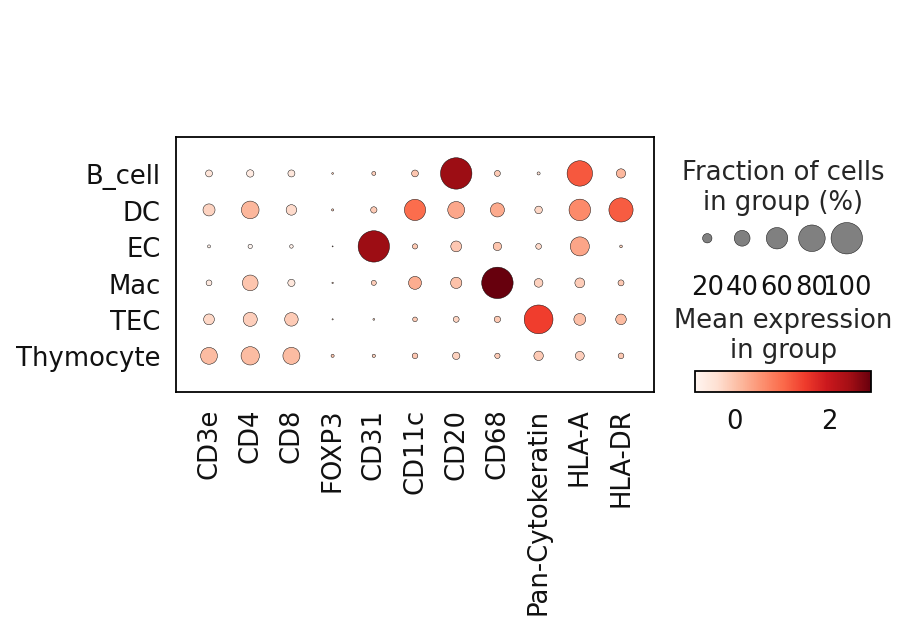

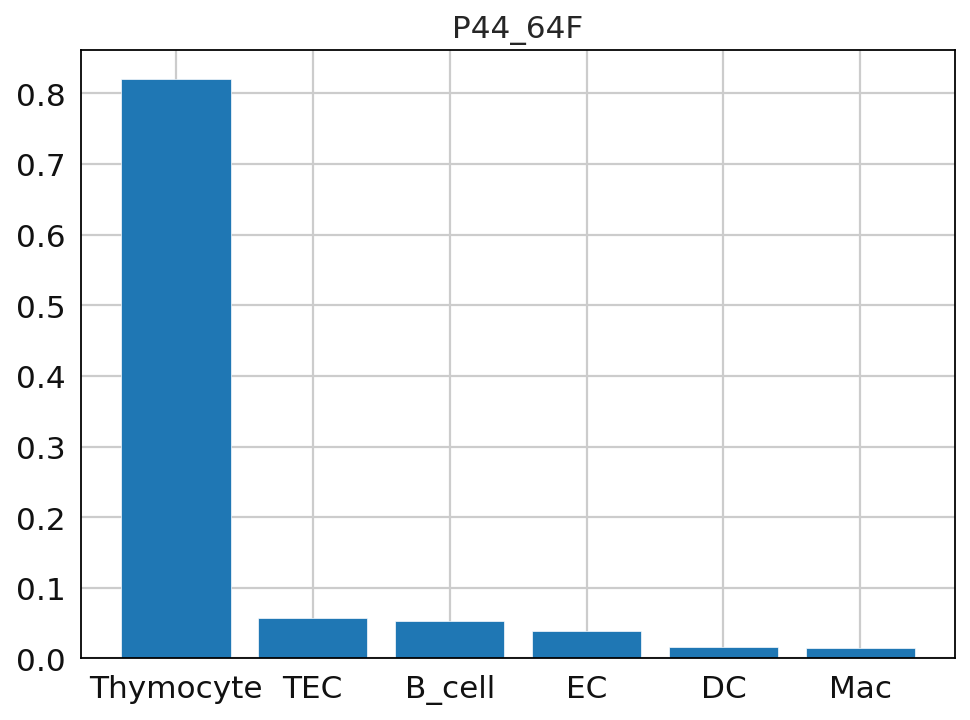

Classifying!
Saving cell type labels to adata!


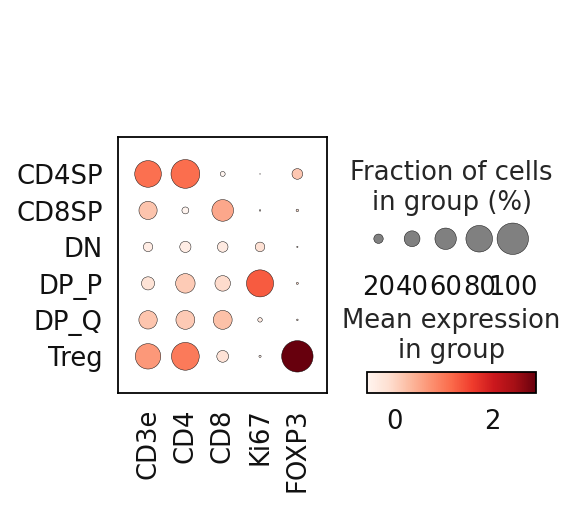

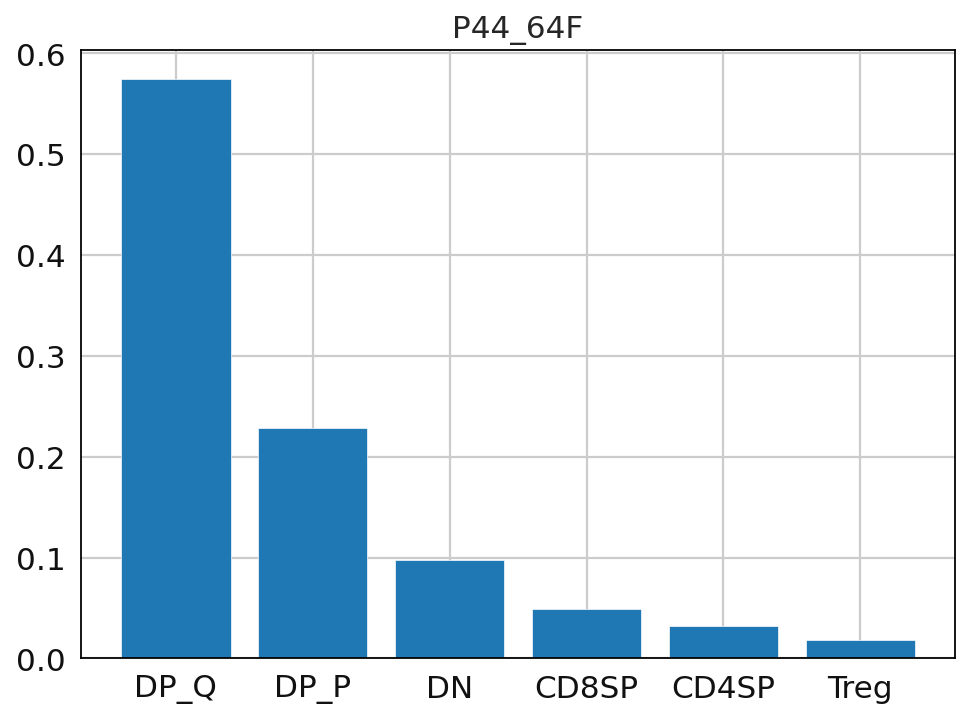

Classifying!
Saving cell type labels to adata!


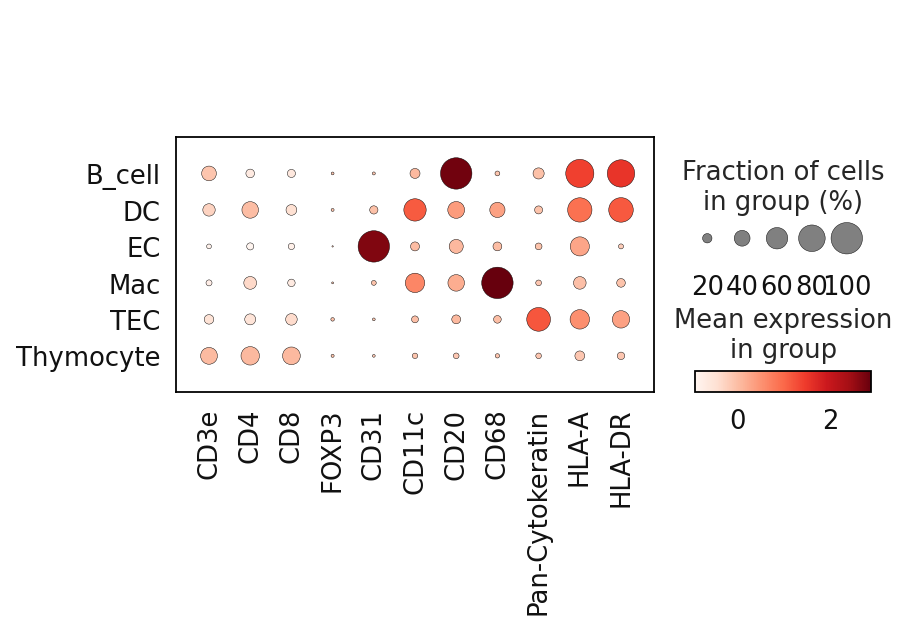

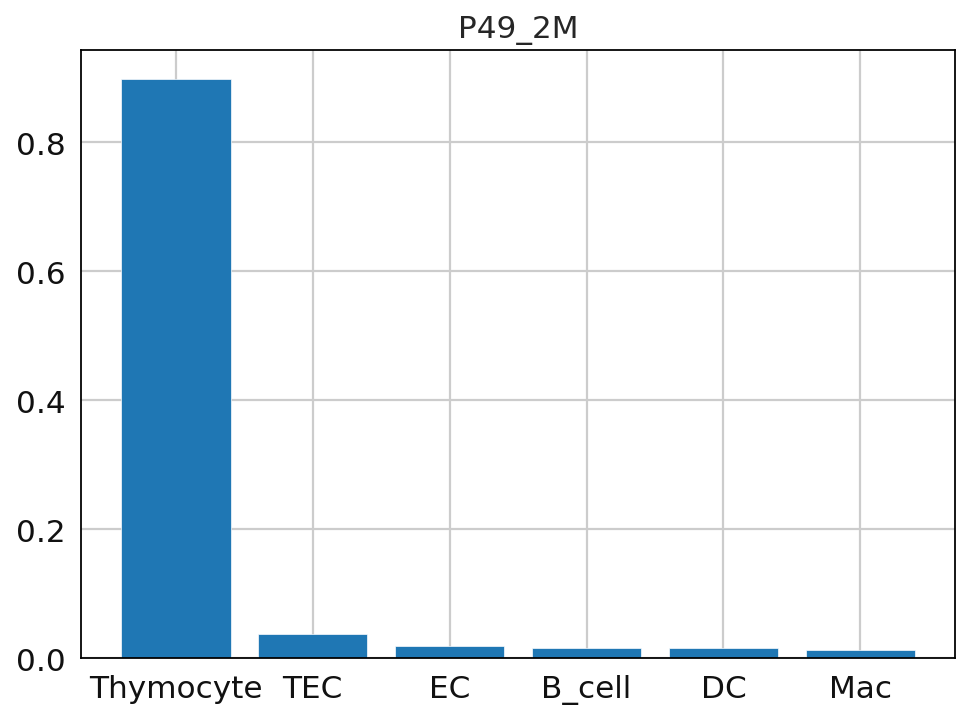

Classifying!
Saving cell type labels to adata!


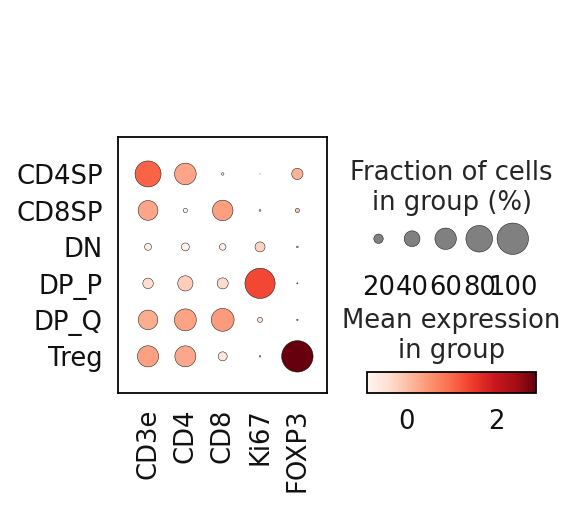

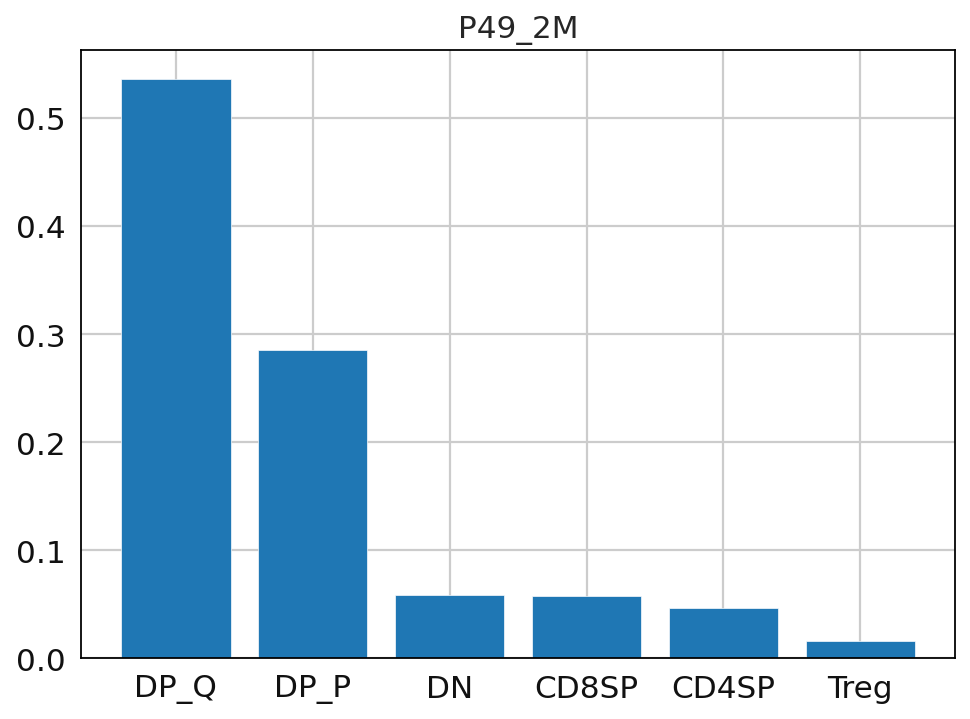

Classifying!
Saving cell type labels to adata!


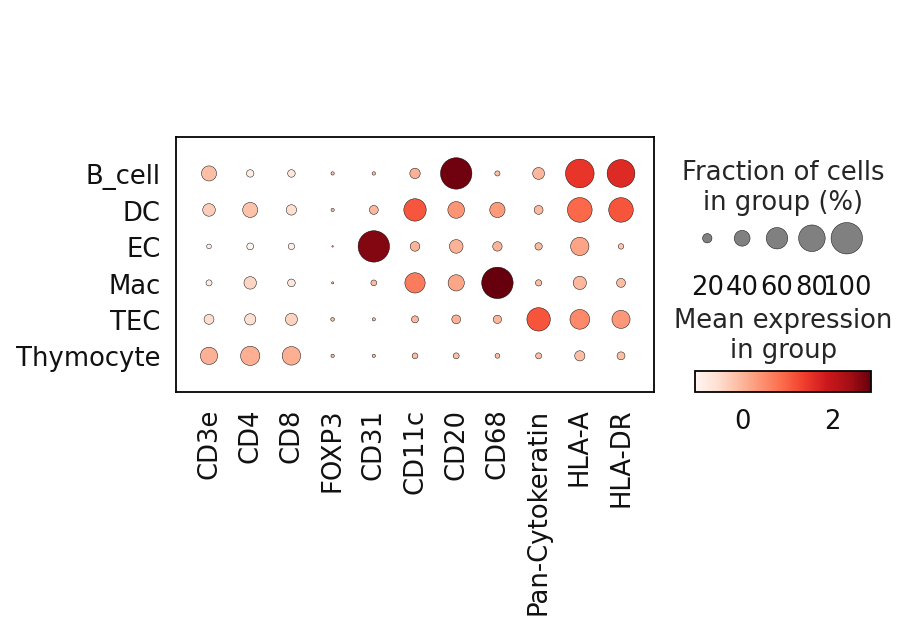

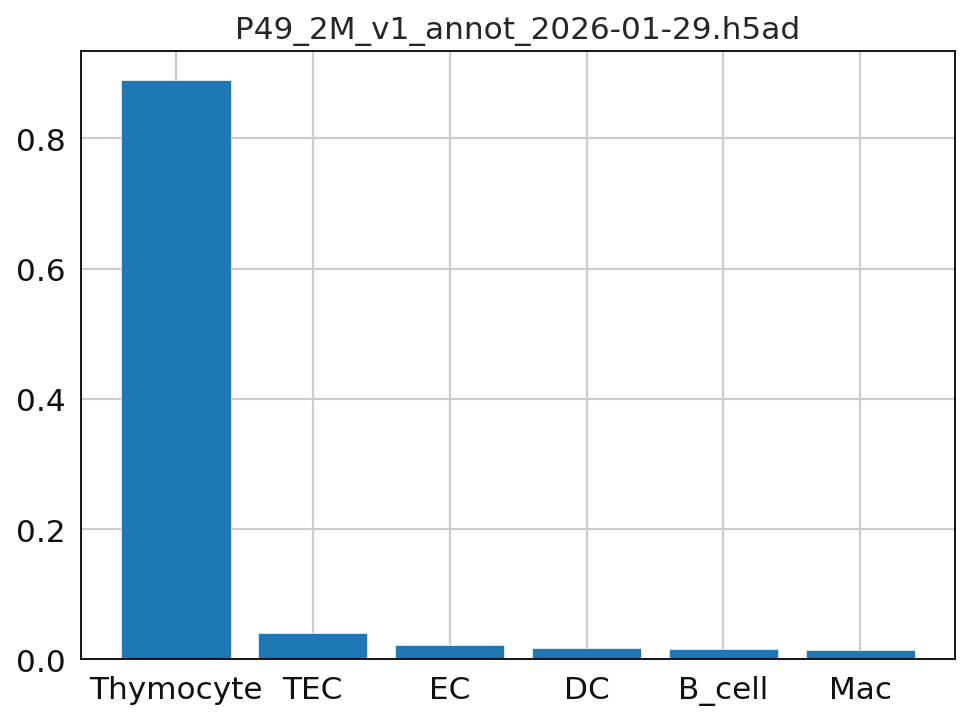

Classifying!
Saving cell type labels to adata!


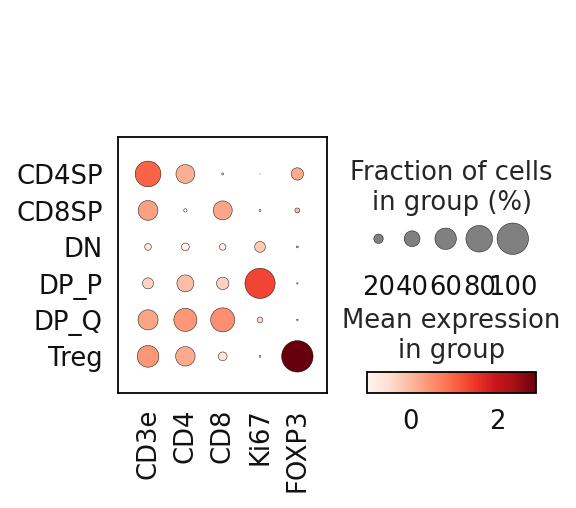

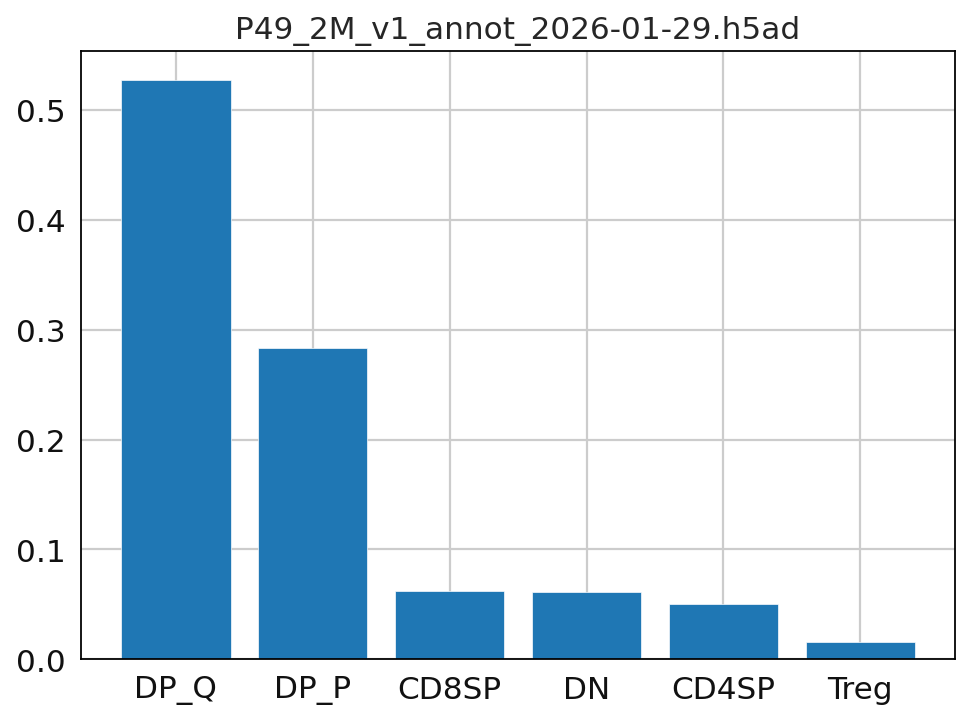

Classifying!
Saving cell type labels to adata!


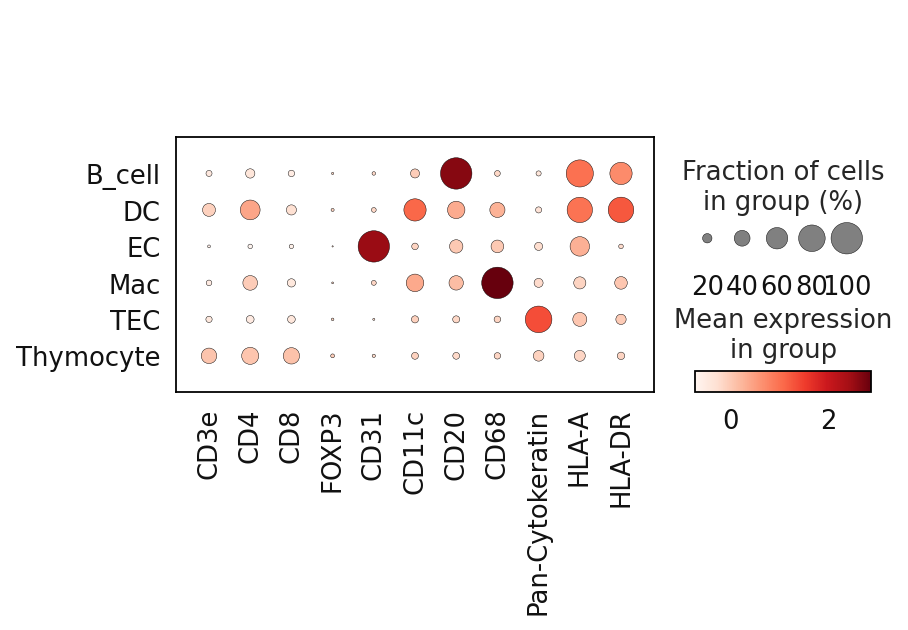

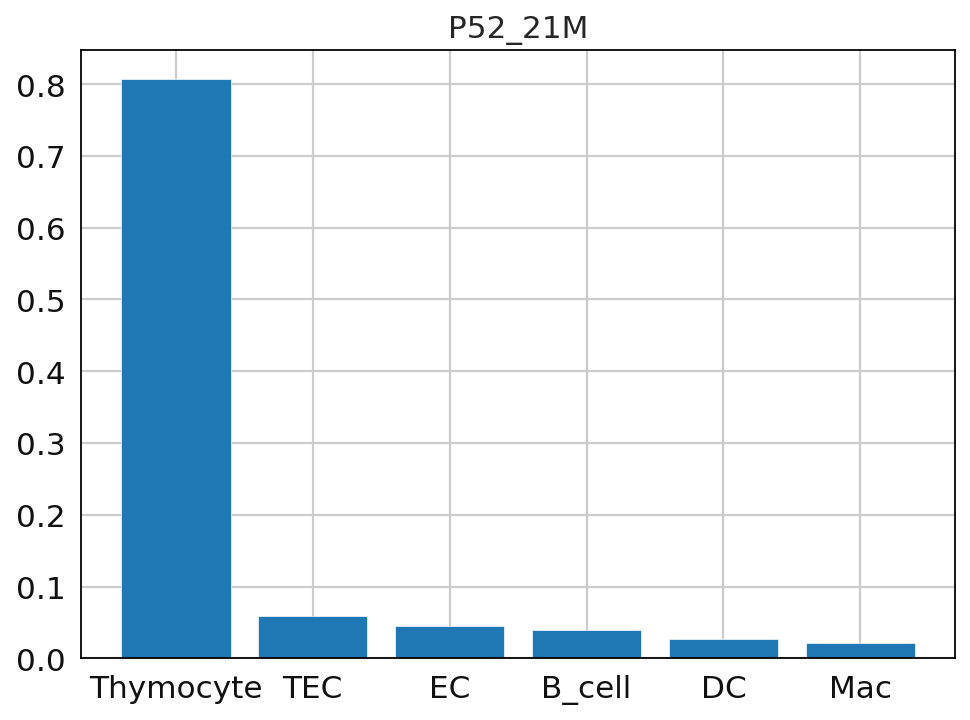

Classifying!
Saving cell type labels to adata!


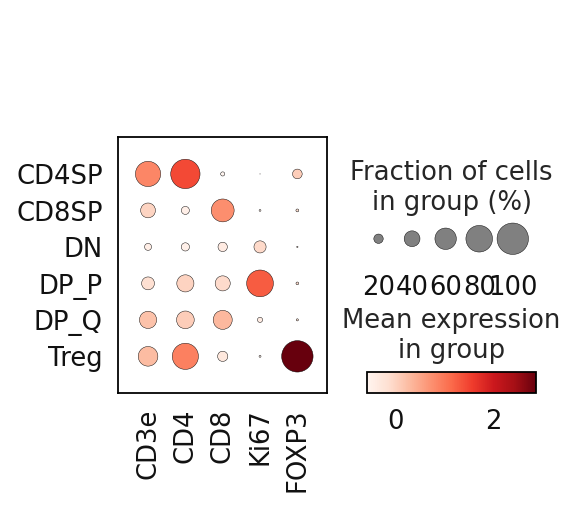

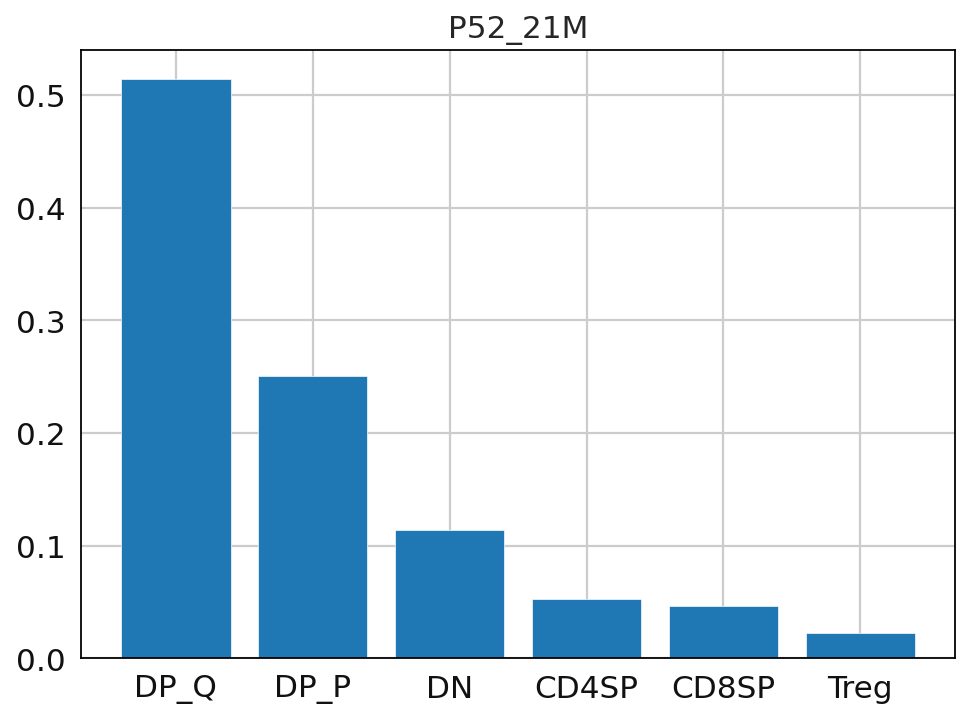

Classifying!
Saving cell type labels to adata!


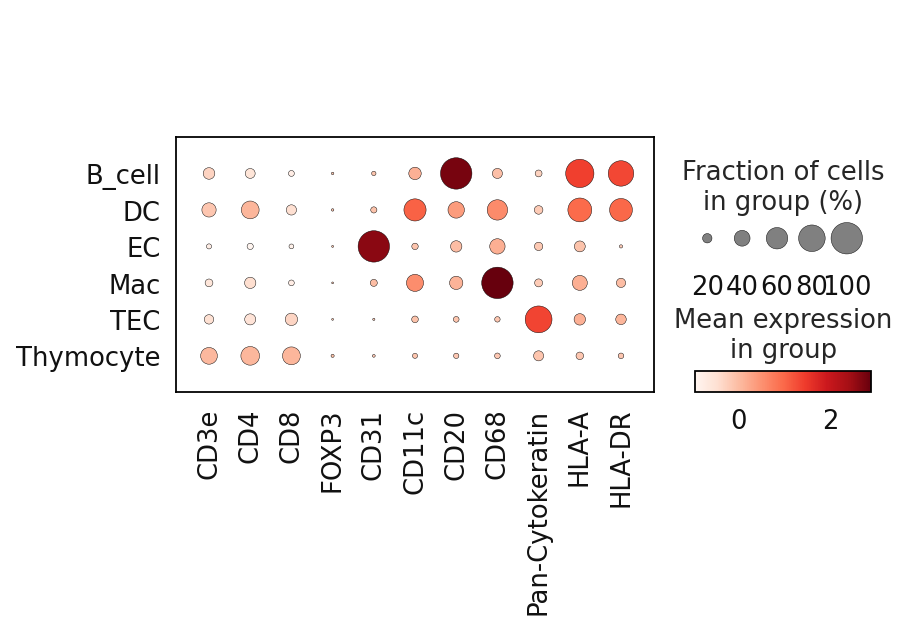

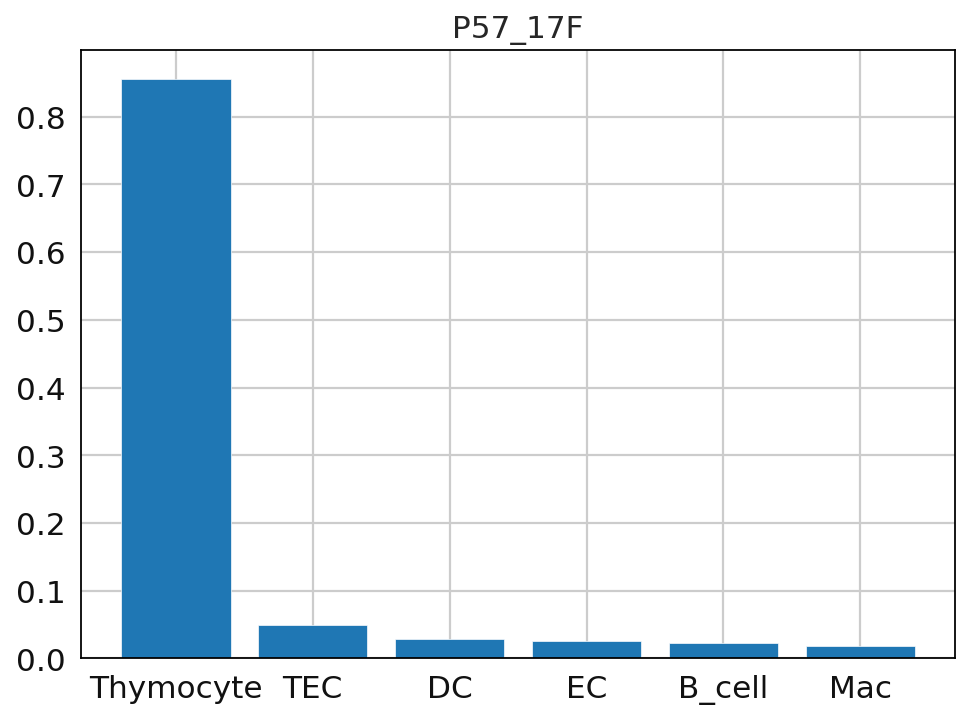

Classifying!
Saving cell type labels to adata!


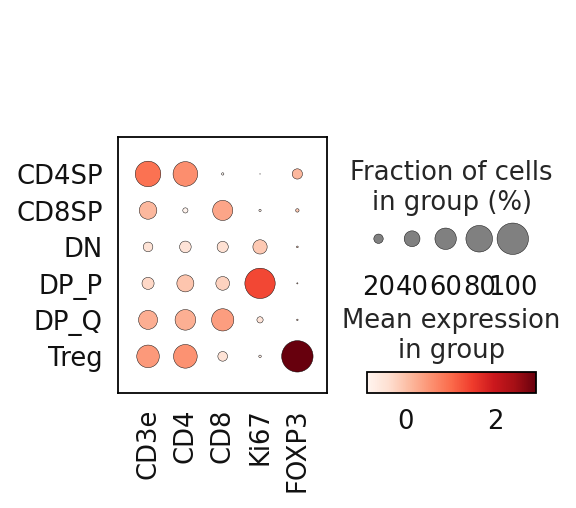

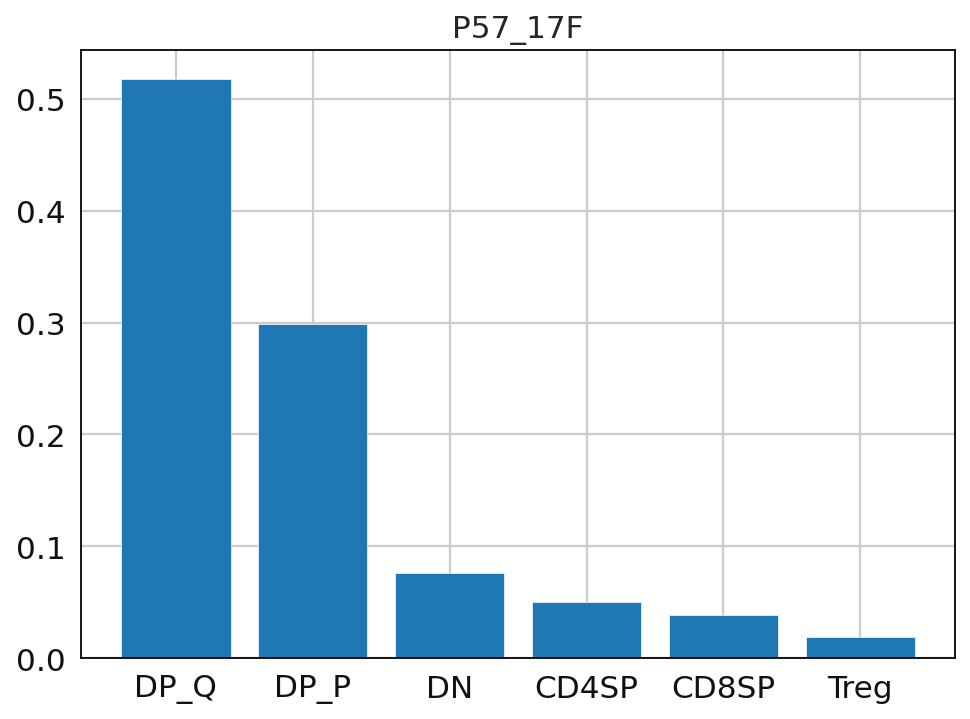

Classifying!
Saving cell type labels to adata!


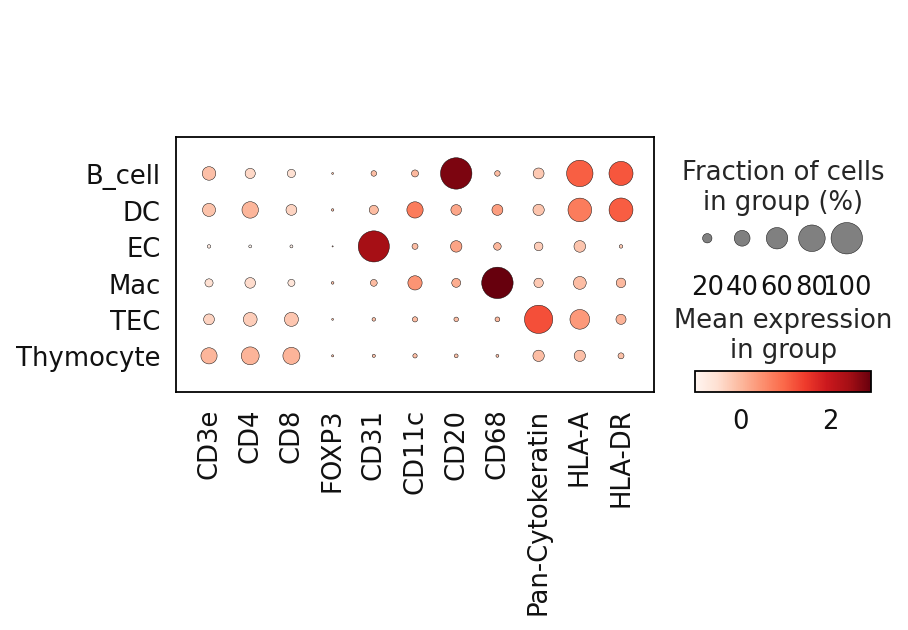

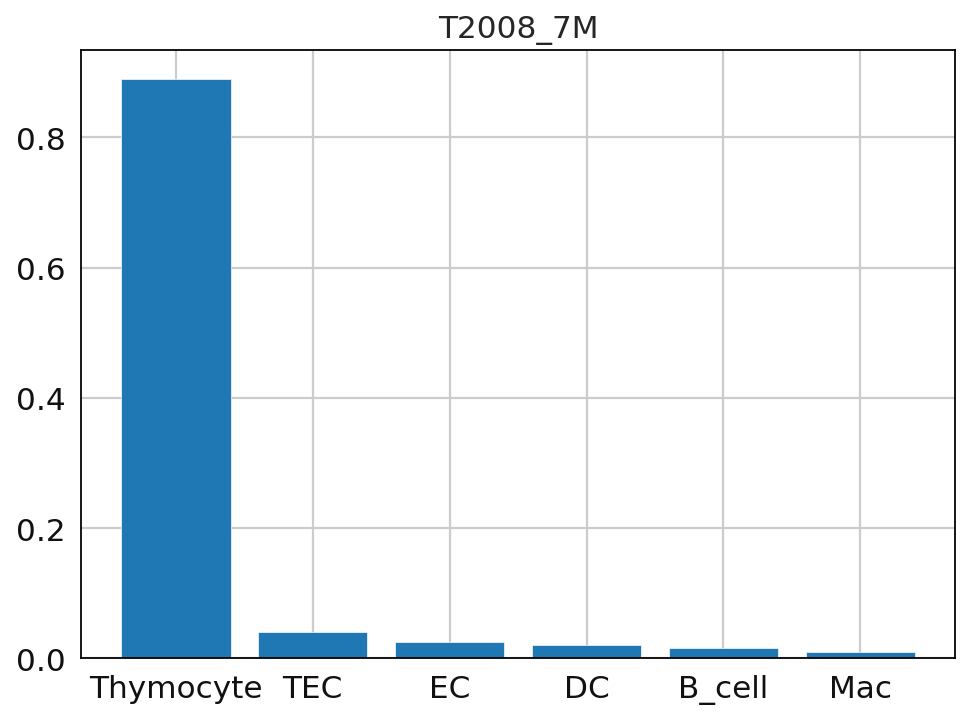

Classifying!
Saving cell type labels to adata!


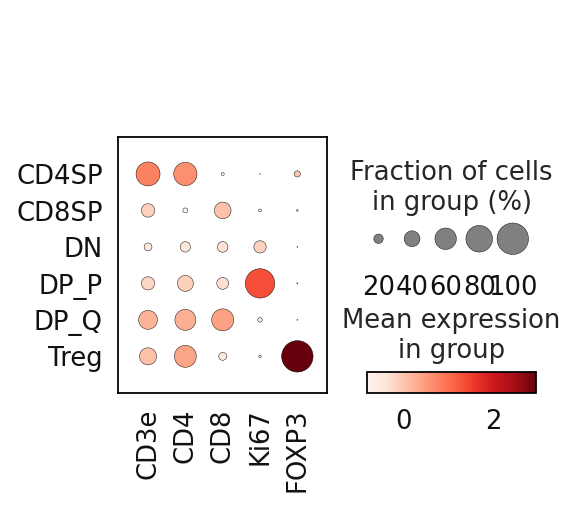

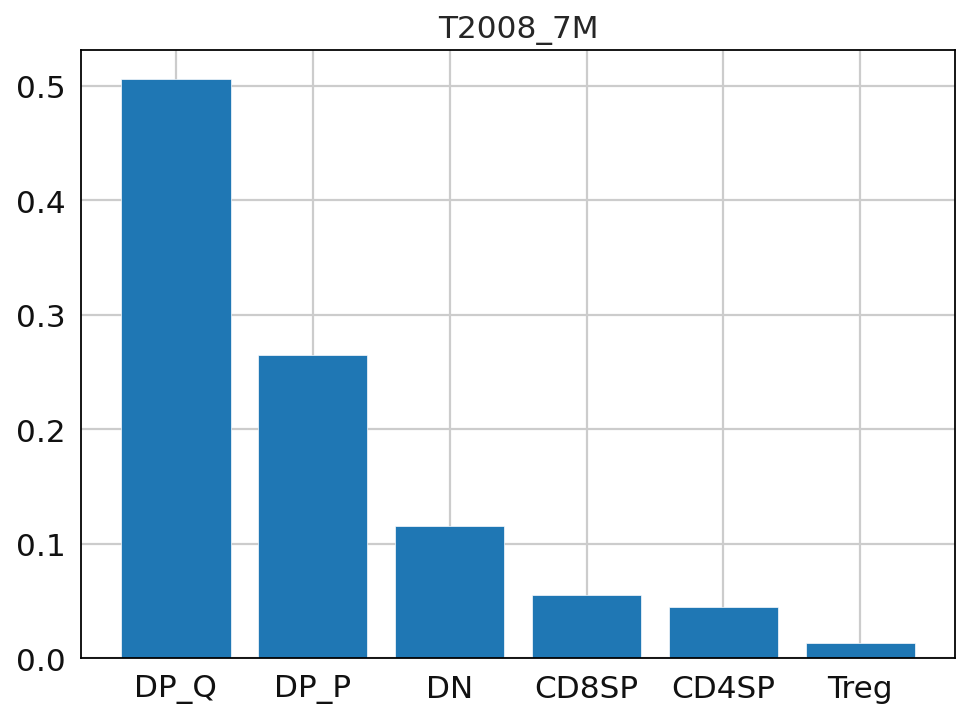

Classifying!
Saving cell type labels to adata!


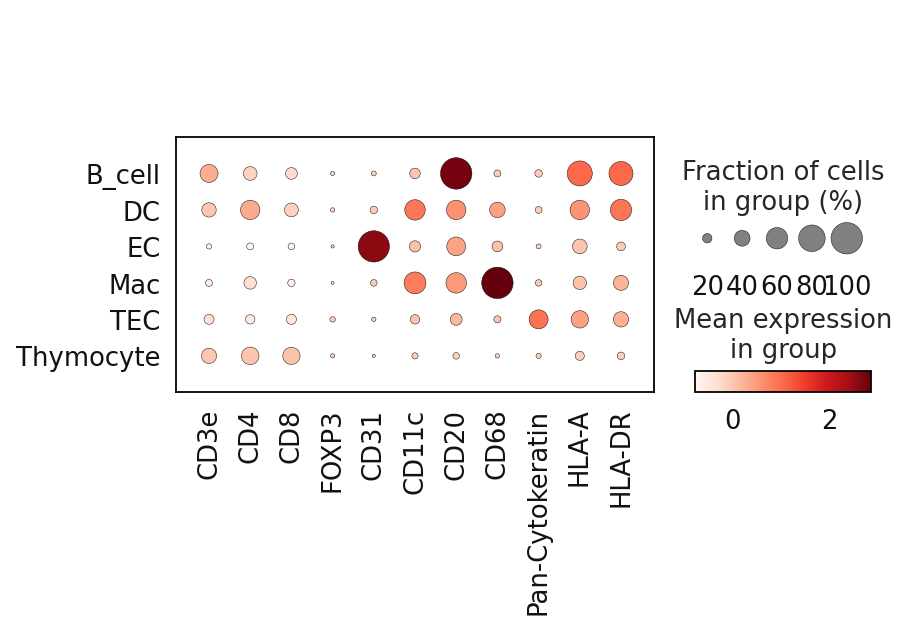

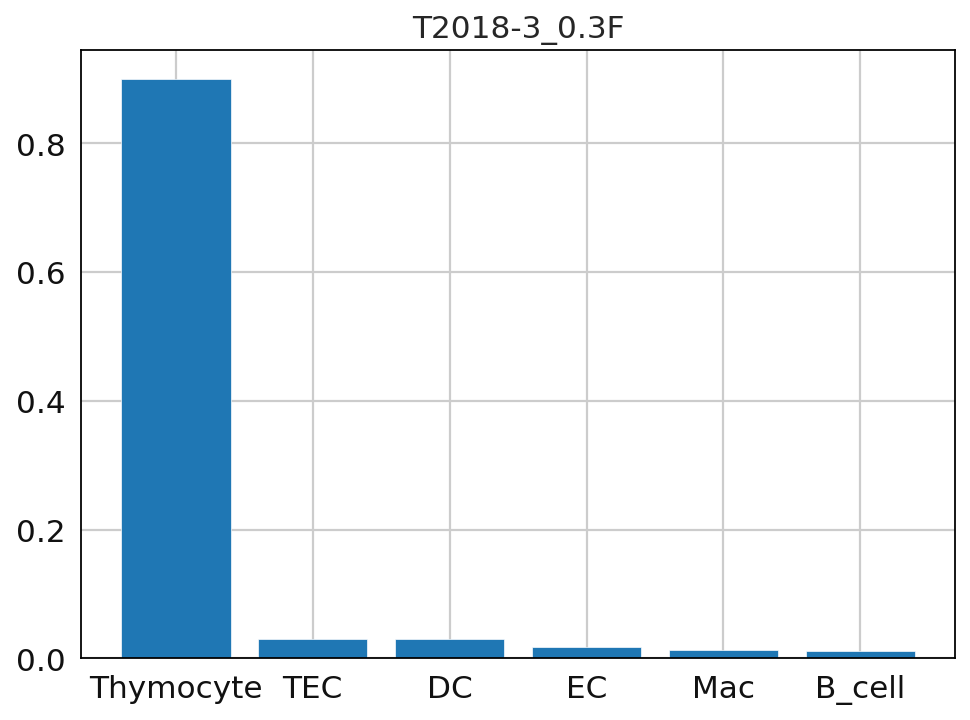

Classifying!
Saving cell type labels to adata!


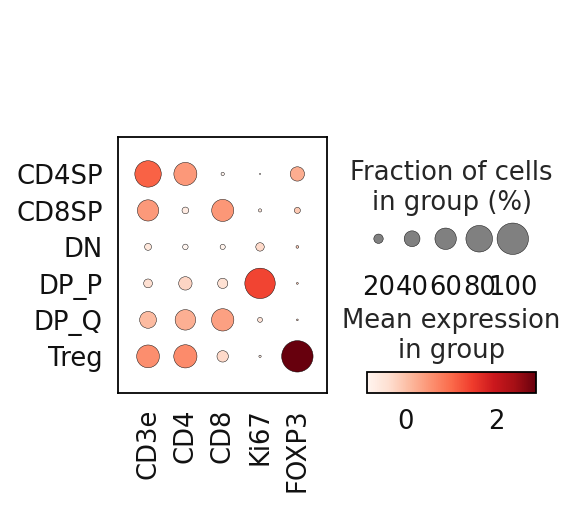

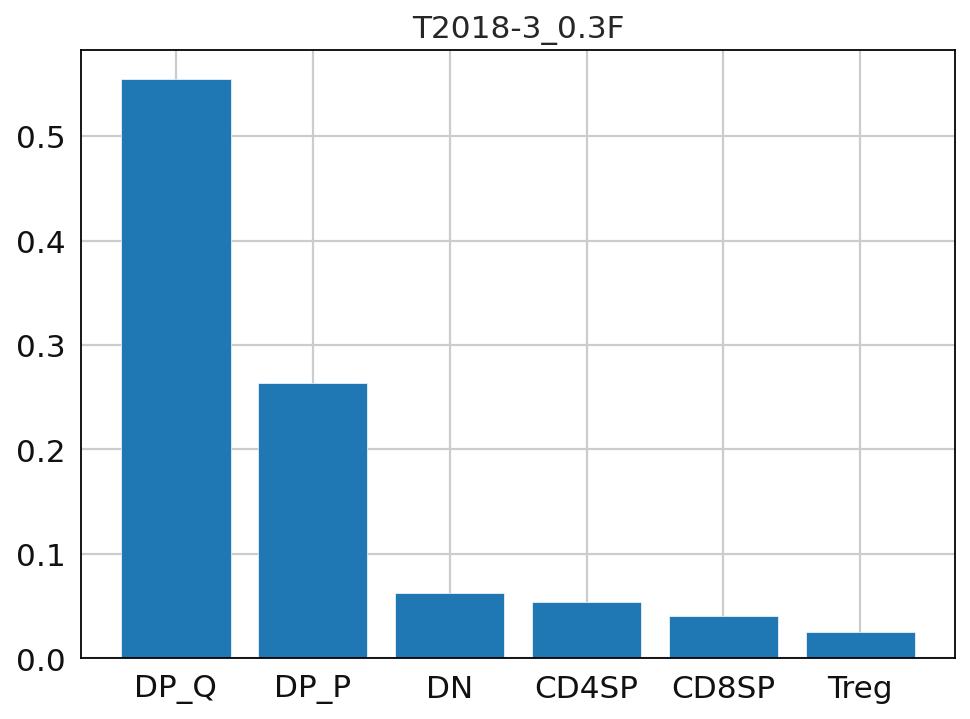

Classifying!
Saving cell type labels to adata!


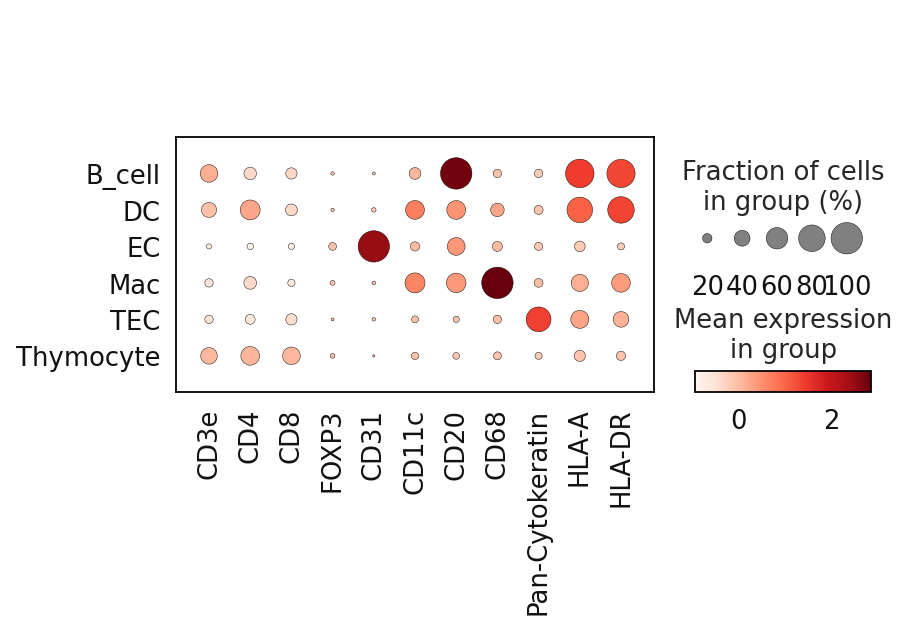

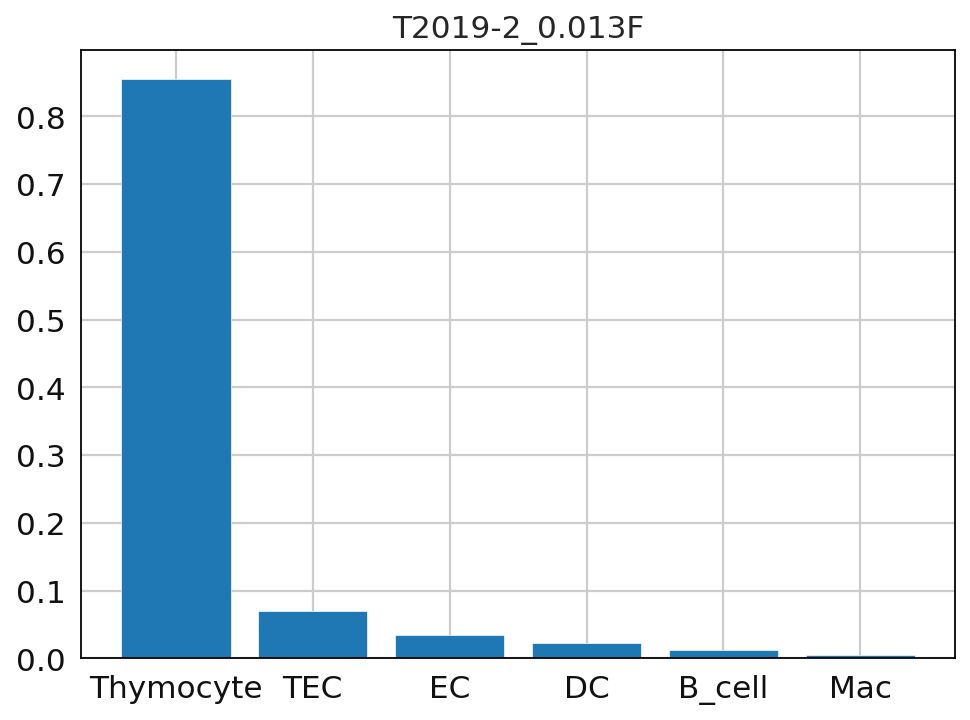

Classifying!
Saving cell type labels to adata!


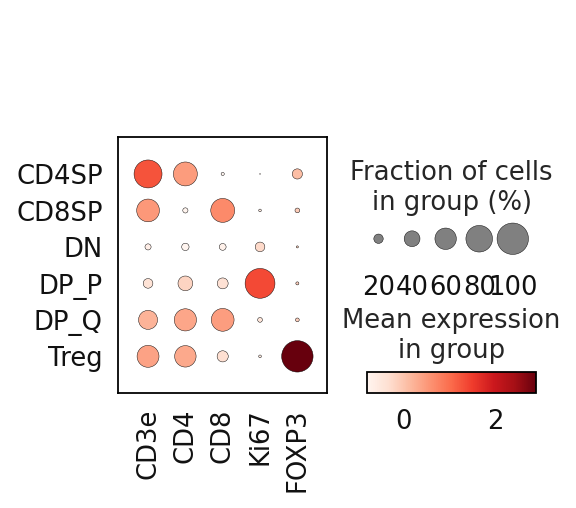

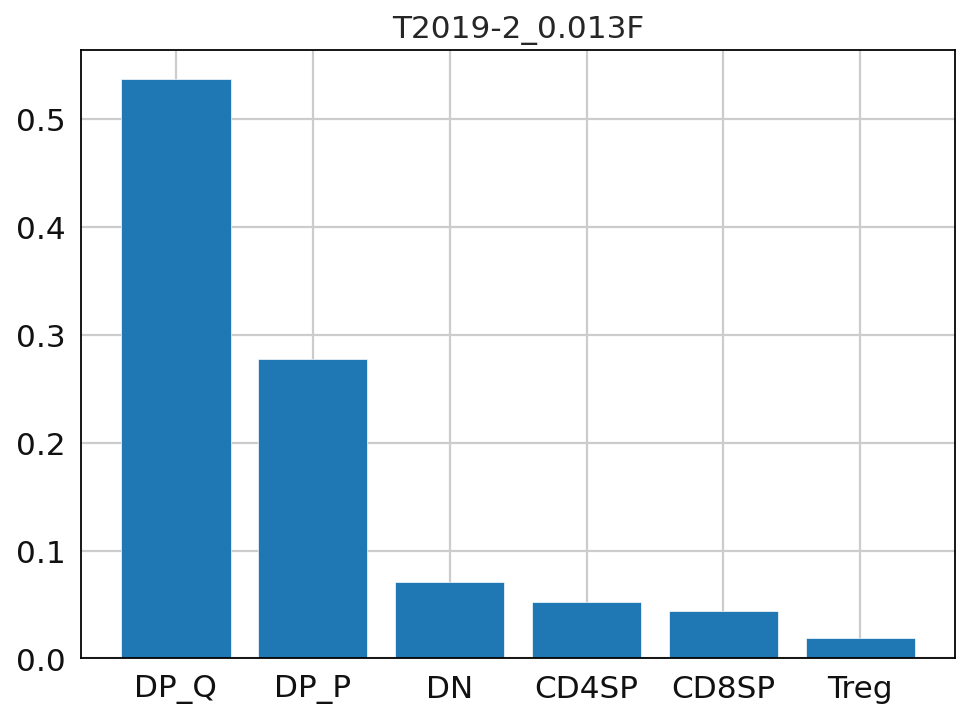

Classifying!
Saving cell type labels to adata!


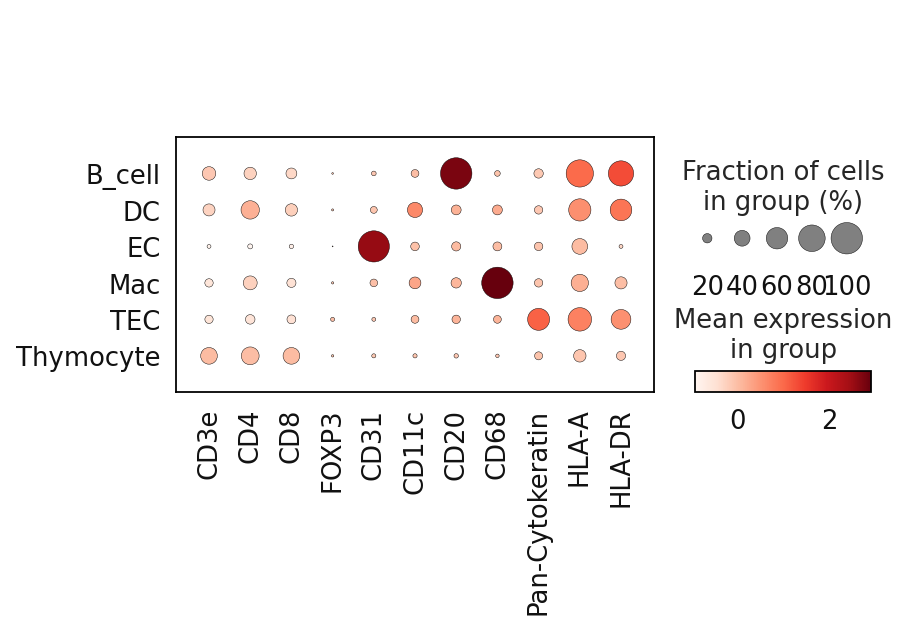

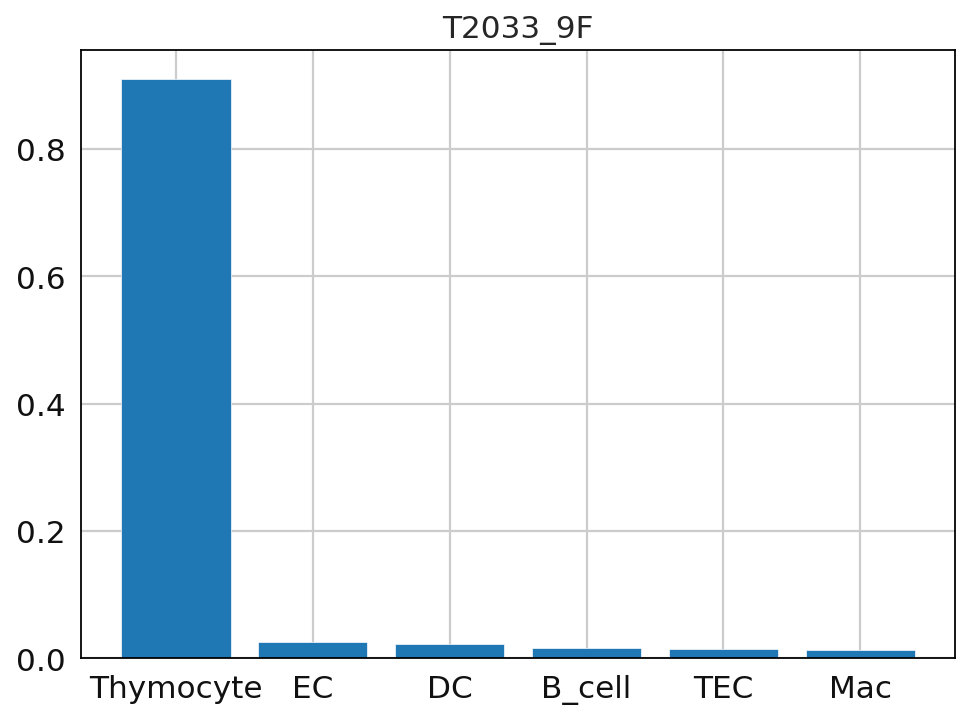

Classifying!
Saving cell type labels to adata!


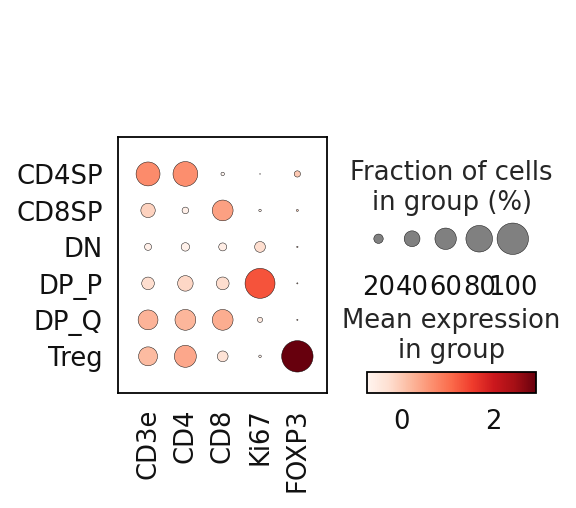

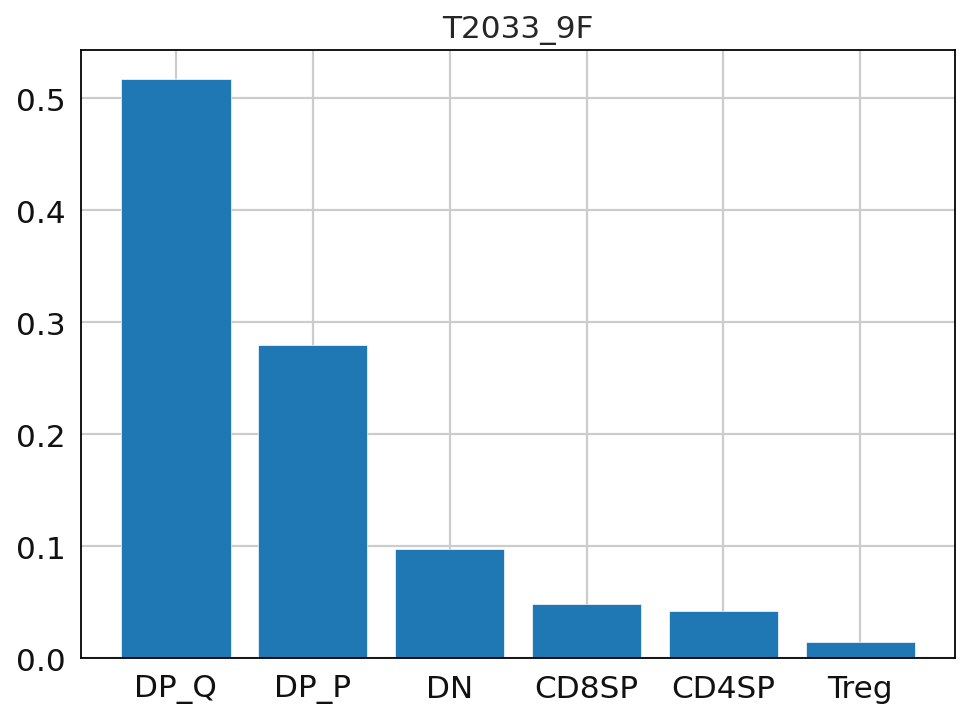

Classifying!
Saving cell type labels to adata!


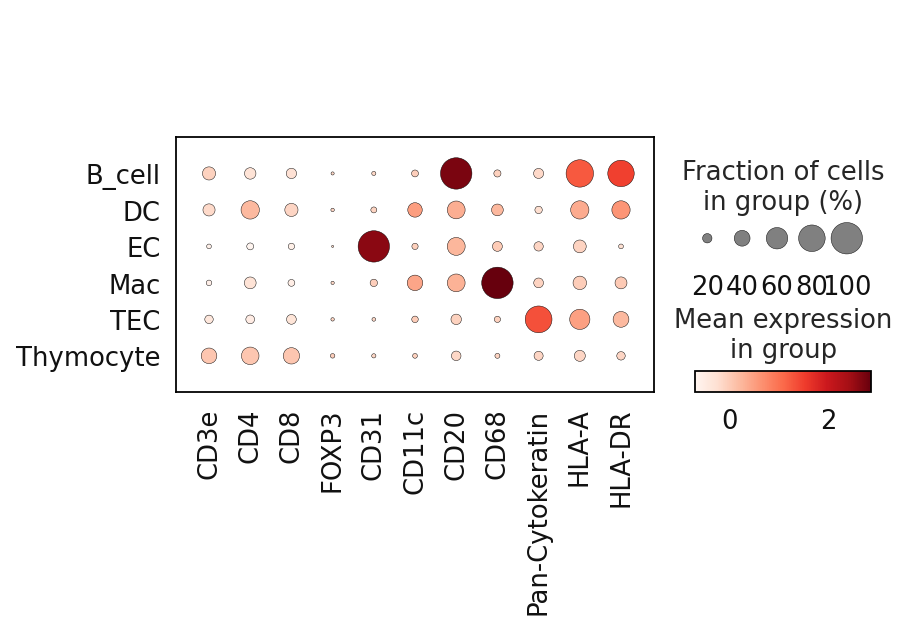

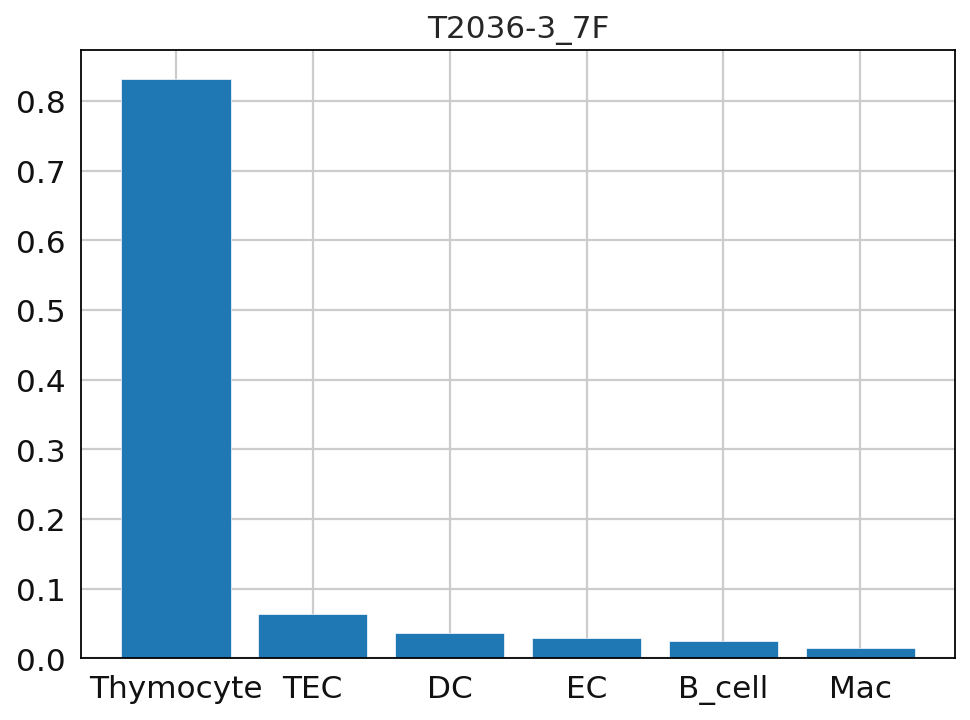

Classifying!
Saving cell type labels to adata!


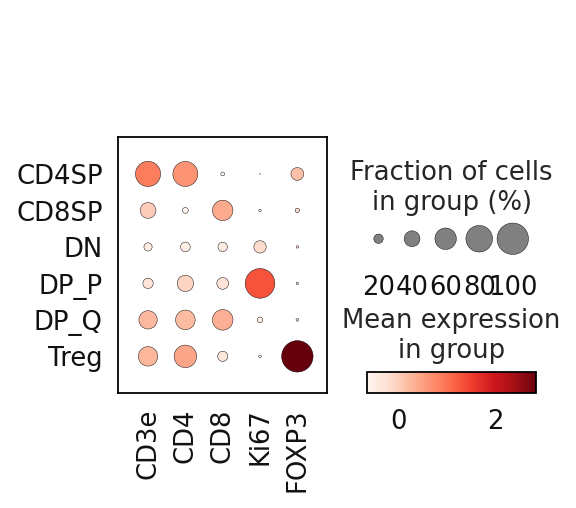

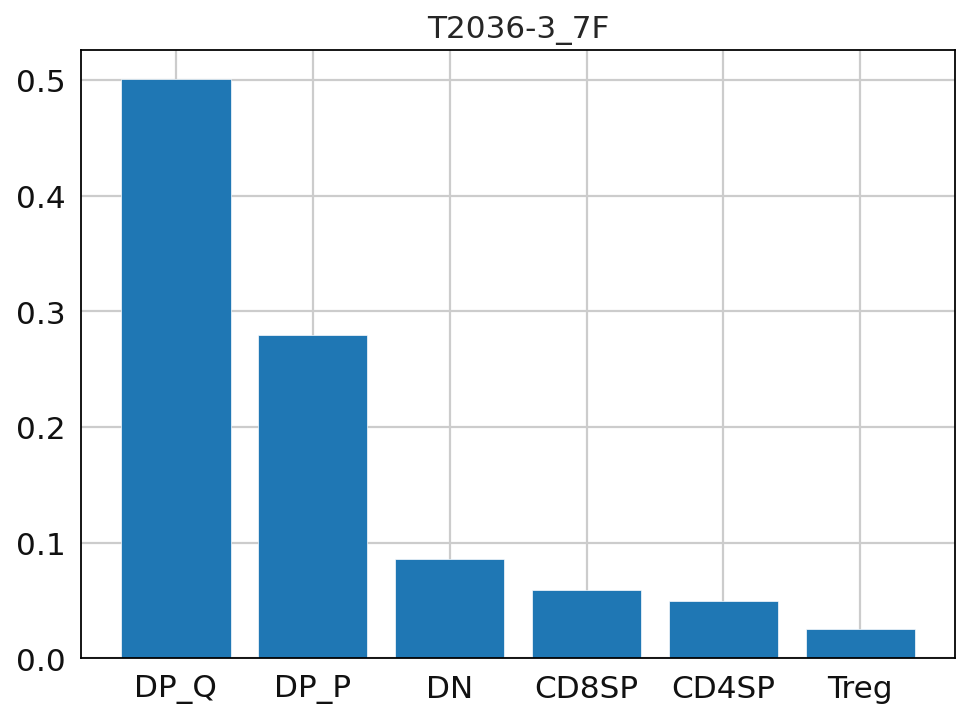

Classifying!
Saving cell type labels to adata!


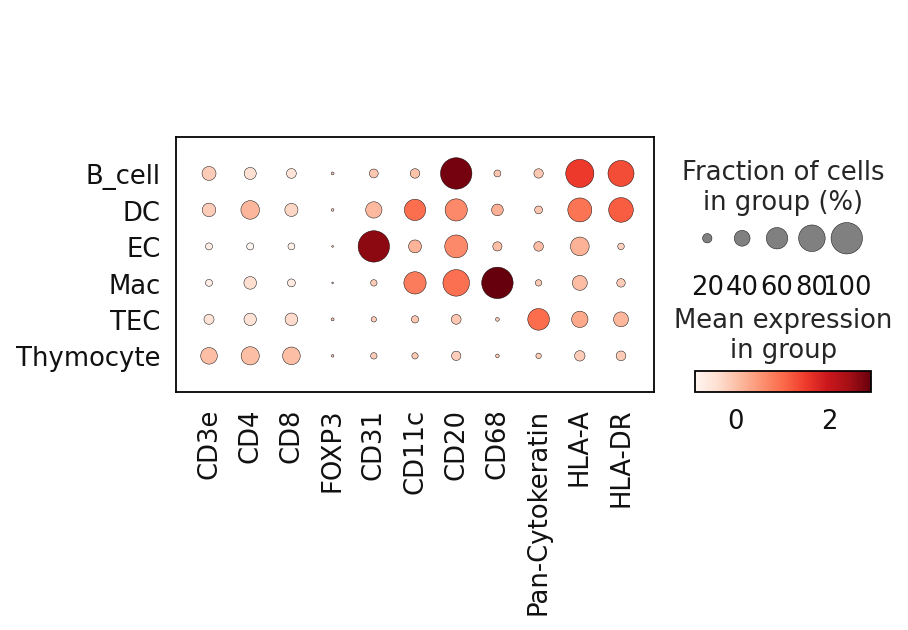

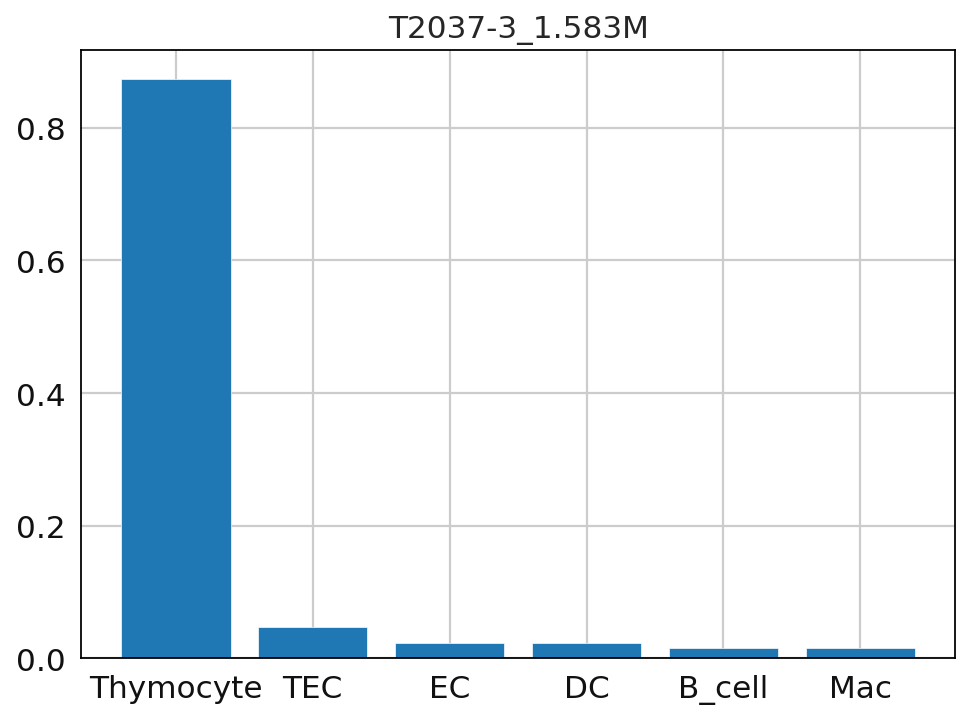

Classifying!
Saving cell type labels to adata!


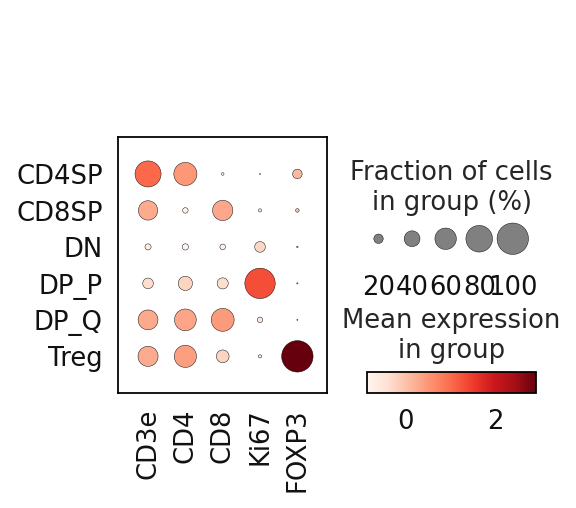

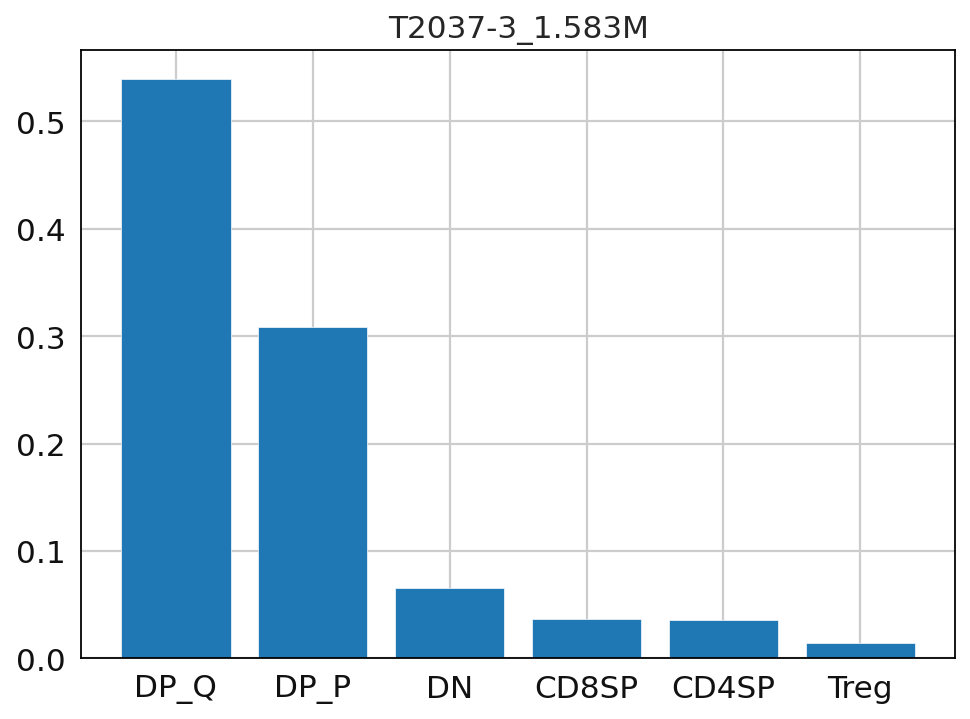

Classifying!
Saving cell type labels to adata!


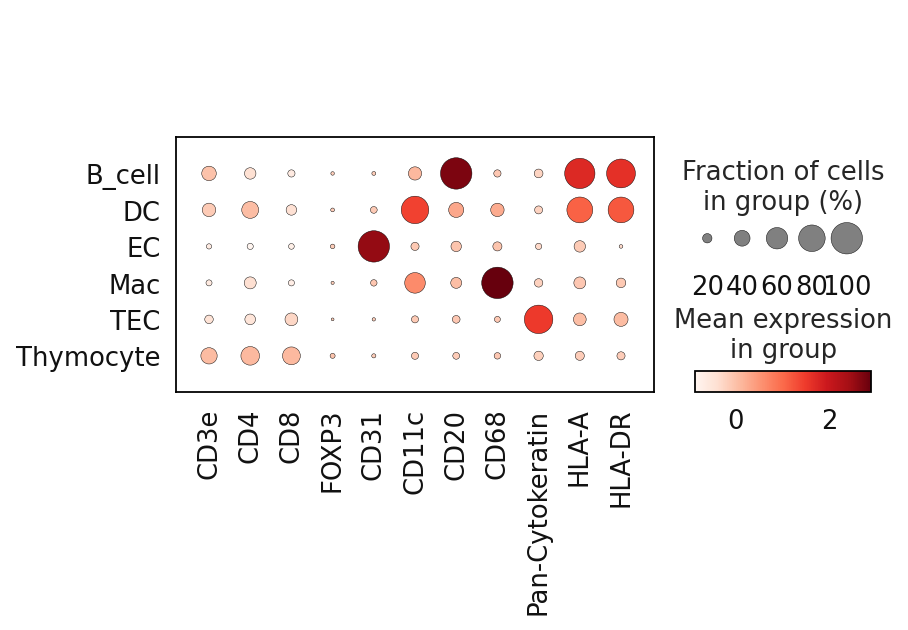

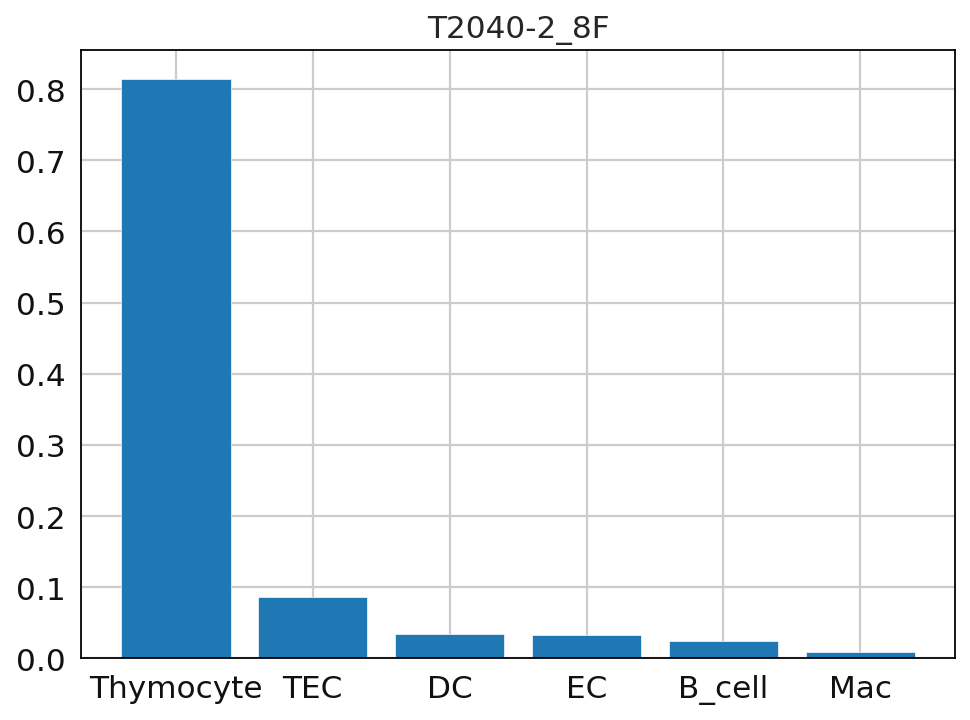

Classifying!
Saving cell type labels to adata!


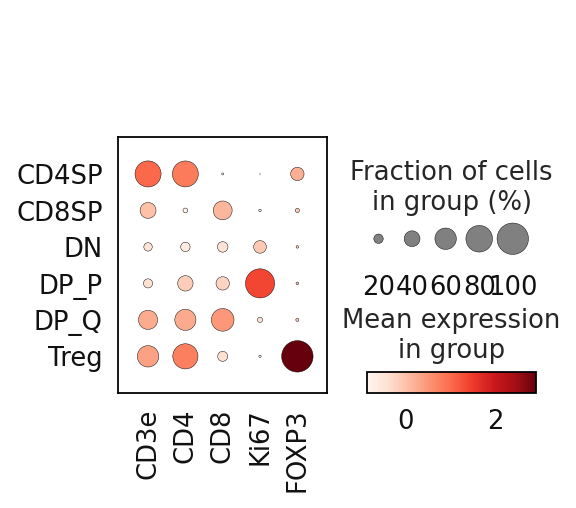

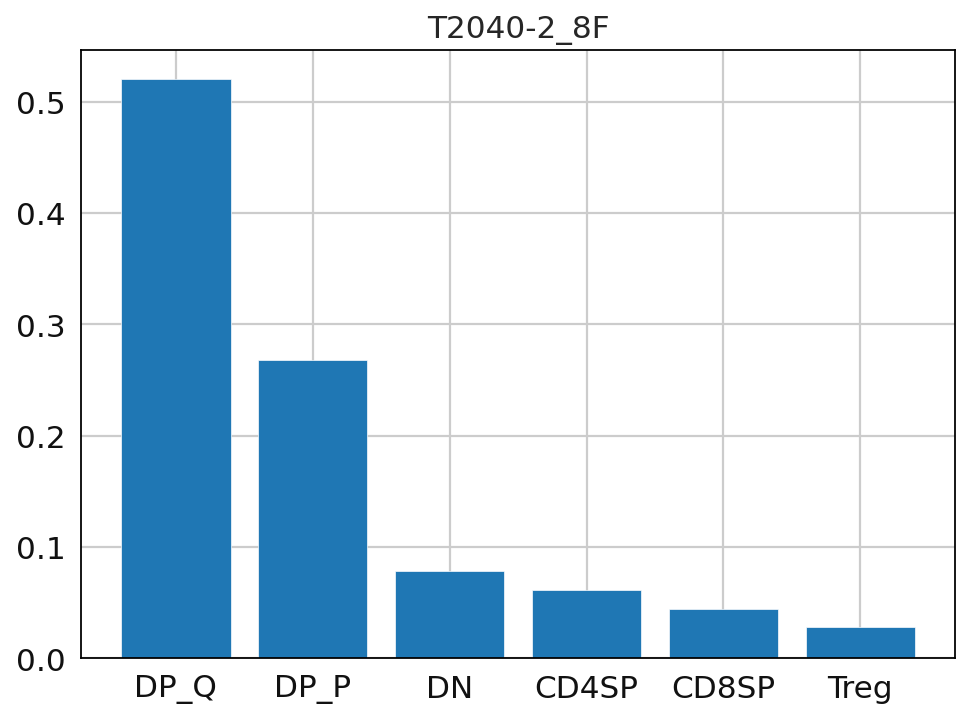

Classifying!
Saving cell type labels to adata!


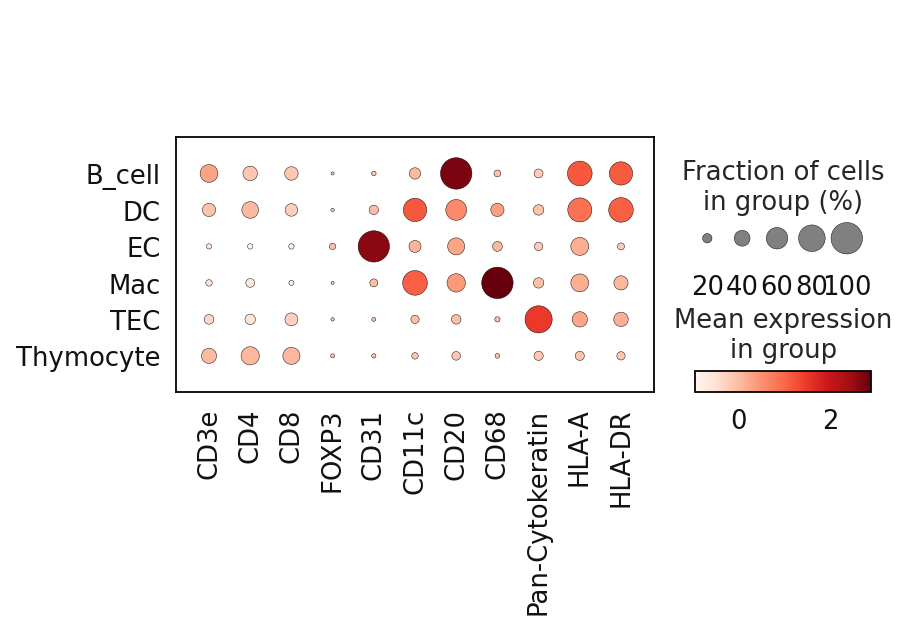

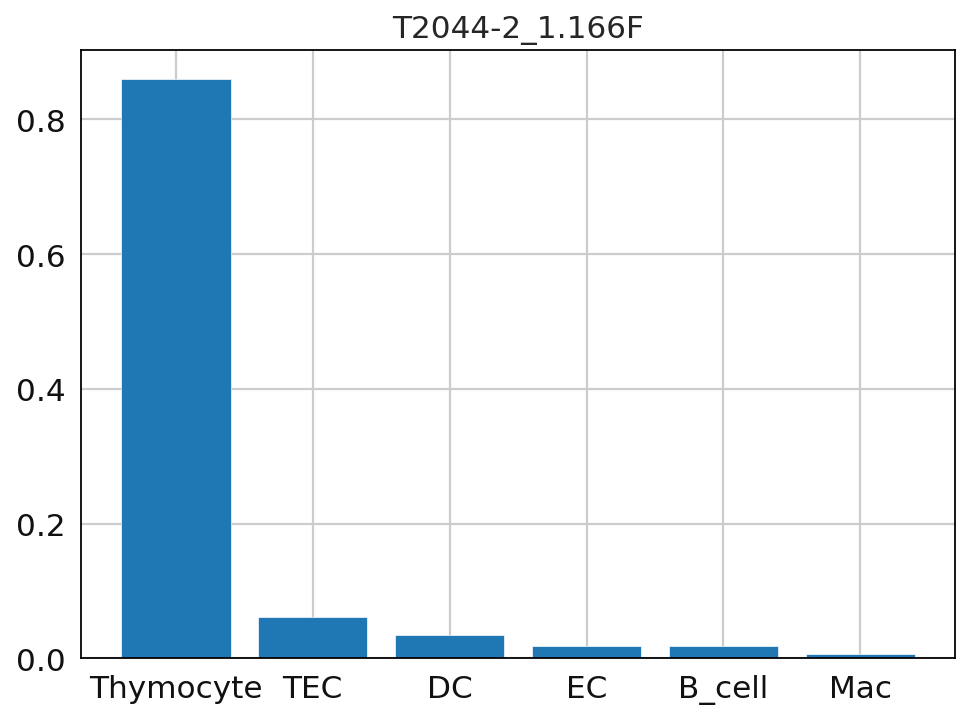

Classifying!
Saving cell type labels to adata!


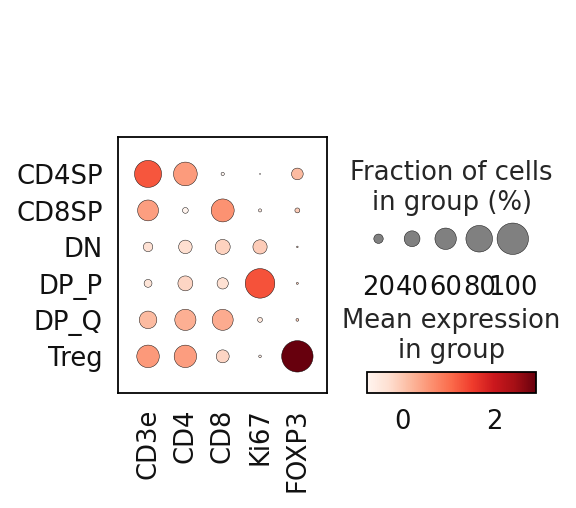

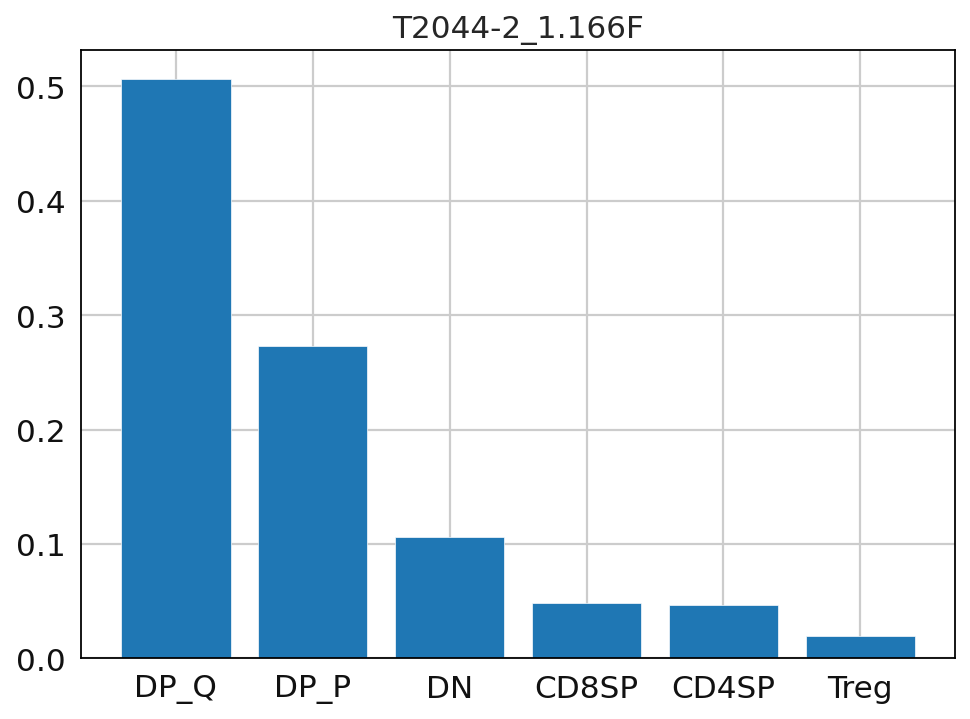

Classifying!
Saving cell type labels to adata!


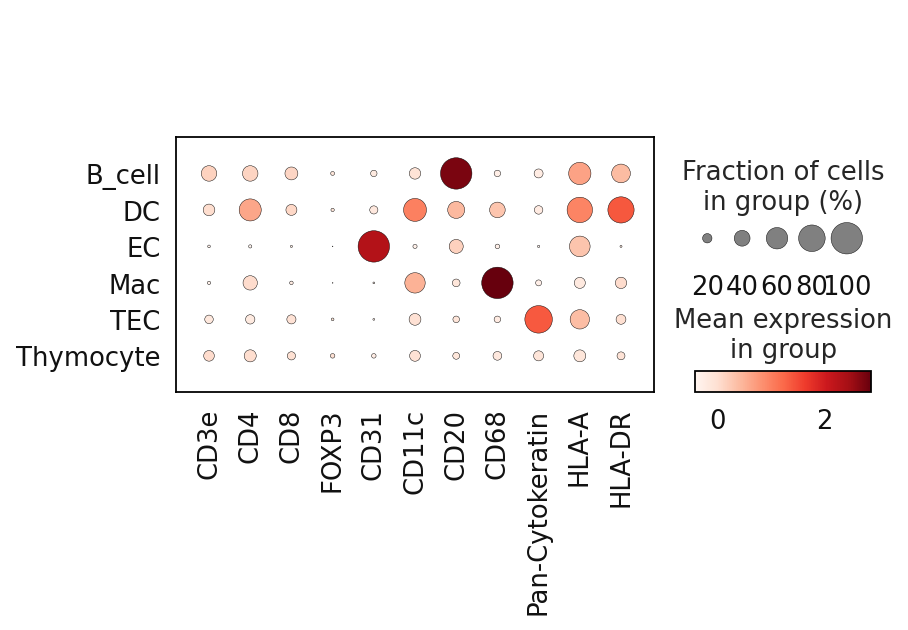

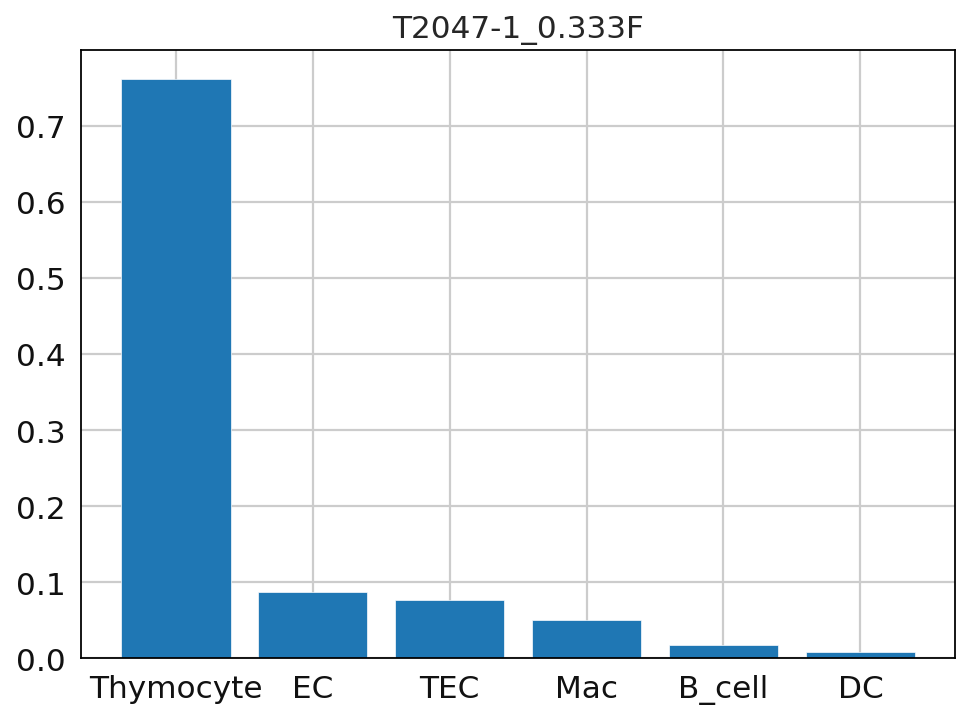

Classifying!
Saving cell type labels to adata!


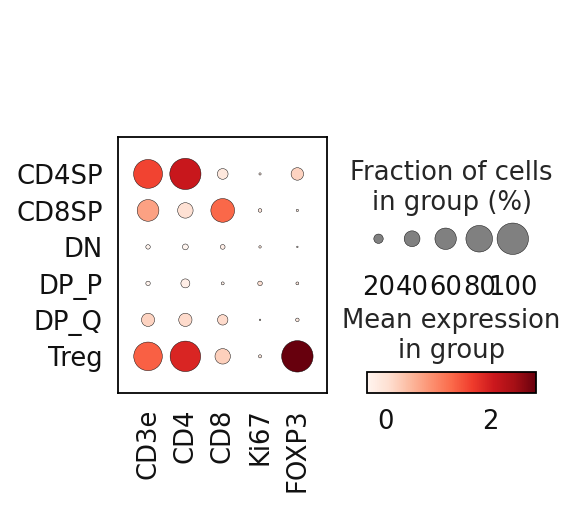

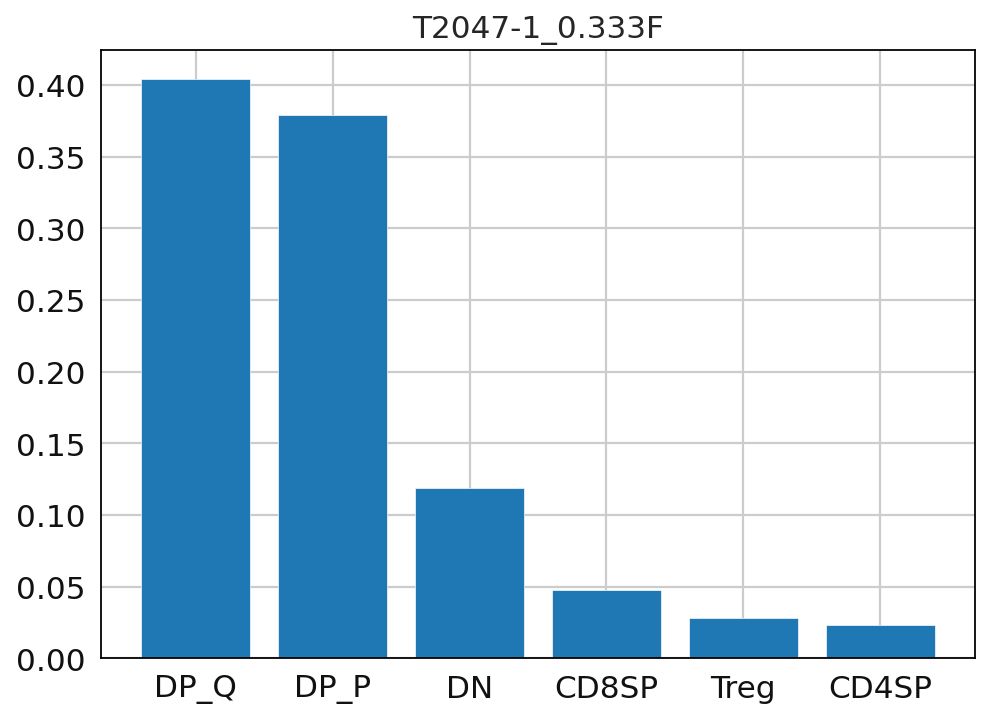

Classifying!
Saving cell type labels to adata!


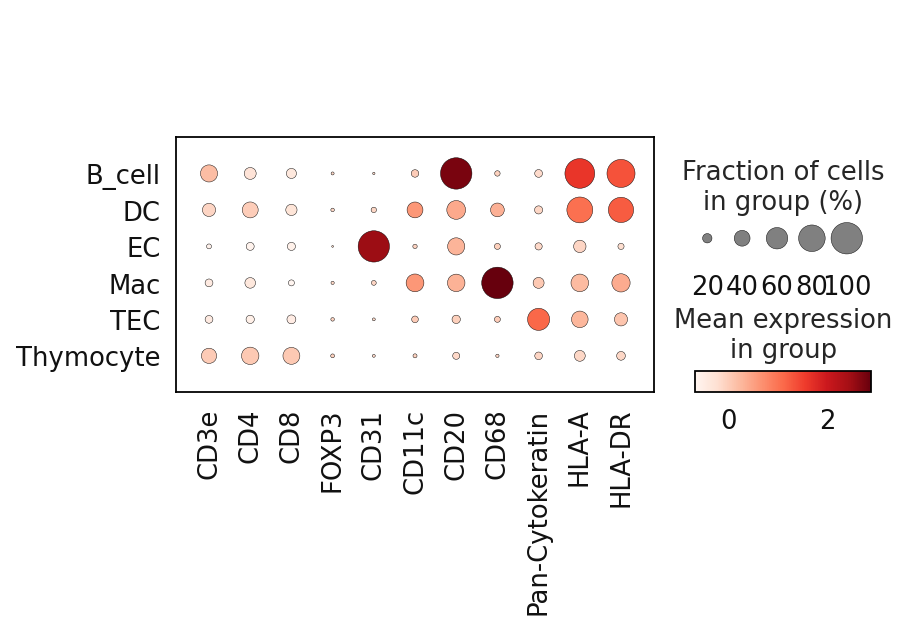

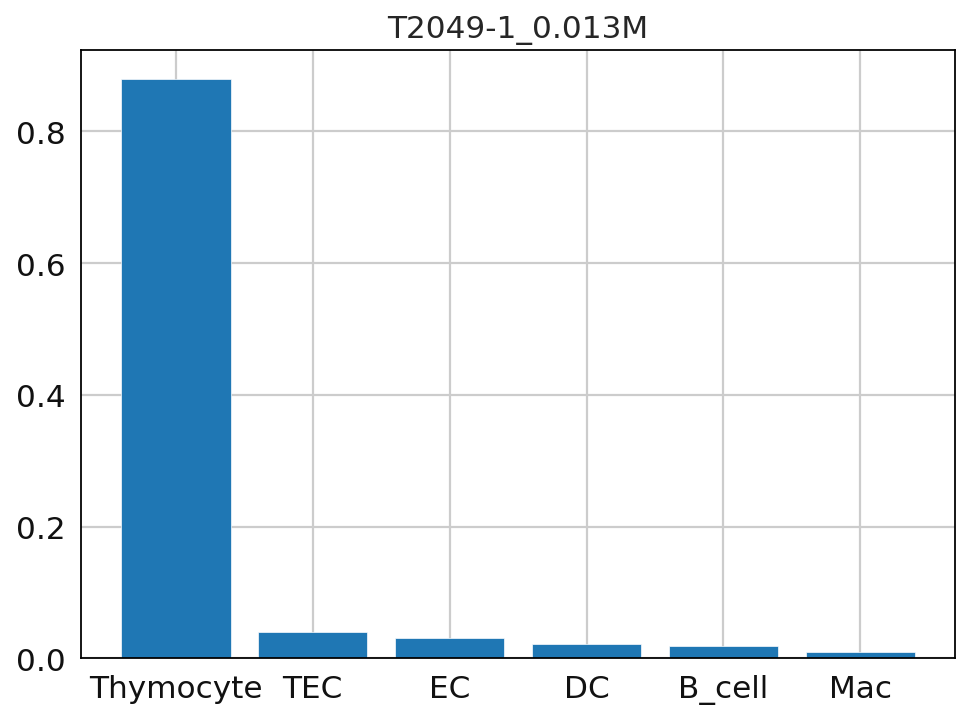

Classifying!
Saving cell type labels to adata!


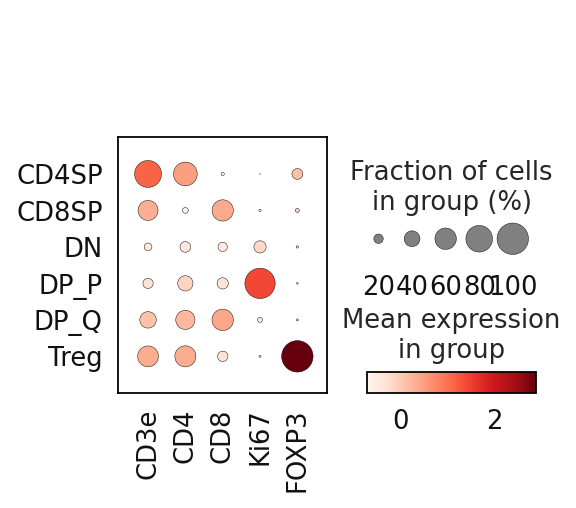

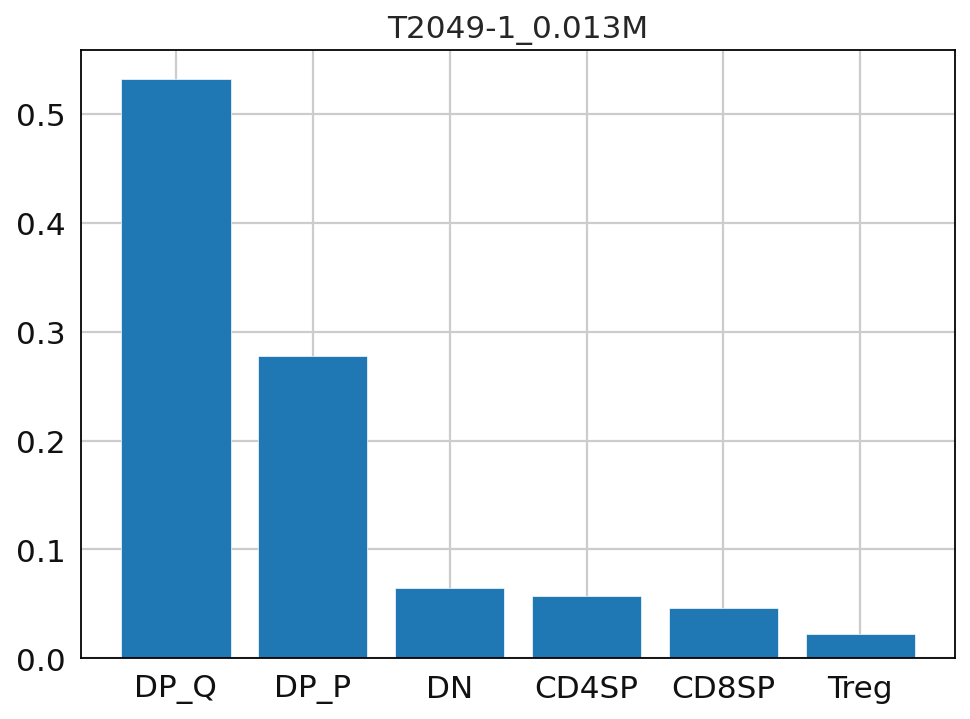

Classifying!
Saving cell type labels to adata!


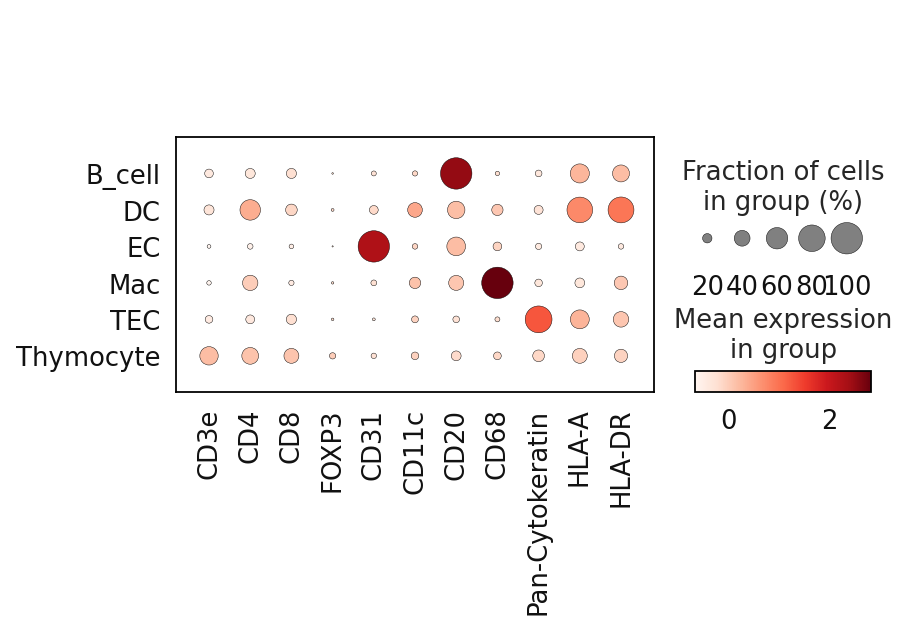

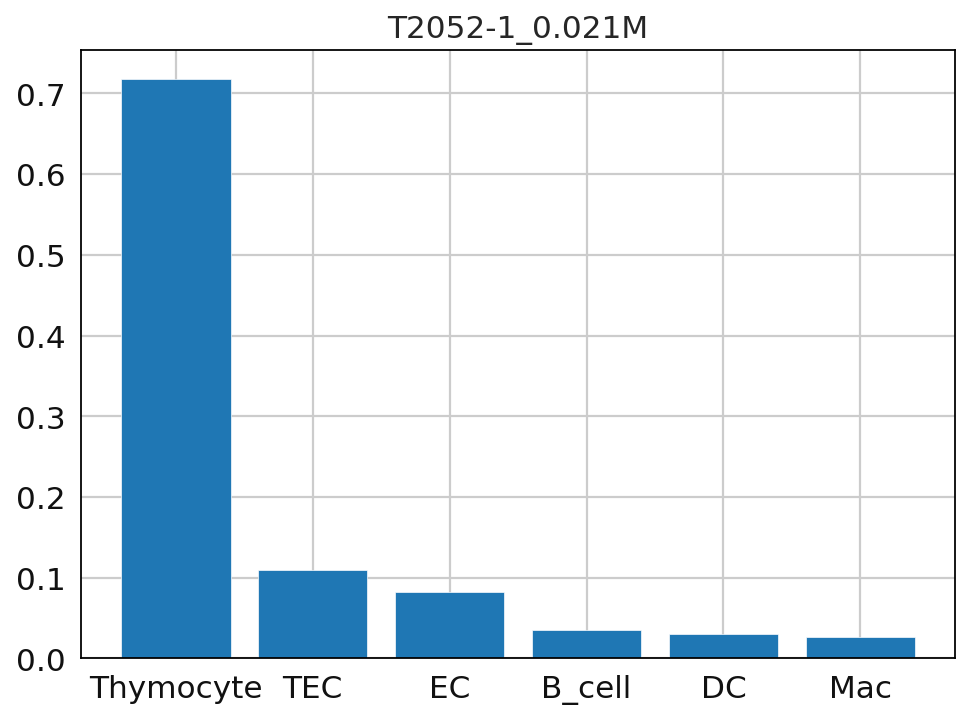

Classifying!
Saving cell type labels to adata!


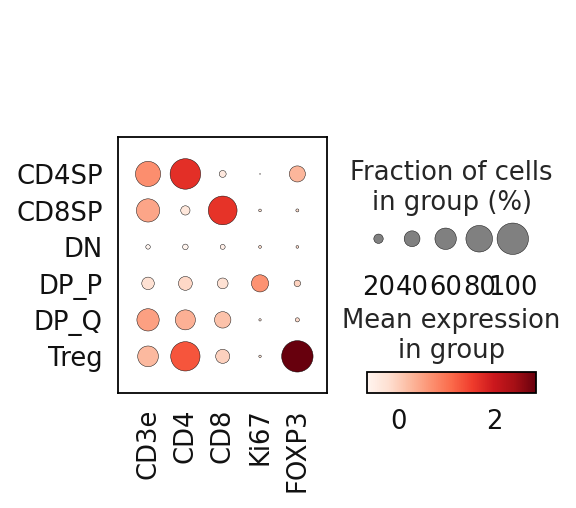

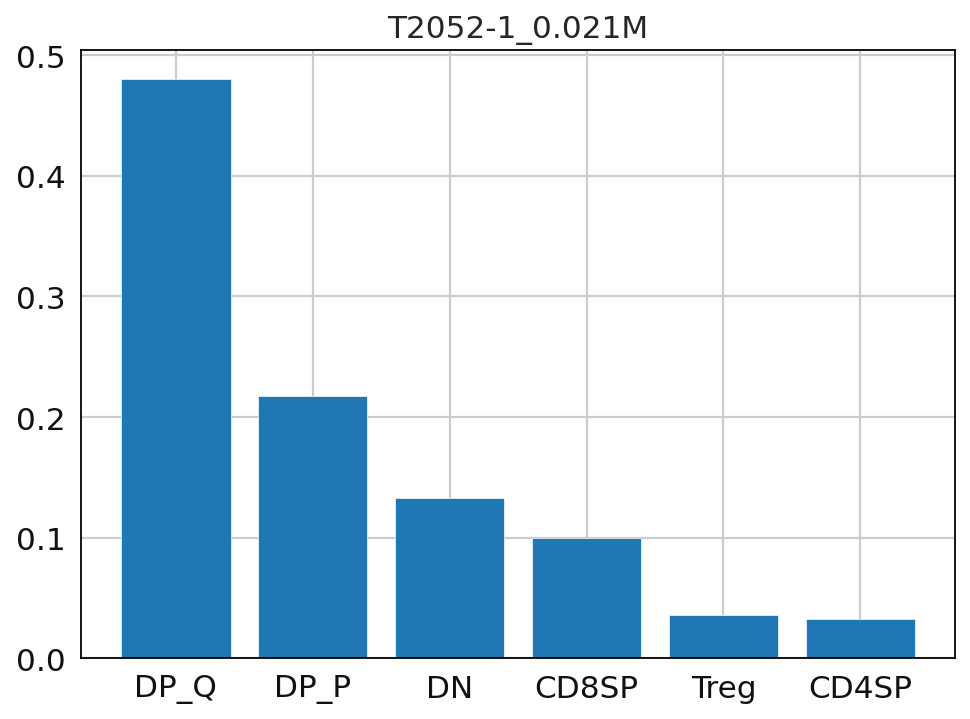

Classifying!
Saving cell type labels to adata!


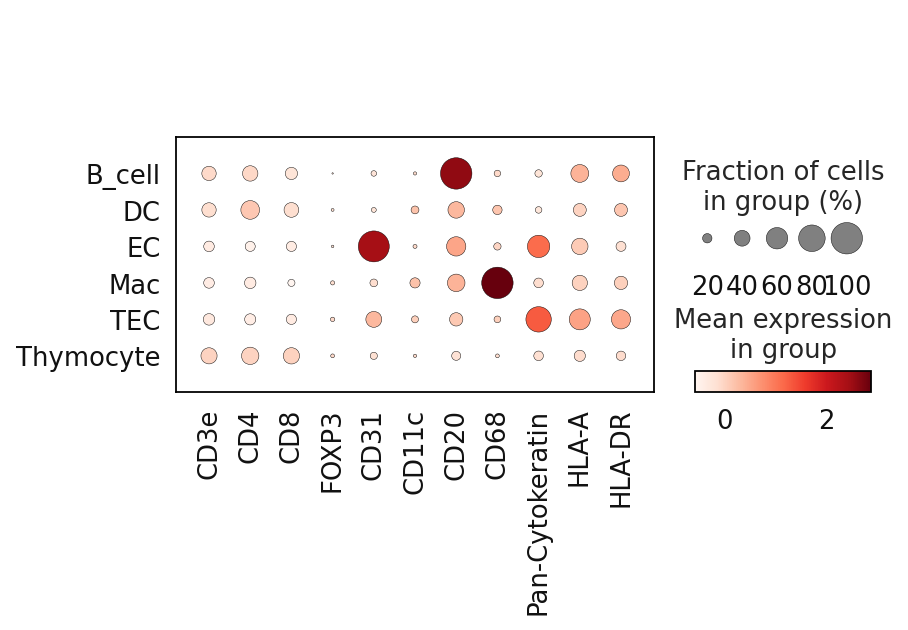

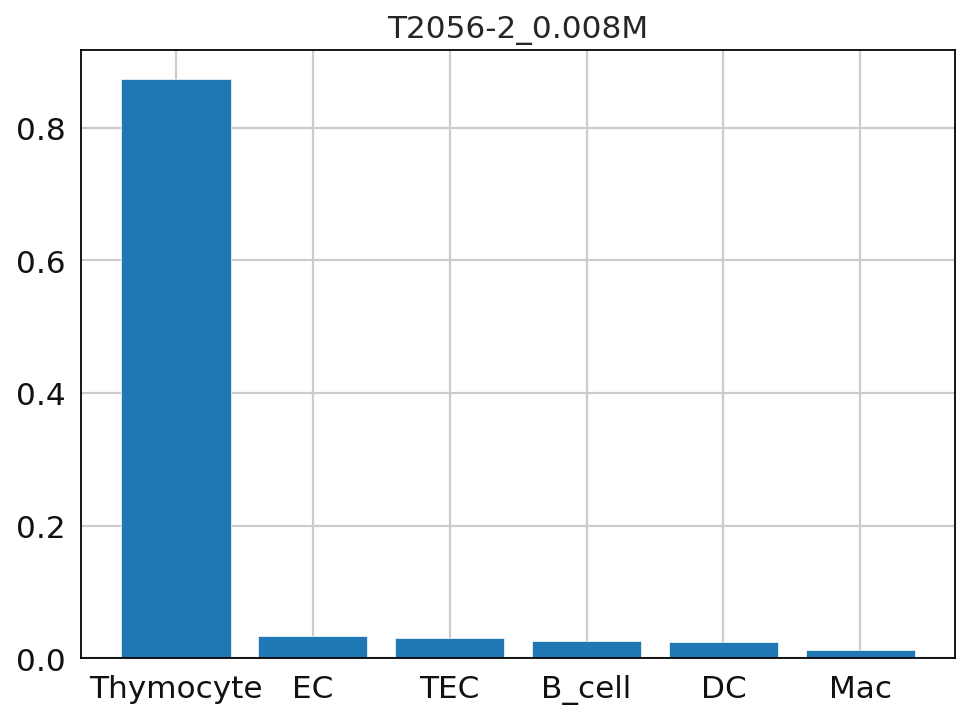

Classifying!
Saving cell type labels to adata!


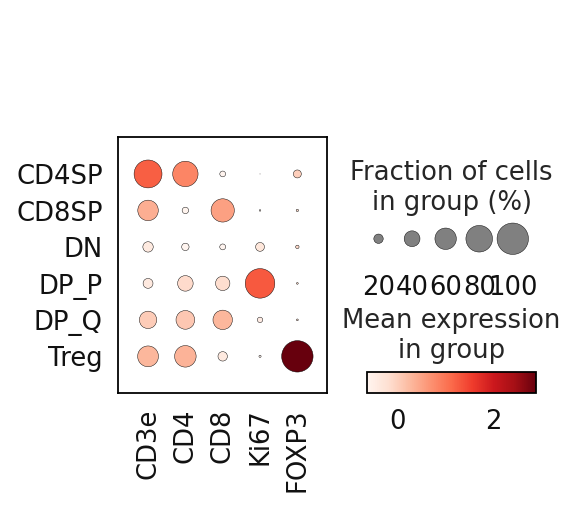

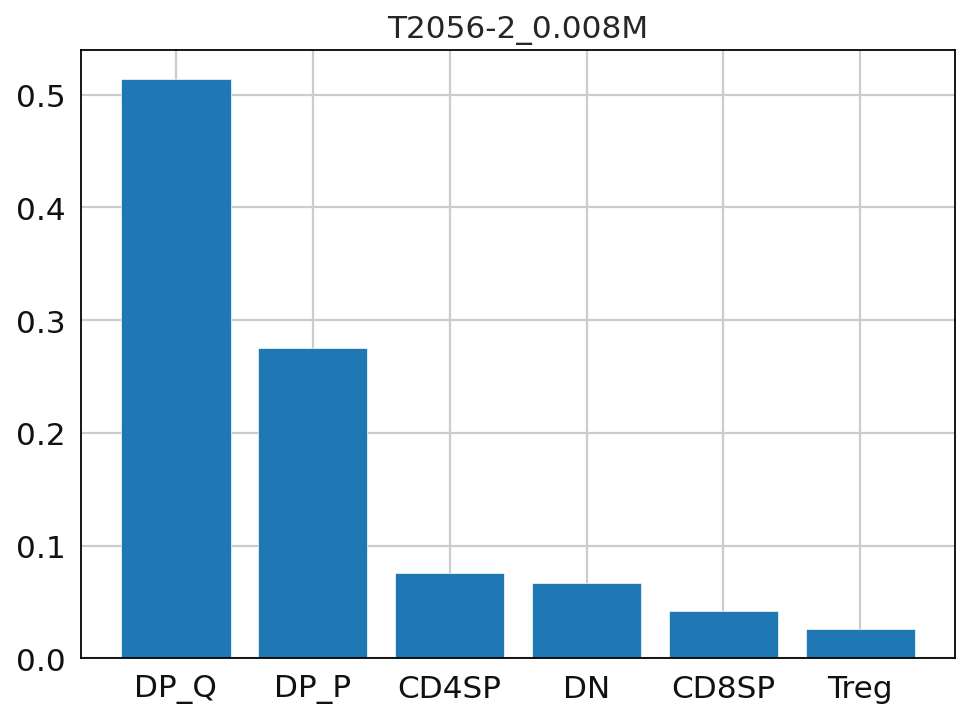

Classifying!
Saving cell type labels to adata!


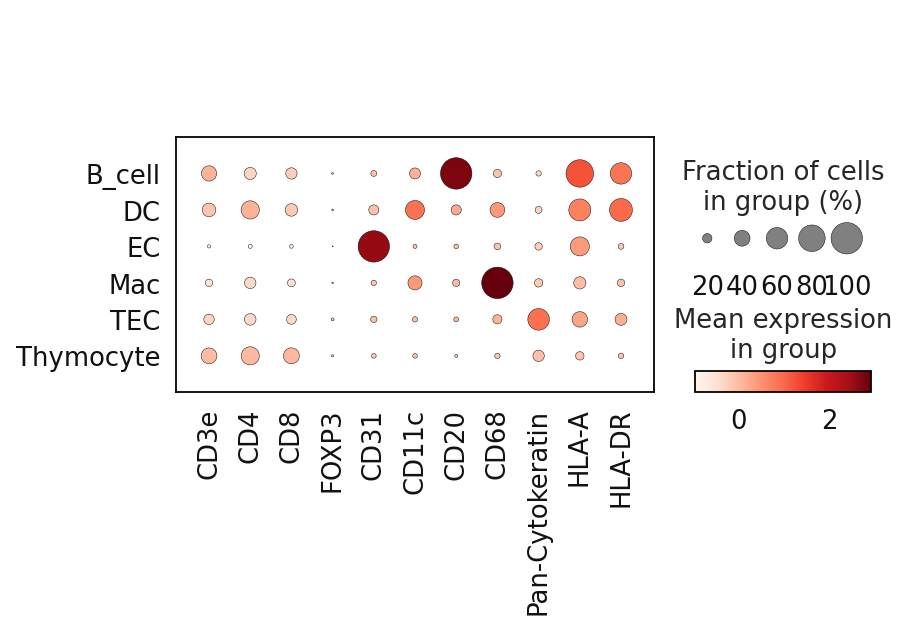

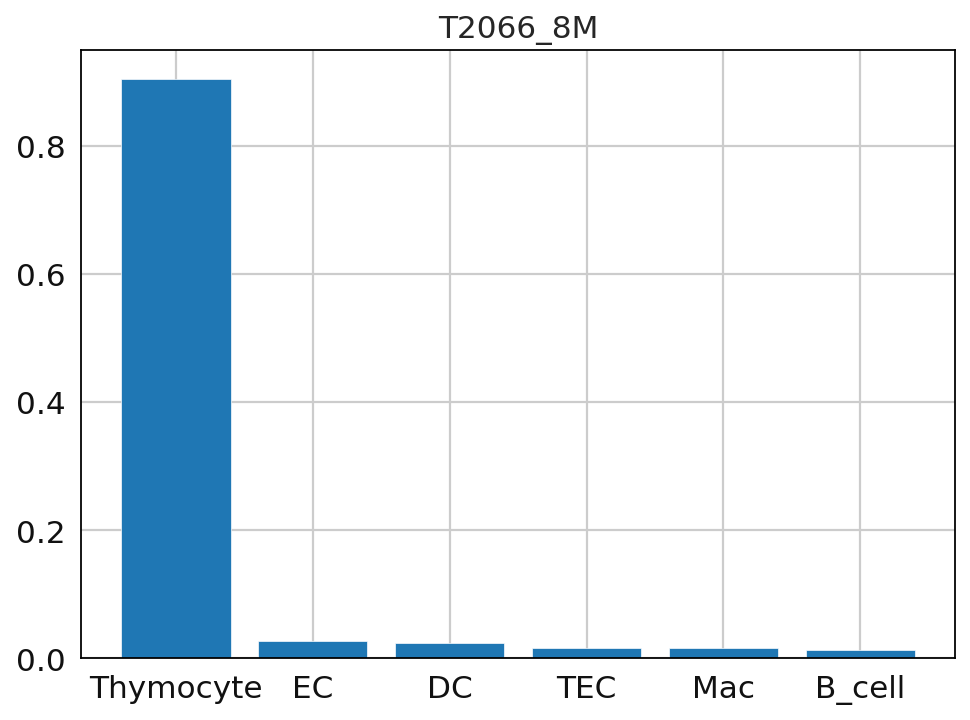

Classifying!
Saving cell type labels to adata!


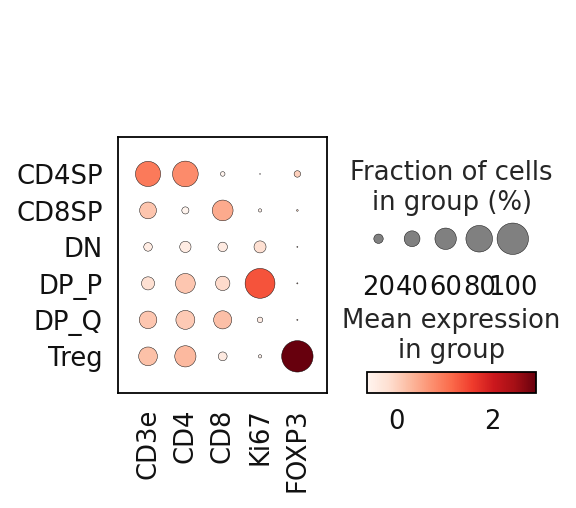

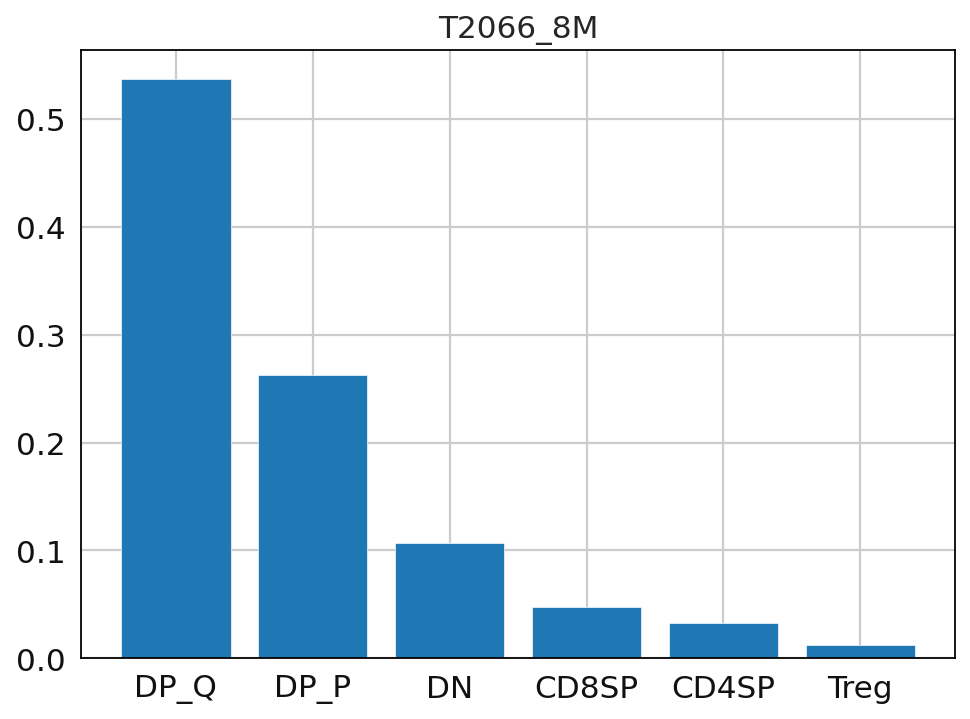

Classifying!
Saving cell type labels to adata!


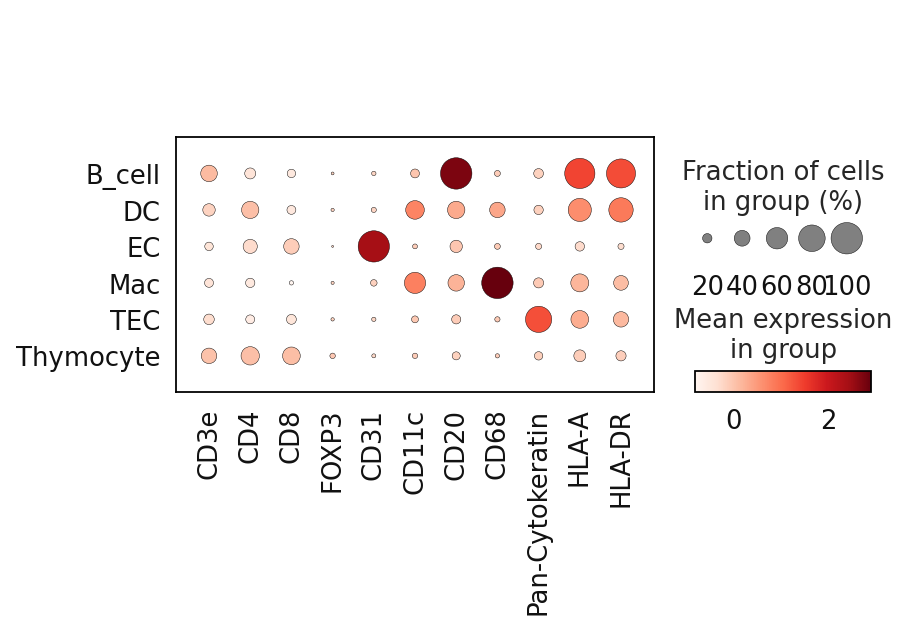

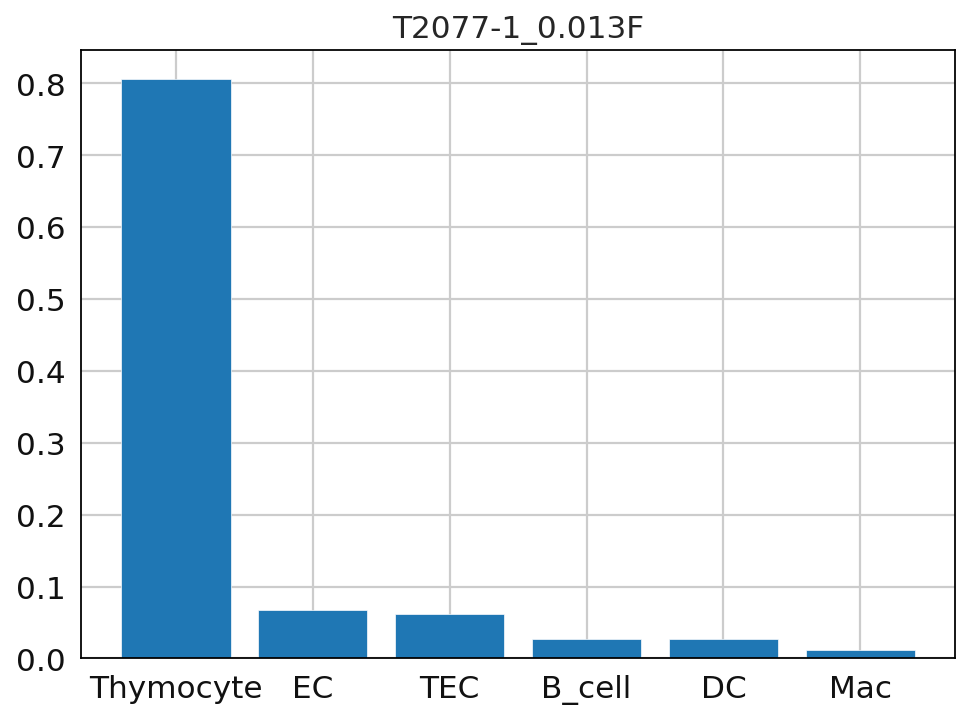

Classifying!
Saving cell type labels to adata!


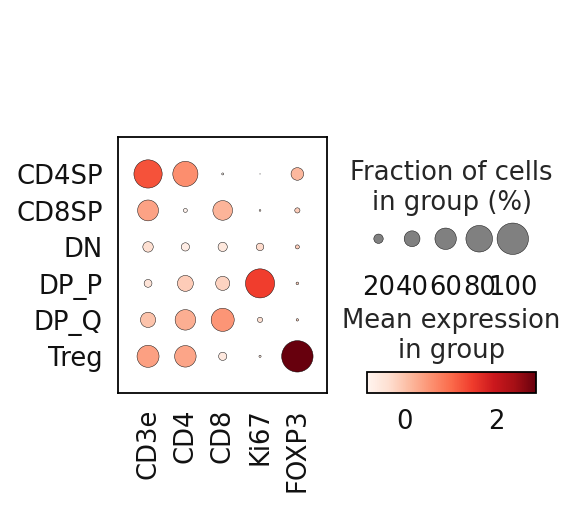

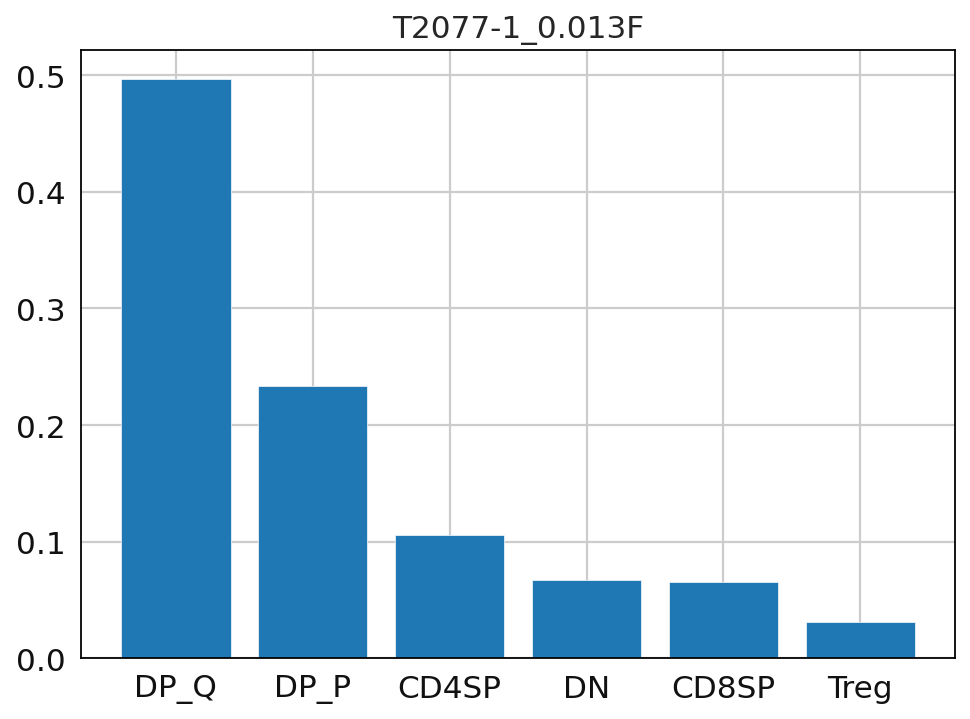

Classifying!
Saving cell type labels to adata!


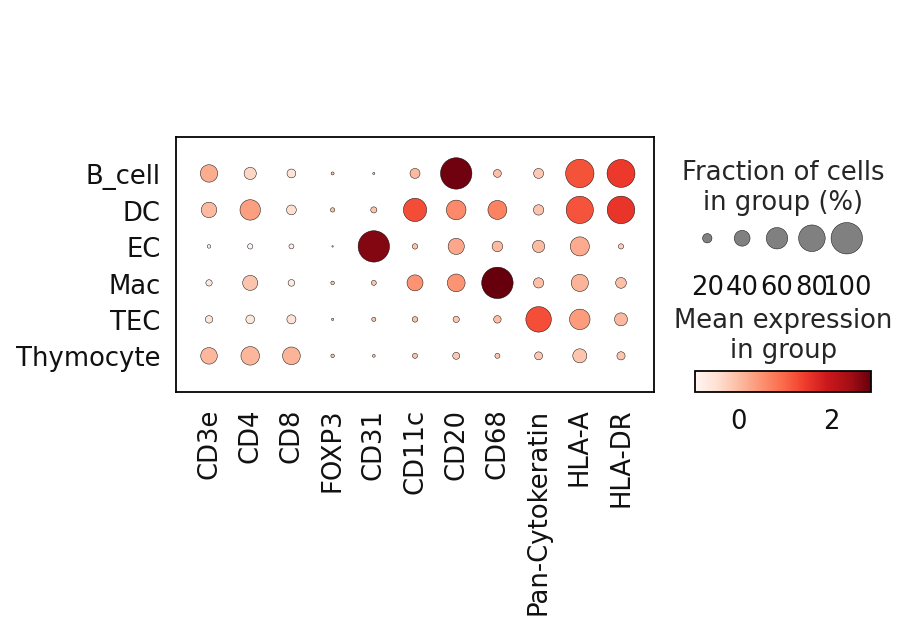

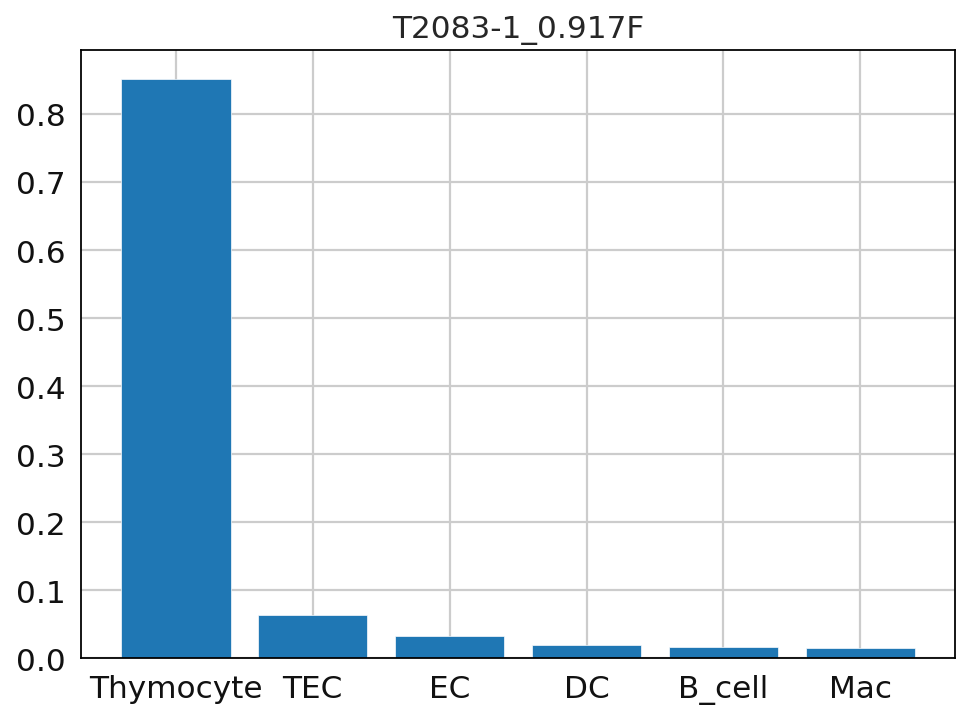

Classifying!
Saving cell type labels to adata!


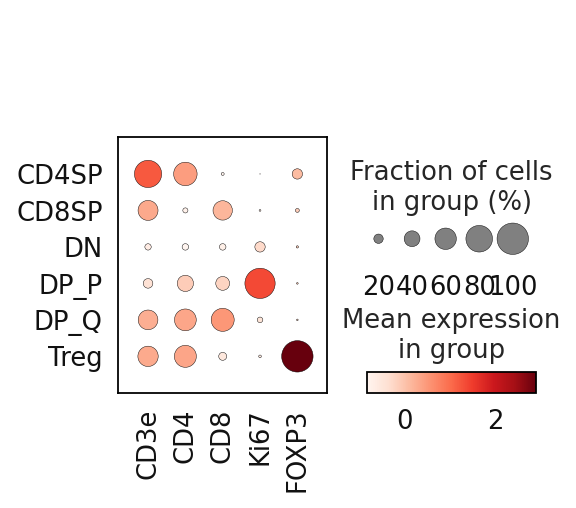

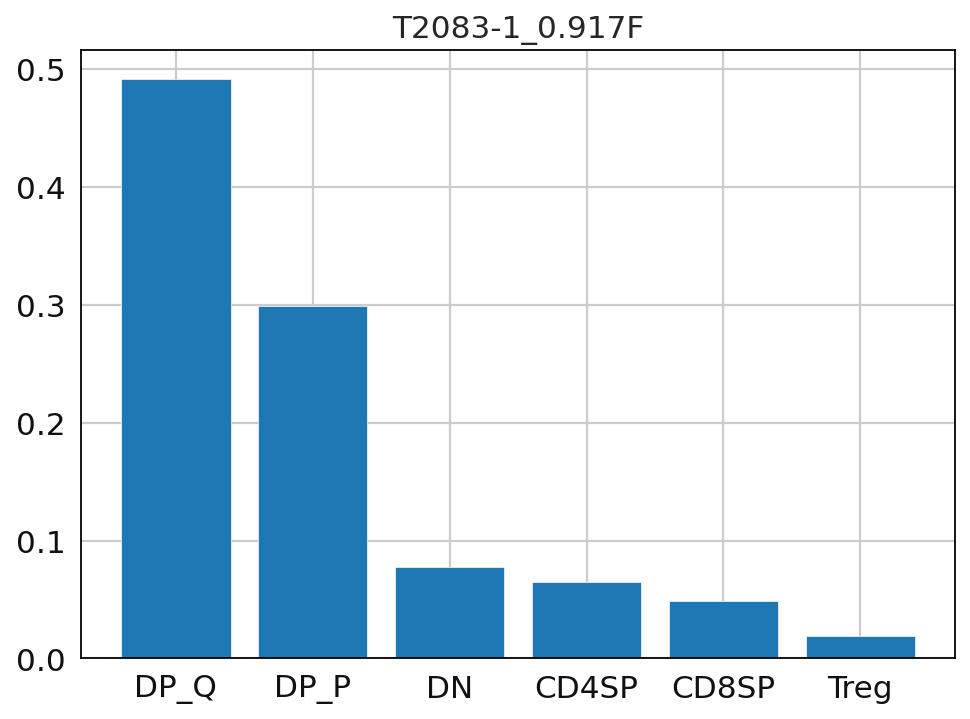

Classifying!
Saving cell type labels to adata!


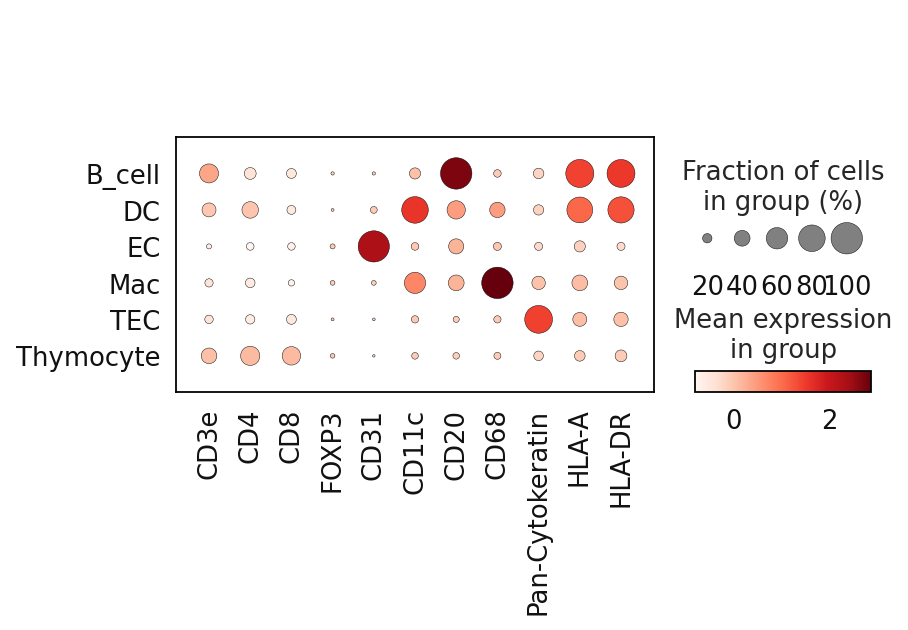

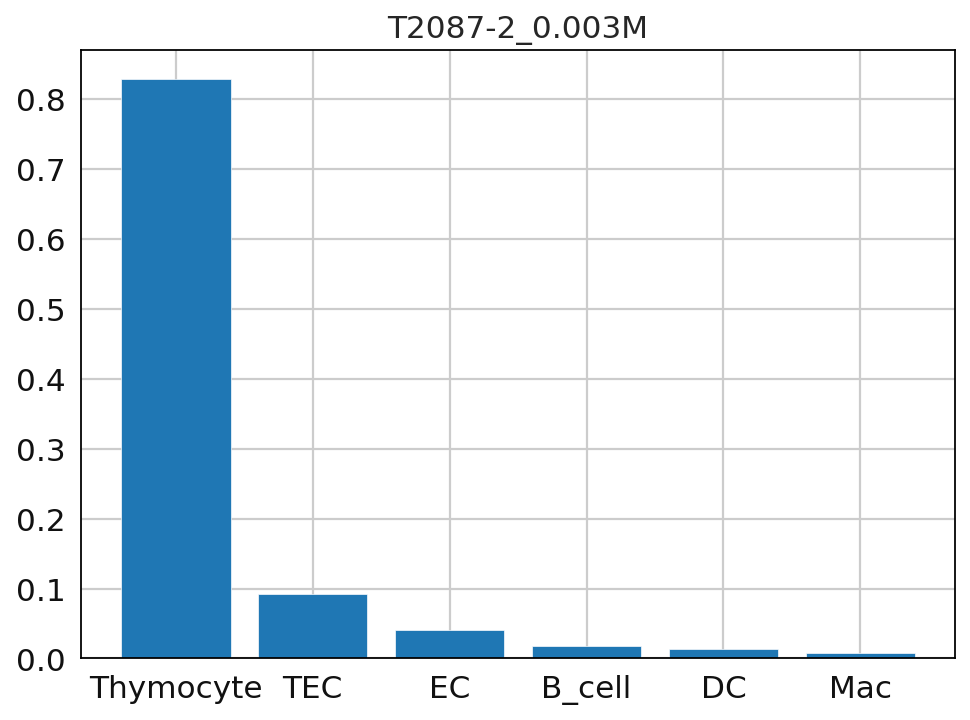

Classifying!
Saving cell type labels to adata!


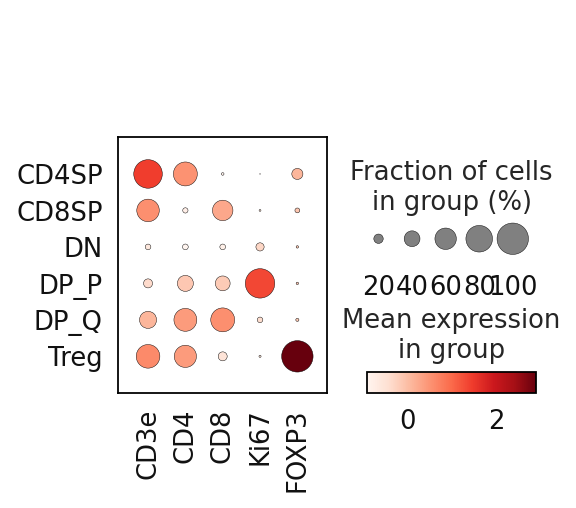

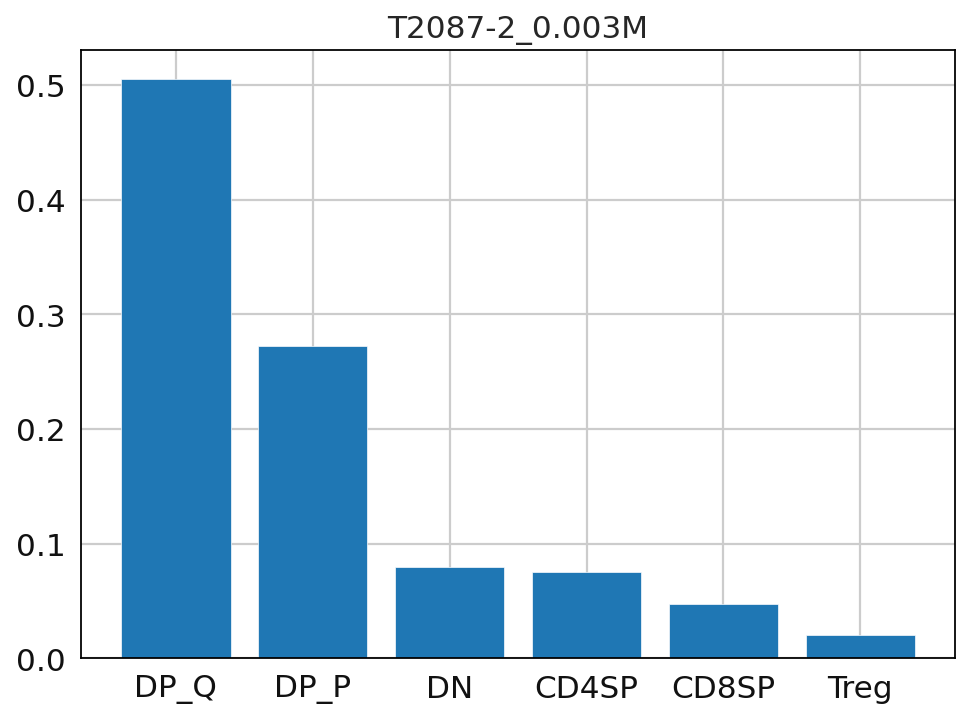

Classifying!
Saving cell type labels to adata!


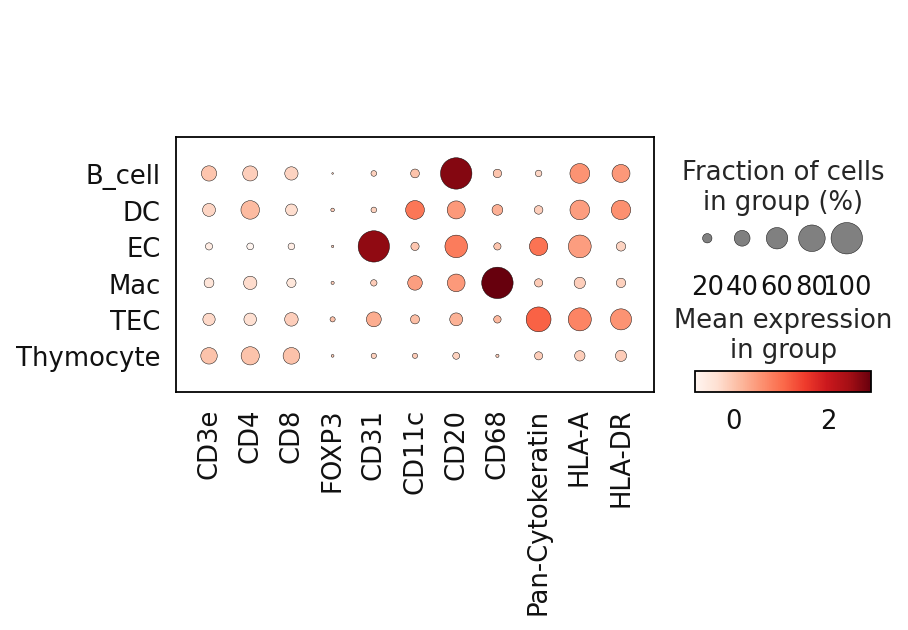

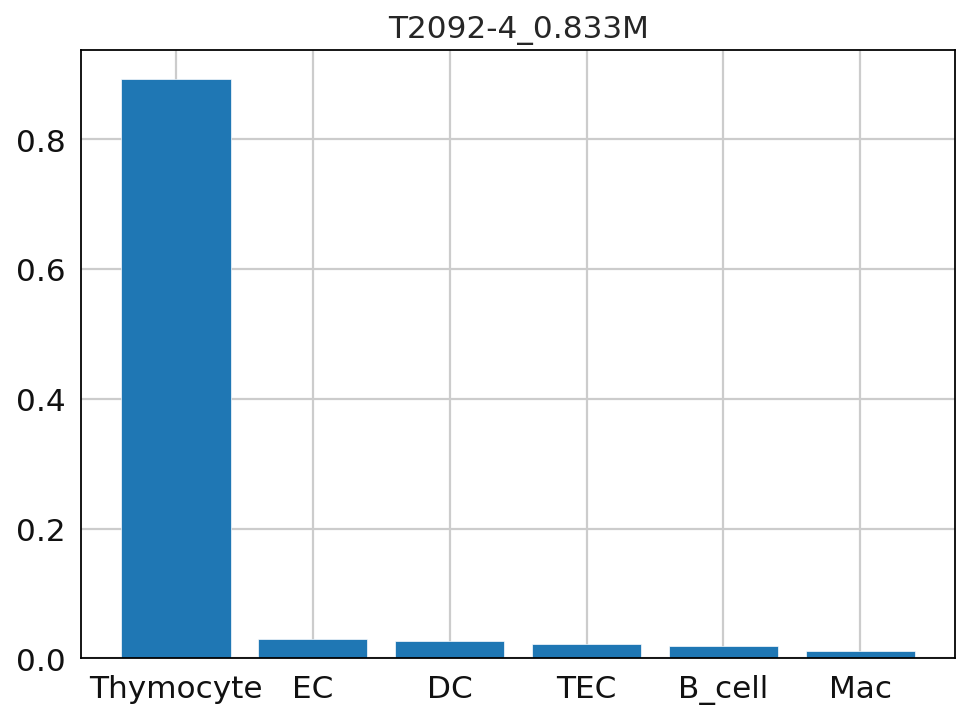

Classifying!
Saving cell type labels to adata!


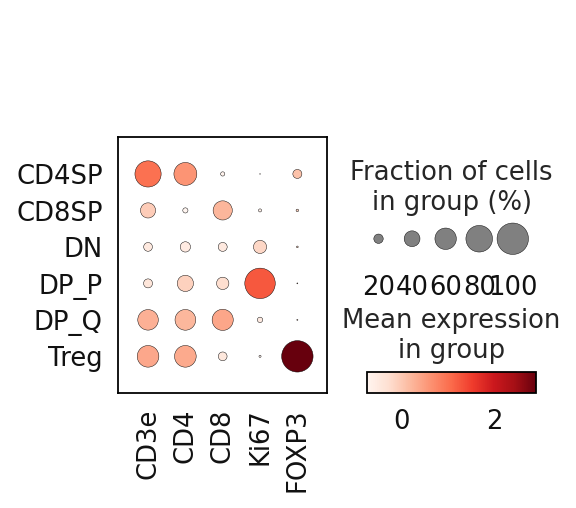

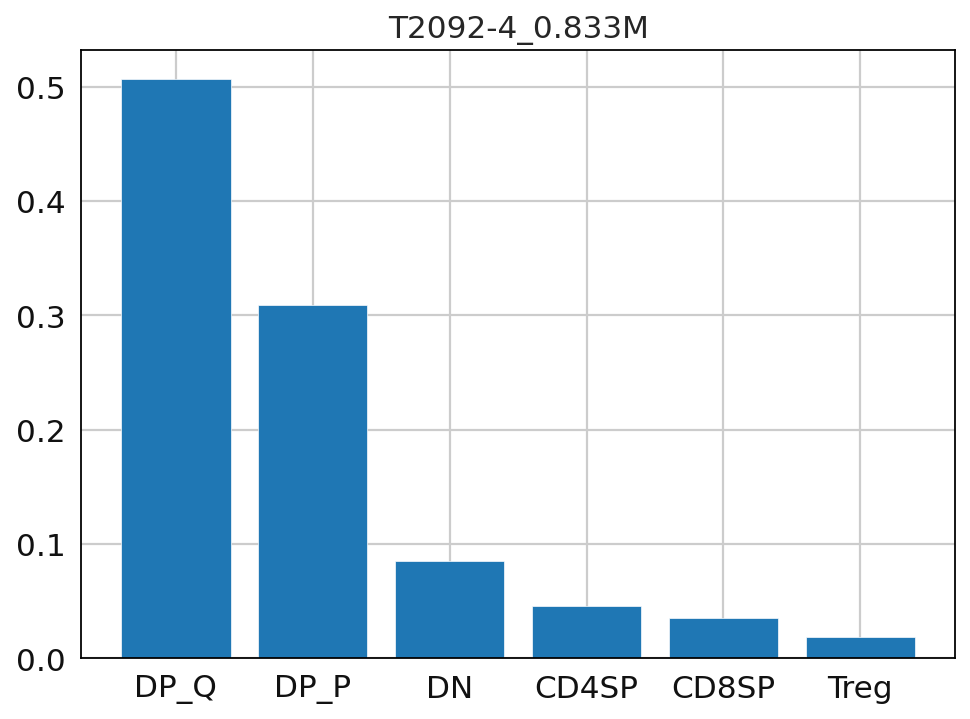

Classifying!
Saving cell type labels to adata!


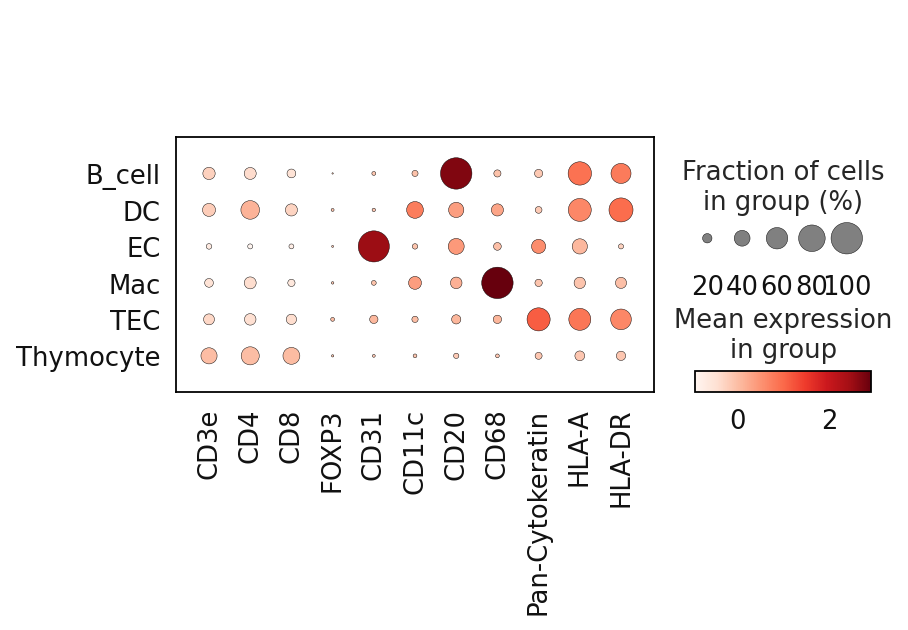

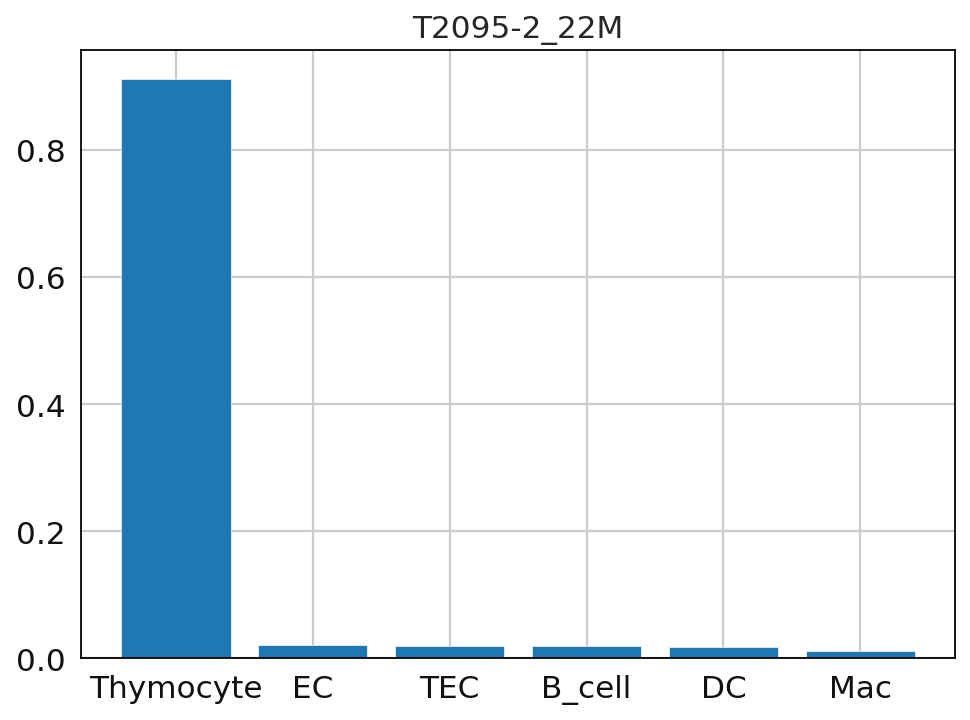

Classifying!
Saving cell type labels to adata!


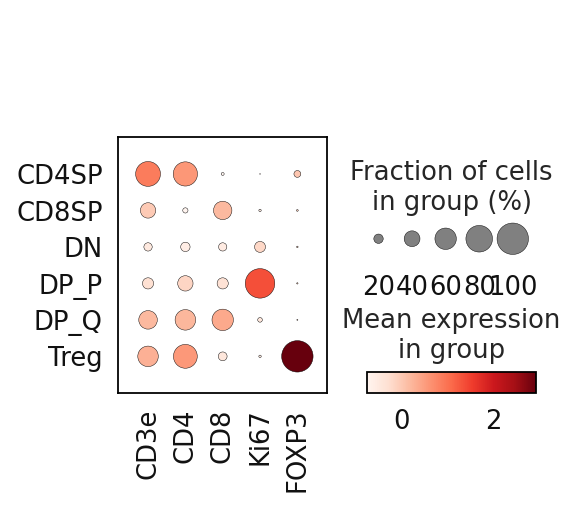

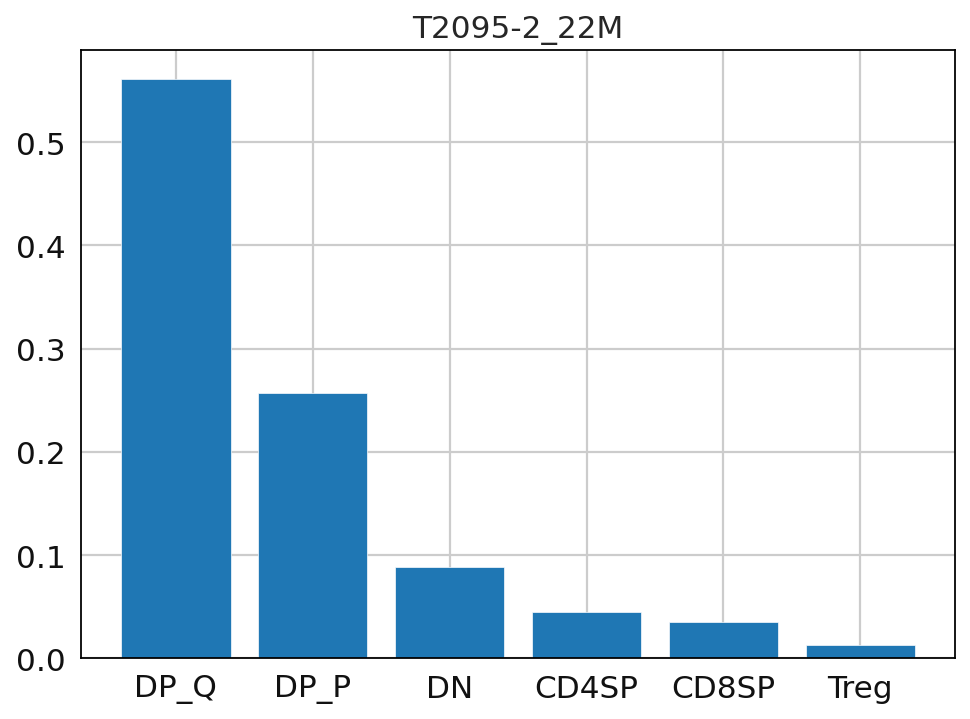

Classifying!
Saving cell type labels to adata!


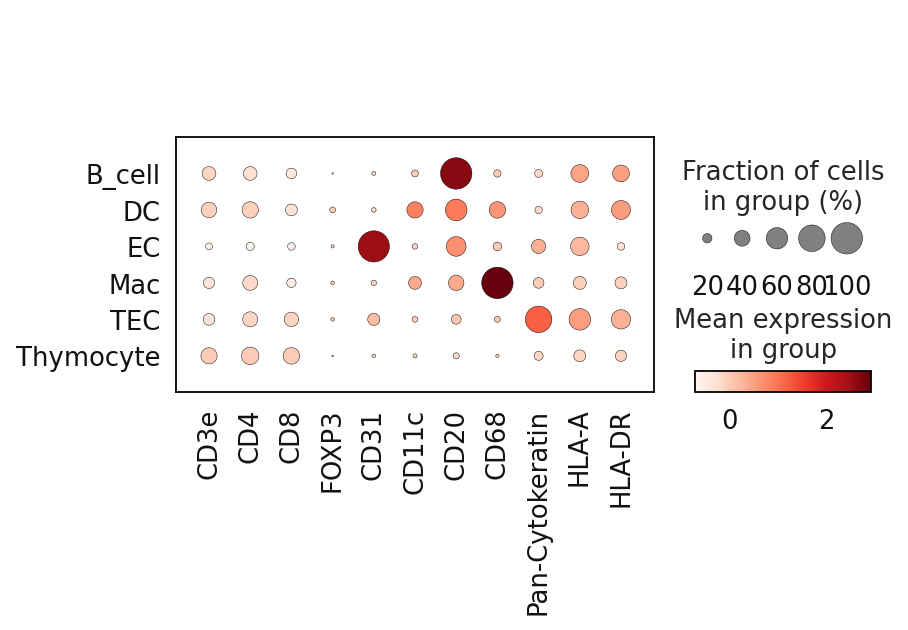

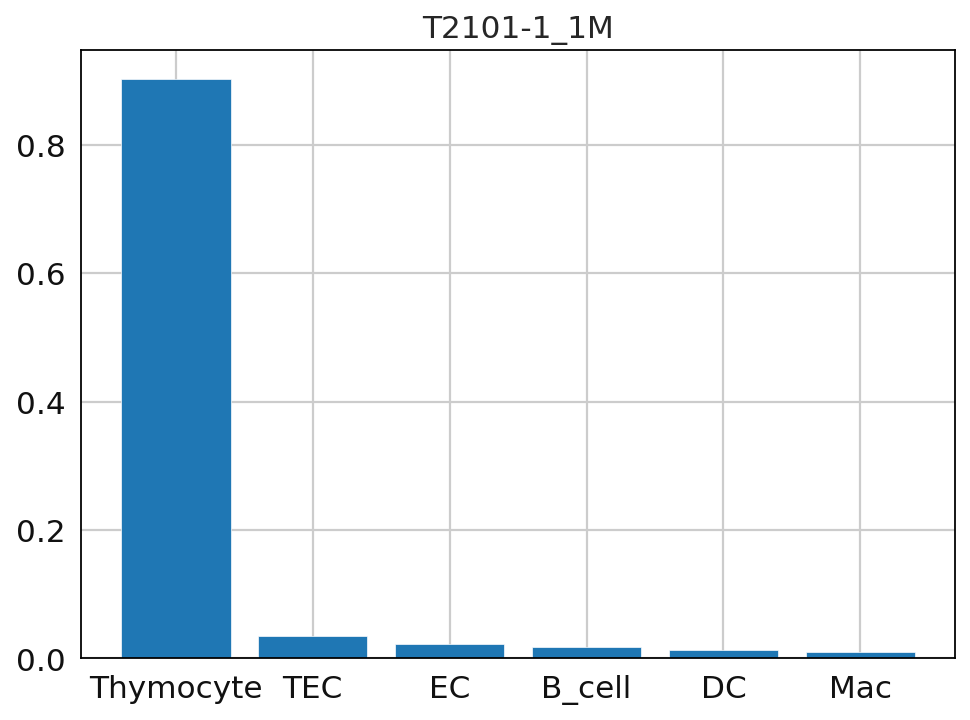

Classifying!
Saving cell type labels to adata!


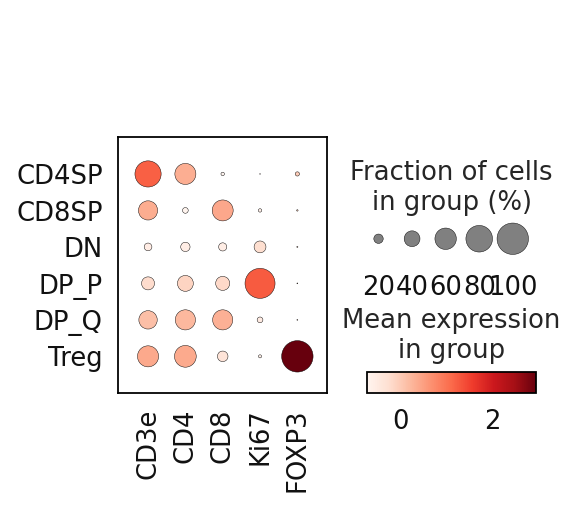

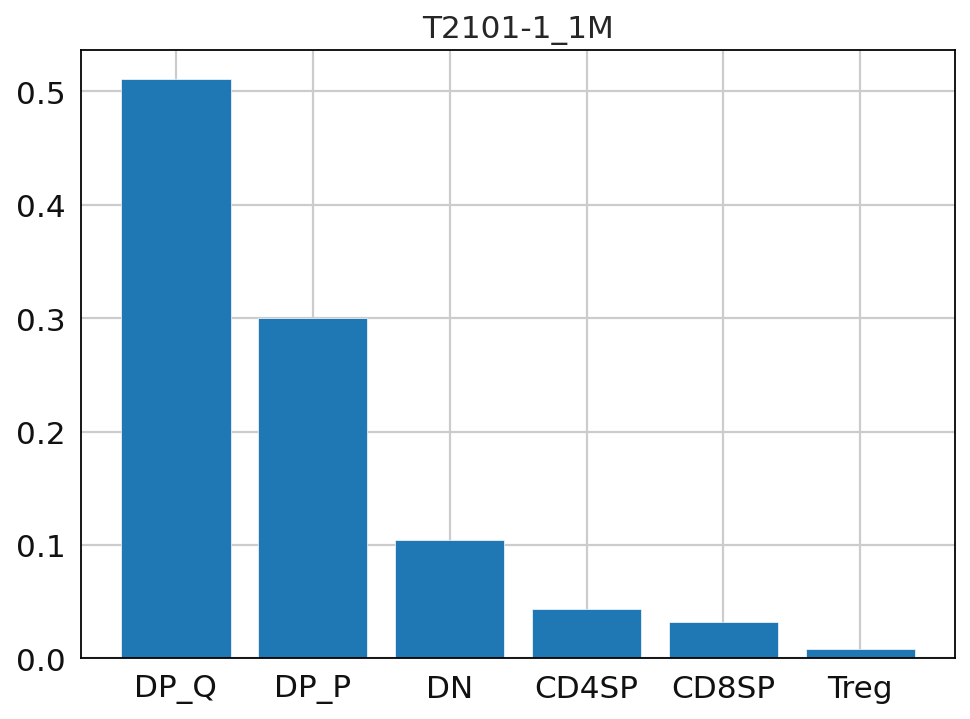

Classifying!
Saving cell type labels to adata!


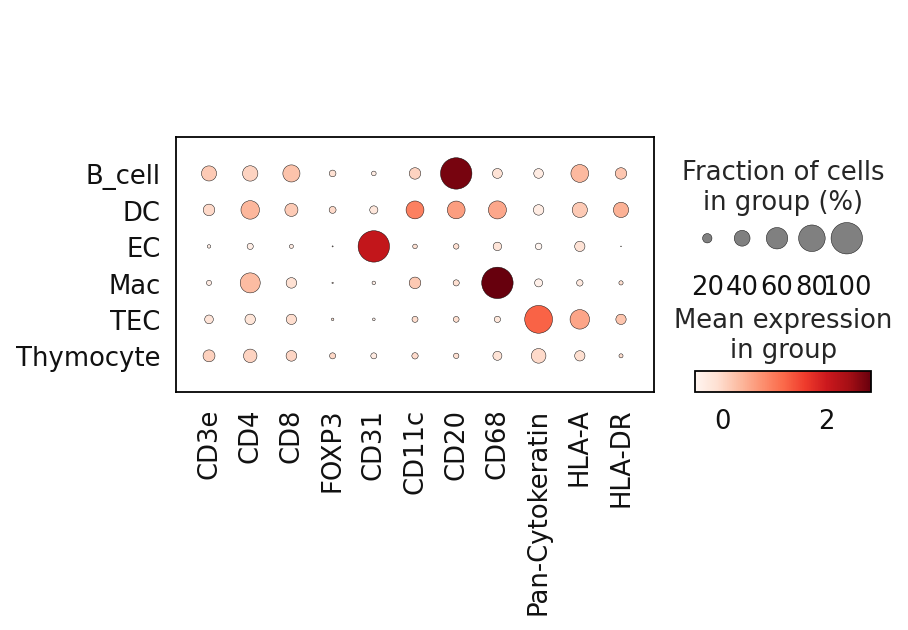

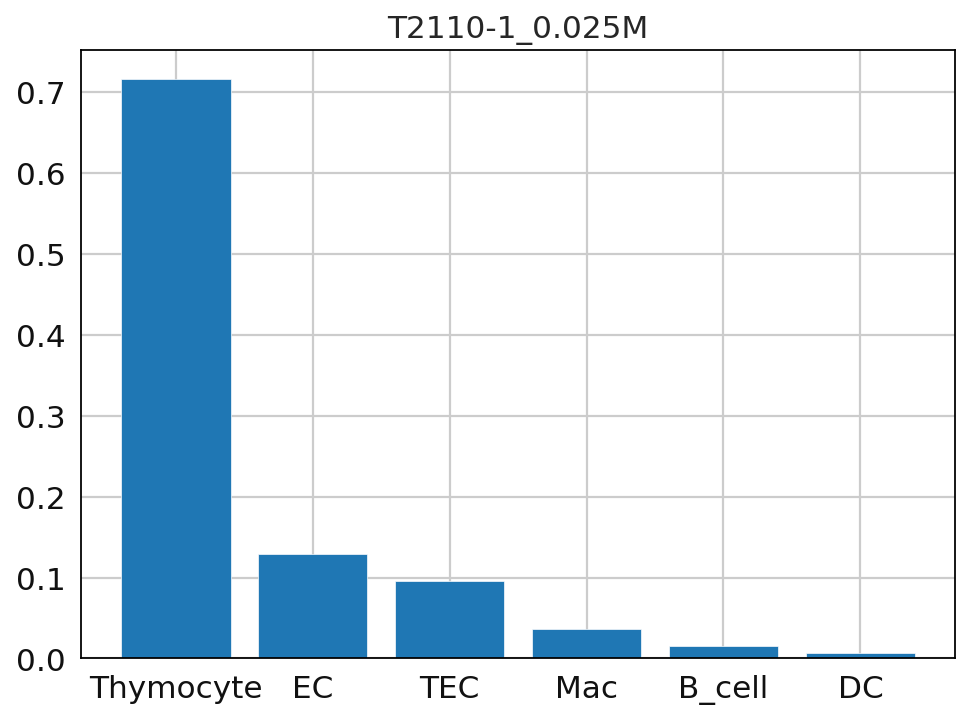

Classifying!
Saving cell type labels to adata!


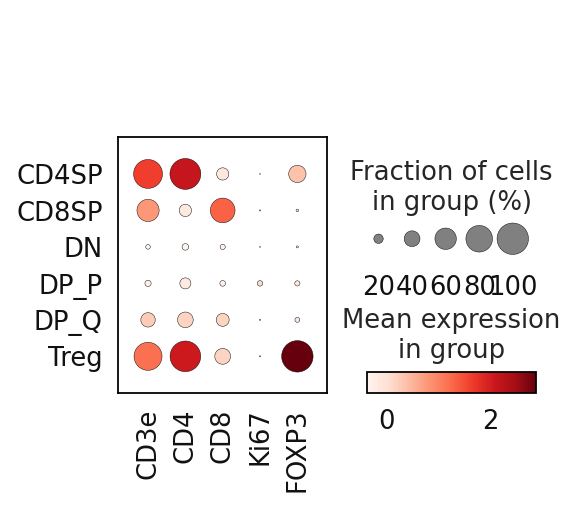

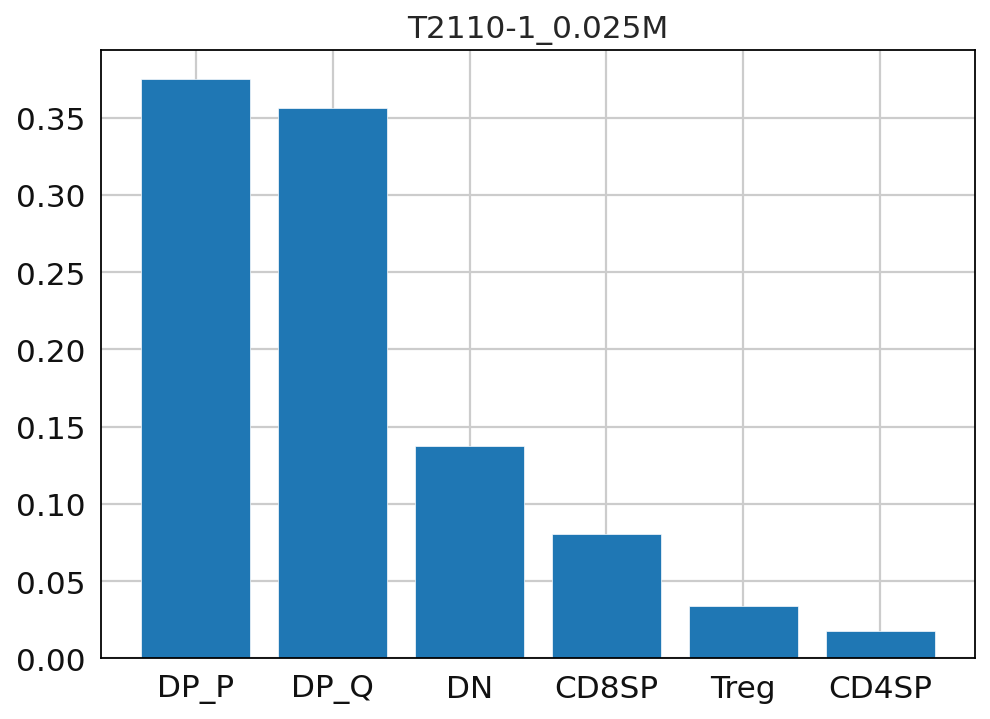

In [17]:
ad_dir = "/John/human_mxif/data/"
other_ads = [os.path.join(ad_dir, ad_file) for ad_file in os.listdir(ad_dir) if re.search("h5ad", ad_file)] 
pred_ads= [None] * len(other_ads)
thym_ads = [None] * len(other_ads)
for i, other_ad in enumerate(other_ads):
    img_ad = sc.read(other_ad) 
    img_ad.obs["core_tag"] = re.sub(r"_block[1-6]_thresh_full_auto_thresh_binary_filt_masks_no_touch_nonfat_cell_mask.h5ad", "", re.sub("/John/human_mxif/data/", "", other_ad))
    img_ad.obs["subject_id"] = img_ad.obs["core_tag"].str.replace("_.*", "", regex= True)
    img_ad.obs["age"] = img_ad.obs["core_tag"].str.replace(".*_", "", regex= True)
    assert np.isnan(img_ad.X).sum() == 0 
    sp.tl.ml_predict(
        adata_val = img_ad,
        svc = ct_svc,
        save_name = "ct_svm_pred"
    )
    # sc.pl.umap(img_ad, color = 'ct_svm_pred')
    sc.pl.dotplot(img_ad, groupby = "ct_svm_pred", var_names= ["CD3e", "CD4", "CD8", "FOXP3", "CD31", "CD11c", "CD20", "CD68", "Pan-Cytokeratin", "HLA-A", "HLA-DR"])
    plot_ct_freq(img_ad, "ct_svm_pred", re.sub(r"_block.*", "", re.sub(ad_dir, "", other_ad)))

    thym_ad = img_ad[img_ad.obs["ct_svm_pred"] == "Thymocyte", :].copy()

    sp.tl.ml_predict(
        adata_val = thym_ad, 
        svc = thym_ct_svc_all_markers, # The DN split looked bad.
        save_name = "thym_ct_svm_pred"
    )
    sc.pl.dotplot(thym_ad, groupby = "thym_ct_svm_pred", var_names= ["CD3e", "CD4", "CD8", "Ki67", "FOXP3"])
    plot_ct_freq(thym_ad, "thym_ct_svm_pred", re.sub(r"_block.*", "", re.sub(ad_dir, "", other_ad)))

    pred_ads[i] = img_ad
    thym_ads[i] = thym_ad

## Classify types of thymocytes 

In [18]:
all_pred_ad = ad.concat(pred_ads)
all_nonT_ad = all_pred_ad[all_pred_ad.obs["ct_svm_pred"] != "Thymocyte", :].copy()

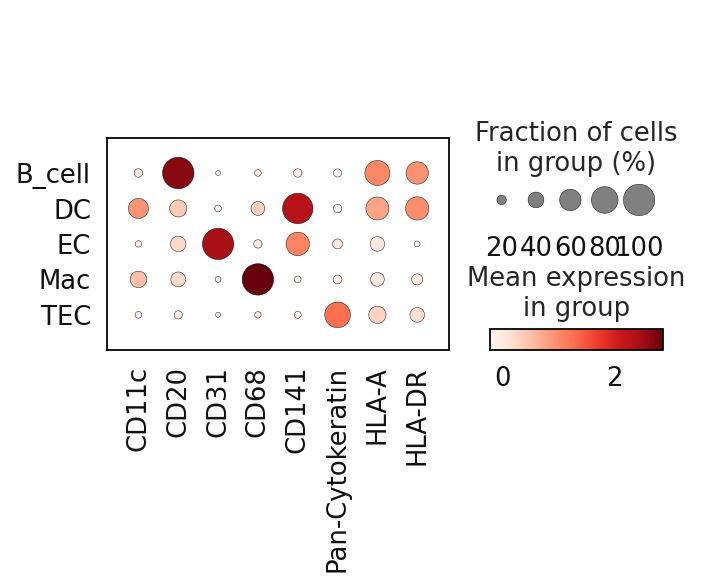

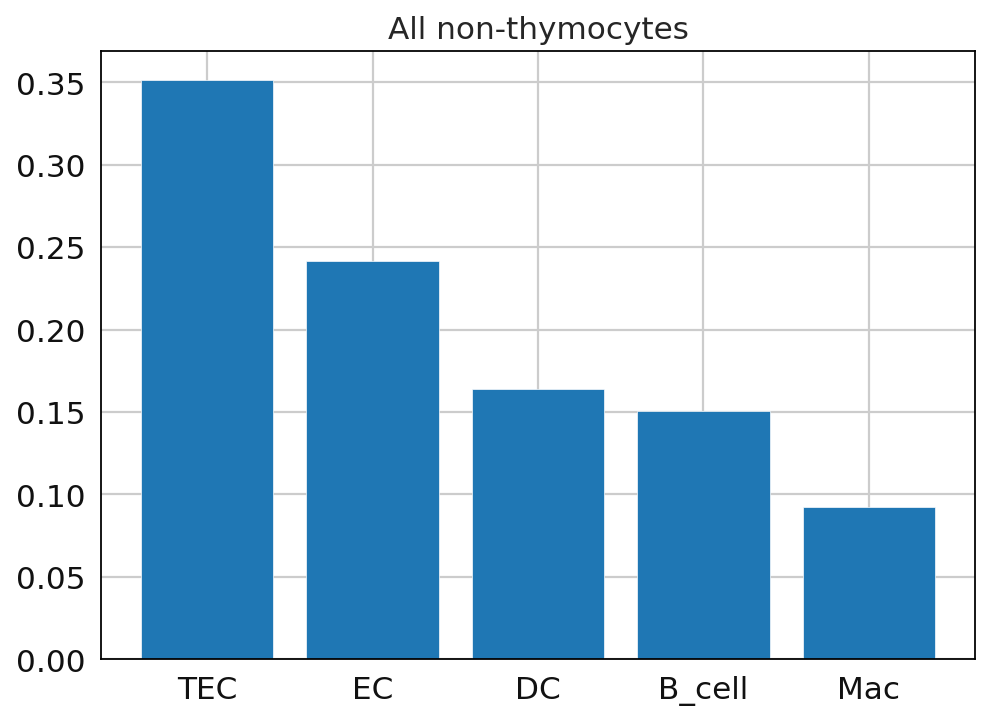

In [19]:
sc.pl.dotplot(all_nonT_ad, groupby = "ct_svm_pred", var_names= ["CD11c", "CD20", "CD31", "CD68", "CD141", "Pan-Cytokeratin", "HLA-A", "HLA-DR"])
plot_ct_freq(all_nonT_ad, "ct_svm_pred", "All non-thymocytes")

In [20]:
all_thym_ad = ad.concat(thym_ads)
all_thym_ad

AnnData object with n_obs × n_vars = 23217780 × 25
    obs: 'CellID', 'Area', 'X_centroid', 'Y_centroid', 'core_tag', 'subject_id', 'age', 'ct_svm_pred', 'thym_ct_svm_pred'
    obsm: 'X_pca'

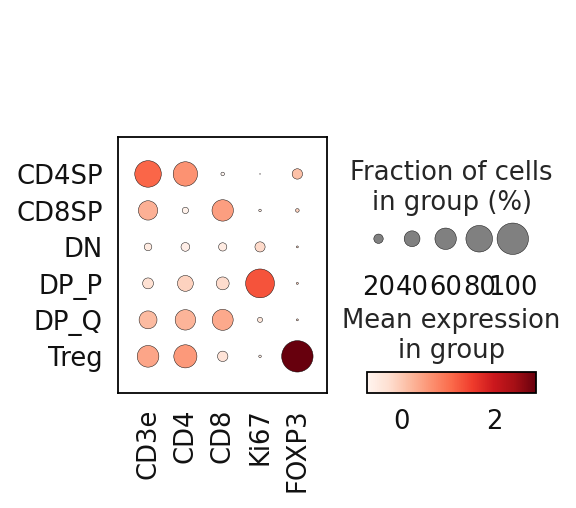

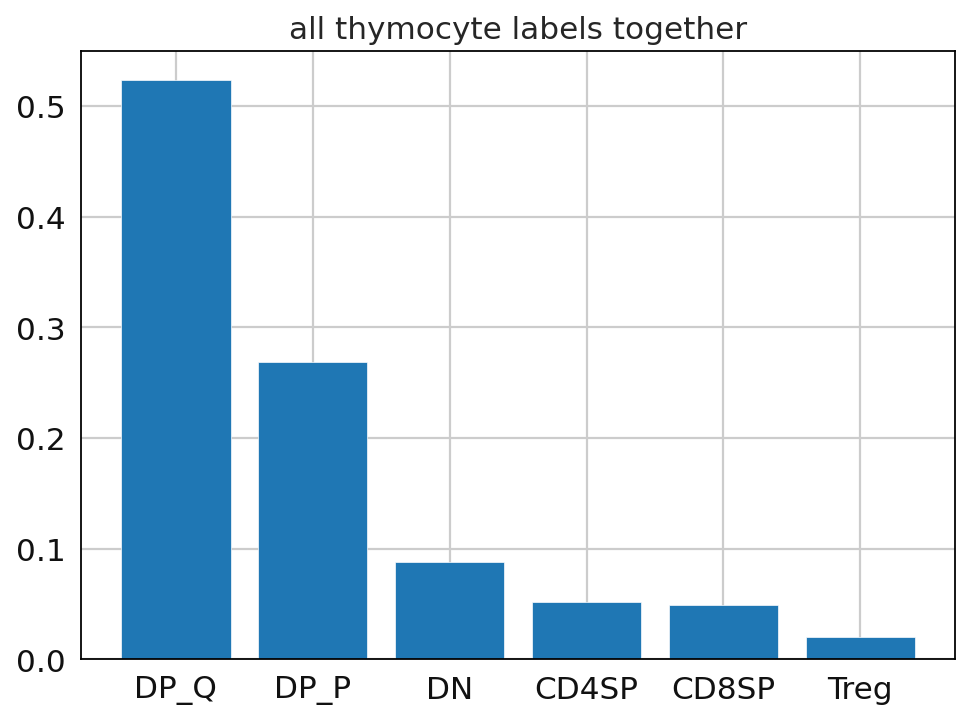

In [21]:
sc.pl.dotplot(all_thym_ad, groupby = "thym_ct_svm_pred", var_names= ["CD3e", "CD4", "CD8", "Ki67", "FOXP3"])
plot_ct_freq(all_thym_ad, "thym_ct_svm_pred", "all thymocyte labels together")

In [22]:
all_thym_ad.write_h5ad("/John/human_mxif/data/all_thym_w_annotations_2026-02-24.h5ad")
all_pred_ad.write_h5ad("/John/human_mxif/data/all_pred_w_annotations_2026-02-24.h5ad")